# PowerLift-AI-X — Machine Learning

## Section 1 — Setup & ML Dataset Validation

This notebook contains the complete machine-learning pipeline for PowerLift-AI-X.

The ML pipeline will be developed incrementally:

1. ML dataset validation
2. Target definition
3. Leakage prevention
4. Temporal feature engineering
5. Feature validation
6. Train / validation / test split
7. Preprocessing
8. Baseline models
9. Advanced models
10. Hyperparameter tuning
11. Model comparison
12. Ensemble / stacking
13. Error analysis
14. Feature importance
15. Final model selection
16. Final evaluation
17. Model persistence

The master dataset is never modified.

**Input dataset:**

`data/final/ml/powerlift_ai_x_ml_dataset.xlsx`

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# FIND PROJECT ROOT
# ============================================================

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR

while PROJECT_ROOT != PROJECT_ROOT.parent:

    if (
        PROJECT_ROOT / "data" / "final"
    ).exists():

        break

    PROJECT_ROOT = PROJECT_ROOT.parent


# ============================================================
# DATASET PATH
# ============================================================

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "final"
    / "ml"
    / "powerlift_ai_x_ml_dataset.xlsx"
)


# ============================================================
# CHECK PATH
# ============================================================

print("Current working directory:")
print(CURRENT_DIR)

print()
print("Project root:")
print(PROJECT_ROOT)

print()
print("Dataset path:")
print(DATA_PATH)


if not DATA_PATH.exists():

    raise FileNotFoundError(
        "\nML dataset not found.\n\n"
        f"Expected:\n{DATA_PATH}\n\n"
        "Make sure the file exists at:\n"
        "data/final/ml/"
    )


# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_excel(DATA_PATH)


print()
print("=" * 60)
print("POWERLIFT-AI-X ML DATASET")
print("=" * 60)

print(f"Records: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

print("=" * 60)

display(df.head())

Current working directory:
c:\Users\Dhruv\Desktop\PowerLift-AI-X\notebooks

Project root:
c:\Users\Dhruv\Desktop\PowerLift-AI-X

Dataset path:
c:\Users\Dhruv\Desktop\PowerLift-AI-X\data\final\ml\powerlift_ai_x_ml_dataset.xlsx

POWERLIFT-AI-X ML DATASET
Records: 9,306
Columns: 26


,athlete_id,bench_1,bench_2,bench_3,best_bench,best_deadlift,best_squat,bodyweight,competition,date_of_birth,...,place,squat_1,squat_2,squat_3,team,total,weight_class,year,resolved_athlete_id,identity_confidence
0,ATH-3329e53259abce06,110.0,120.0,120.0,120.0,232.5,200.0,58.80,National Classic Powerlifting Championship 2019,13-08-1991,...,1,170.0,190.0,200.0,PUD,552.5,59,2019,ATH-3329e53259abce06,UNIQUE_CANDIDATE
1,ATH-3f4818d49460c4d4,125.0,132.5,140.0,140.0,217.5,190.0,58.95,National Classic Powerlifting Championship 2019,01-10-1993,...,2,180.0,190.0,202.5,MAH,547.5,59,2019,ATH-3f4818d49460c4d4,UNIQUE_CANDIDATE
2,ATH-4c9fc72c7abc16d2,105.0,115.0,122.5,122.5,200.0,185.0,56.60,National Classic Powerlifting Championship 2019,10-11-1994,...,3,170.0,177.5,185.0,T.N,507.5,59,2019,ATH-4c9fc72c7abc16d2,UNIQUE_CANDIDATE
3,ATH-c3ef71ff4b36607e,80.0,85.0,85.0,80.0,217.5,162.5,58.65,National Classic Powerlifting Championship 2019,31-12-1991,...,4,152.5,162.5,167.5,ASA,460.0,59,2019,ATH-c3ef71ff4b36607e,UNIQUE_CANDIDATE
4,ATH-33edebc06d4b41ea,85.0,90.0,92.5,92.5,190.0,175.0,58.30,National Classic Powerlifting Championship 2019,11-08-1996,...,5,165.0,175.0,180.0,ODI,457.5,59,2019,ATH-33edebc06d4b41ea,UNIQUE_CANDIDATE


In [3]:
# ============================================================
# EXPECTED SCHEMA
# ============================================================

REQUIRED_COLUMNS = [
    "athlete_id",
    "resolved_athlete_id",
    "competition",
    "year",
    "division",
    "weight_class",
    "equipment",
    "bodyweight",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]


if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )


print("REQUIRED SCHEMA: PASS")
print()
print("Required columns:")

for column in REQUIRED_COLUMNS:
    print(f"  ✓ {column}")

REQUIRED SCHEMA: PASS

Required columns:
  ✓ athlete_id
  ✓ resolved_athlete_id
  ✓ competition
  ✓ year
  ✓ division
  ✓ weight_class
  ✓ equipment
  ✓ bodyweight
  ✓ best_squat
  ✓ best_bench
  ✓ best_deadlift
  ✓ total


In [4]:
# ============================================================
# CORE ML FIELDS
# ============================================================

CORE_FIELDS = [
    "resolved_athlete_id",
    "bodyweight",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]


missing_core = df[CORE_FIELDS].isna().sum()

display(
    missing_core
    .rename("missing")
    .to_frame()
)


assert missing_core.sum() == 0, (
    "Core ML fields contain missing values."
)

print("CORE ML FIELDS: PASS")

,missing
resolved_athlete_id,0
bodyweight,0
best_squat,0
best_bench,0
best_deadlift,0
total,0


CORE ML FIELDS: PASS


In [5]:
# ============================================================
# NUMERIC VALIDATION
# ============================================================

NUMERIC_FIELDS = [
    "bodyweight",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]


for column in NUMERIC_FIELDS:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )


# No NaN after numeric conversion
assert (
    df[NUMERIC_FIELDS]
    .notna()
    .all()
    .all()
)


# No infinite values
assert np.isfinite(
    df[NUMERIC_FIELDS]
    .to_numpy()
).all()


# Bodyweight must be positive
assert (
    df["bodyweight"] > 0
).all()


# Performance values cannot be negative
assert (
    df[
        [
            "best_squat",
            "best_bench",
            "best_deadlift",
            "total",
        ]
    ] >= 0
).all().all()


print("NUMERIC VALIDATION: PASS")

NUMERIC VALIDATION: PASS


In [6]:
# ============================================================
# TOTAL CONSISTENCY
# ============================================================

calculated_total = (
    df["best_squat"]
    + df["best_bench"]
    + df["best_deadlift"]
)


total_difference = (
    calculated_total
    - df["total"]
).abs()


TOTAL_TOLERANCE = 0.01

mismatches = (
    total_difference
    > TOTAL_TOLERANCE
)


print(
    "Total mismatches:",
    int(mismatches.sum())
)

print(
    "Maximum difference:",
    float(total_difference.max())
)


assert not mismatches.any(), (
    "Total consistency check failed."
)

print("TOTAL CONSISTENCY: PASS")

Total mismatches: 0
Maximum difference: 0.0
TOTAL CONSISTENCY: PASS


In [7]:
# ============================================================
# DUPLICATE RESULT CHECK
# ============================================================

RESULT_KEY = [
    "resolved_athlete_id",
    "competition",
    "year",
    "division",
    "weight_class",
]


exact_duplicates = int(
    df.duplicated().sum()
)


duplicate_result_rows = int(
    df.duplicated(
        subset=RESULT_KEY,
        keep=False,
    ).sum()
)


print(
    f"Exact duplicate rows: "
    f"{exact_duplicates}"
)

print(
    f"Rows in duplicate result groups: "
    f"{duplicate_result_rows}"
)


assert exact_duplicates == 0
assert duplicate_result_rows == 0


print("DUPLICATE CHECK: PASS")

Exact duplicate rows: 0
Rows in duplicate result groups: 0
DUPLICATE CHECK: PASS


In [8]:
# ============================================================
# IDENTITY VALIDATION
# ============================================================

assert (
    df["resolved_athlete_id"]
    .notna()
    .all()
)

assert (
    df["resolved_athlete_id"]
    .astype(str)
    .str.strip()
    .ne("")
    .all()
)


unique_athletes = (
    df["resolved_athlete_id"]
    .nunique()
)


print(
    f"Resolved athletes: "
    f"{unique_athletes:,}"
)

print("IDENTITY VALIDATION: PASS")

Resolved athletes: 5,321
IDENTITY VALIDATION: PASS


In [9]:
# ============================================================
# CATEGORY VALIDATION
# ============================================================

CATEGORY_FIELDS = [
    "competition",
    "division",
    "weight_class",
    "equipment",
]


for column in CATEGORY_FIELDS:

    assert (
        df[column]
        .notna()
        .all()
    )

    assert (
        df[column]
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    )


print("CATEGORY VALIDATION: PASS")

CATEGORY VALIDATION: PASS


In [10]:
# ============================================================
# YEAR VALIDATION
# ============================================================

df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce",
)


assert df["year"].notna().all()

assert (
    df["year"]
    .between(1900, 2100)
    .all()
)


print(
    f"Year range: "
    f"{int(df['year'].min())}–"
    f"{int(df['year'].max())}"
)

print("YEAR VALIDATION: PASS")

Year range: 2017–2026
YEAR VALIDATION: PASS


In [11]:
# ============================================================
# SECTION 1 FINAL VALIDATION
# ============================================================

print()
print("=" * 60)
print("STEP 1 — ML DATASET VALIDATION")
print("=" * 60)

print(f"Records:              {len(df):,}")
print(f"Columns:              {len(df.columns):,}")
print(f"Resolved athletes:    {df['resolved_athlete_id'].nunique():,}")
print(f"Competitions:         {df['competition'].nunique():,}")
print(
    f"Year range:           "
    f"{int(df['year'].min())}–"
    f"{int(df['year'].max())}"
)

print()
print("Core missing values:  0")
print("Total mismatches:     0")
print("Duplicate results:    0")
print("Identity coverage:    100%")

print("=" * 60)
print("VALIDATION STATUS: PASS")
print("=" * 60)


STEP 1 — ML DATASET VALIDATION
Records:              9,306
Columns:              26
Resolved athletes:    5,321
Competitions:         74
Year range:           2017–2026

Core missing values:  0
Total mismatches:     0
Duplicate results:    0
Identity coverage:    100%
VALIDATION STATUS: PASS


# 2. Target Definition

## Prediction Objective

PowerLift-AI-X will ultimately predict an athlete's **future competition performance**.

For each athlete:

```text
Previous competition(s)
        ↓
Historical performance features
        ↓
Future competition
        ↓
Predicted total

In [12]:


### Code cell — define the target


# ============================================================
# TARGET DEFINITION
# ============================================================

TARGET_COLUMN = "total"

TEMPORAL_GROUP_COLUMN = "resolved_athlete_id"
TIME_COLUMN = "year"

print("=" * 60)
print("STEP 2 — TARGET DEFINITION")
print("=" * 60)

print(f"Prediction target: {TARGET_COLUMN}")
print(f"Athlete grouping:   {TEMPORAL_GROUP_COLUMN}")
print(f"Time boundary:      {TIME_COLUMN}")

STEP 2 — TARGET DEFINITION
Prediction target: total
Athlete grouping:   resolved_athlete_id
Time boundary:      year


In [13]:
# ============================================================
# ATHLETE HISTORY SUMMARY
# ============================================================

athlete_history = (
    df.groupby(TEMPORAL_GROUP_COLUMN)
    .agg(
        competitions=("competition", "nunique"),
        records=("total", "size"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

display(
    athlete_history
    .sort_values(
        ["competitions", "first_year"],
        ascending=[False, True],
    )
    .head(20)
)

print(
    f"Total resolved athletes: "
    f"{len(athlete_history):,}"
)

print(
    f"Athletes with multiple competition records: "
    f"{int((athlete_history['records'] > 1).sum()):,}"
)

print(
    f"Athletes with multiple distinct competitions: "
    f"{int((athlete_history['competitions'] > 1).sum()):,}"
)

,resolved_athlete_id,competitions,records,first_year,last_year
1351,ATH-40b13f7b44aaa235,19,19,2022,2026
279,ATH-0c9fe4ff11247322,16,16,2018,2026
2350,ATH-72eca94603e17a80,16,16,2018,2025
1047,ATH-3111e279395d8df7,13,13,2018,2024
2302,ATH-703a057527049e5d,13,13,2018,2026
3963,ATH-c5015e6fbd52ffbf,13,13,2018,2024
3201,ATH-9cfb8f0f5899d6aa,13,13,2022,2026
38,ATH-020a96ba860868e6,12,12,2018,2025
2307,ATH-7063cf1242a07ff4,12,12,2019,2025
3788,ATH-bbb399de81d16243,12,12,2022,2026


Total resolved athletes: 5,321
Athletes with multiple competition records: 1,829
Athletes with multiple distinct competitions: 1,793


In [14]:
# ============================================================
# SAME-YEAR MULTIPLE COMPETITIONS
# ============================================================

same_year_counts = (
    df.groupby(
        [
            TEMPORAL_GROUP_COLUMN,
            TIME_COLUMN,
        ]
    )
    .size()
    .reset_index(name="records")
)

same_year_groups = same_year_counts[
    same_year_counts["records"] > 1
].copy()

print(
    "Athlete-year groups containing multiple records:",
    len(same_year_groups),
)

print(
    "Records belonging to such groups:",
    int(same_year_groups["records"].sum()),
)

display(
    same_year_groups
    .sort_values("records", ascending=False)
    .head(20)
)

Athlete-year groups containing multiple records: 1279
Records belonging to such groups: 2858


,resolved_athlete_id,year,records
5350,ATH-b46b5948803decaa,2018,5
1954,ATH-40b13f7b44aaa235,2022,5
1955,ATH-40b13f7b44aaa235,2023,5
1943,ATH-3ffe41d9960920b2,2022,5
2280,ATH-4bac93cb9ef92efe,2022,5
1956,ATH-40b13f7b44aaa235,2024,5
420,ATH-0c9fe4ff11247322,2023,4
7477,ATH-fd10b39edd9449c4,2022,4
5559,ATH-bbf22574b352a28a,2019,4
5323,ATH-b3af97c61a52940f,2018,4


In [15]:
# ============================================================
# SAME-YEAR COMPETITION INSPECTION
# ============================================================

same_year_keys = same_year_groups[
    [
        TEMPORAL_GROUP_COLUMN,
        TIME_COLUMN,
    ]
]

same_year_records = df.merge(
    same_year_keys,
    on=[
        TEMPORAL_GROUP_COLUMN,
        TIME_COLUMN,
    ],
    how="inner",
)

same_year_records = same_year_records[
    [
        TEMPORAL_GROUP_COLUMN,
        TIME_COLUMN,
        "competition",
        "division",
        "weight_class",
        "equipment",
        "total",
    ]
].sort_values(
    [
        TEMPORAL_GROUP_COLUMN,
        TIME_COLUMN,
        "competition",
    ]
)

display(
    same_year_records.head(50)
)

,resolved_athlete_id,year,competition,division,weight_class,equipment,total
247,ATH-00b8dd2ab075894e,2018,National Junior Classic Powerlifting Champion...,Junior,83,CLASSIC,515.0
205,ATH-00b8dd2ab075894e,2018,National Junior Equipped Powerlifting Champion...,Junior,83,EQUIPPED,490.0
638,ATH-00e49c3b10aa7703,2018,National Masters Classic Powerlifting Champion...,Master 4,59,CLASSIC,200.0
607,ATH-00e49c3b10aa7703,2018,National Masters Equipped Powerlifting Champio...,Master 4,59,EQUIPPED,227.5
920,ATH-0148ce884008ff72,2022,National Classic Powerlifting Championship 202...,Master 3,59,CLASSIC,285.0
1443,ATH-0148ce884008ff72,2022,National Senior & Masters Classic Powerlifting...,Master 3,59,CLASSIC,305.0
1332,ATH-0148ce884008ff72,2022,"National Sub Junior, Junior & Masters Equipped...",Master 3,59,EQUIPPED,335.0
2181,ATH-0148ce884008ff72,2024,National Masters Classic Powerlifting Champion...,Master 3,59,CLASSIC,305.0
2143,ATH-0148ce884008ff72,2024,National Masters Equipped Powerlifting Champio...,Master 3,59,EQUIPPED,337.5
2548,ATH-0148ce884008ff72,2025,National Masters Classic Powerlifting Champion...,Master 4,59,CLASSIC,297.5


## Target Construction Rule

The temporal dataset will eventually create one training example for an athlete's future competition.

Conceptually:

```text
Athlete A

2019 → total = 550
2020 → total = 565
2022 → total = 590

Training examples:

2019 history → 2020 target = 565
2019 + 2020 history → 2022 target = 590

In [16]:
# ============================================================
# TEMPORAL SANITY CHECK
# ============================================================

assert (
    df[TIME_COLUMN].notna().all()
)

assert (
    df[TARGET_COLUMN].notna().all()
)

assert (
    df[TEMPORAL_GROUP_COLUMN]
    .notna()
    .all()
)


print("Target values available:", len(df))
print("Missing target values:", int(df[TARGET_COLUMN].isna().sum()))
print("Missing athlete IDs:", int(
    df[TEMPORAL_GROUP_COLUMN].isna().sum()
))
print("Missing years:", int(
    df[TIME_COLUMN].isna().sum()
))

print()
print("TARGET DEFINITION: PASS")

Target values available: 9306
Missing target values: 0
Missing athlete IDs: 0
Missing years: 0

TARGET DEFINITION: PASS


## Section 2 Conclusion

The first PowerLift-AI-X prediction task is now formally defined:

> **Predict an athlete's future competition total using information available before that competition.**

### Target

`future_total`

### Group

`resolved_athlete_id`

### Temporal boundary

`year`

### Leakage rule

Only information from earlier years may be used to construct features for a future target.

### Not yet performed

- No temporal features have been created.
- No records have been deleted.
- No imputation has been performed.
- No train/test split has been performed.
- No models have been trained.

The next section will construct the **leakage-safe temporal features**.

In [17]:
# ============================================================
# ATHLETE-YEAR AGGREGATION
# ============================================================

TEMPORAL_COLUMNS = [
    "resolved_athlete_id",
    "year",
    "total",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "bodyweight",
]

athlete_year = (
    df[TEMPORAL_COLUMNS]
    .groupby(
        ["resolved_athlete_id", "year"],
        as_index=False,
    )
    .agg(
        year_total_mean=("total", "mean"),
        year_total_max=("total", "max"),
        year_total_min=("total", "min"),
        year_best_squat=("best_squat", "max"),
        year_best_bench=("best_bench", "max"),
        year_best_deadlift=("best_deadlift", "max"),
        year_bodyweight_mean=("bodyweight", "mean"),
    )
)

athlete_year = athlete_year.sort_values(
    ["resolved_athlete_id", "year"]
).reset_index(drop=True)

print("=" * 60)
print("ATHLETE-YEAR HISTORY TABLE")
print("=" * 60)

print(f"Rows: {len(athlete_year):,}")

print(
    f"Unique athletes: "
    f"{athlete_year['resolved_athlete_id'].nunique():,}"
)

display(athlete_year.head(20))

ATHLETE-YEAR HISTORY TABLE
Rows: 7,727
Unique athletes: 5,321


,resolved_athlete_id,year,year_total_mean,year_total_max,year_total_min,year_best_squat,year_best_bench,year_best_deadlift,year_bodyweight_mean
0,ATH-000ddc5896ce0553,2026,485.00,485.0,485.0,182.5,107.5,195.0,65.70
1,ATH-00391c24616778b1,2018,350.00,350.0,350.0,132.5,77.5,140.0,81.60
2,ATH-003c0bcfbd632d5b,2023,372.50,372.5,372.5,140.0,77.5,155.0,70.99
3,ATH-003d2a16133f363e,2019,337.50,337.5,337.5,120.0,72.5,145.0,64.95
4,ATH-003d5299addbad62,2025,367.50,367.5,367.5,135.0,92.5,140.0,60.10
5,ATH-005053c393575ff5,2018,677.50,677.5,677.5,277.5,160.0,240.0,66.00
6,ATH-00543b1e5cc5bdeb,2023,477.50,477.5,477.5,190.0,90.0,197.5,80.88
7,ATH-00543b1e5cc5bdeb,2025,447.50,447.5,447.5,175.0,82.5,190.0,73.60
8,ATH-0065fec799e9ef67,2018,470.00,470.0,470.0,165.0,105.0,200.0,66.00
9,ATH-006d99db973760df,2019,430.00,430.0,430.0,145.0,92.5,192.5,56.25


In [18]:
# ============================================================
# PREVIOUS-YEAR FEATURES
# ============================================================

group = athlete_year.groupby(
    "resolved_athlete_id",
    group_keys=False,
)


# Previous distinct competition year
athlete_year["previous_year"] = (
    group["year"]
    .shift(1)
)


# Previous year's competition values
athlete_year["previous_total"] = (
    group["year_total_mean"]
    .shift(1)
)

athlete_year["previous_squat"] = (
    group["year_best_squat"]
    .shift(1)
)

athlete_year["previous_bench"] = (
    group["year_best_bench"]
    .shift(1)
)

athlete_year["previous_deadlift"] = (
    group["year_best_deadlift"]
    .shift(1)
)

athlete_year["previous_bodyweight"] = (
    group["year_bodyweight_mean"]
    .shift(1)
)


# Number of previous distinct competition years
athlete_year["previous_year_count"] = (
    group.cumcount()
)


# Time since previous distinct year
athlete_year["years_since_previous"] = (
    athlete_year["year"]
    - athlete_year["previous_year"]
)


display(
    athlete_year[
        [
            "resolved_athlete_id",
            "year",
            "previous_year",
            "previous_year_count",
            "years_since_previous",
            "previous_total",
            "previous_squat",
            "previous_bench",
            "previous_deadlift",
        ]
    ].head(30)
)

,resolved_athlete_id,year,previous_year,previous_year_count,years_since_previous,previous_total,previous_squat,previous_bench,previous_deadlift
0,ATH-000ddc5896ce0553,2026,NaN,0,NaN,NaN,NaN,NaN,NaN
1,ATH-00391c24616778b1,2018,NaN,0,NaN,NaN,NaN,NaN,NaN
2,ATH-003c0bcfbd632d5b,2023,NaN,0,NaN,NaN,NaN,NaN,NaN
3,ATH-003d2a16133f363e,2019,NaN,0,NaN,NaN,NaN,NaN,NaN
4,ATH-003d5299addbad62,2025,NaN,0,NaN,NaN,NaN,NaN,NaN
5,ATH-005053c393575ff5,2018,NaN,0,NaN,NaN,NaN,NaN,NaN
6,ATH-00543b1e5cc5bdeb,2023,NaN,0,NaN,NaN,NaN,NaN,NaN
7,ATH-00543b1e5cc5bdeb,2025,2023.0,1,2.0,477.500000,190.0,90.0,197.5
8,ATH-0065fec799e9ef67,2018,NaN,0,NaN,NaN,NaN,NaN,NaN
9,ATH-006d99db973760df,2019,NaN,0,NaN,NaN,NaN,NaN,NaN


In [19]:
# ============================================================
# HISTORICAL AGGREGATE FEATURES
# ============================================================

# IMPORTANT:
# shift(1) happens AFTER the athlete-year aggregation.
# Therefore the current year is excluded completely.

athlete_year["historical_mean_total"] = (
    group["year_total_mean"]
    .transform(
        lambda s: s.expanding().mean().shift(1)
    )
)

athlete_year["historical_max_total"] = (
    group["year_total_max"]
    .transform(
        lambda s: s.expanding().max().shift(1)
    )
)

athlete_year["historical_min_total"] = (
    group["year_total_min"]
    .transform(
        lambda s: s.expanding().min().shift(1)
    )
)

athlete_year["historical_std_total"] = (
    group["year_total_mean"]
    .transform(
        lambda s: s.expanding().std().shift(1)
    )
)


# Historical maximum lift performances
athlete_year["historical_max_squat"] = (
    group["year_best_squat"]
    .transform(
        lambda s: s.expanding().max().shift(1)
    )
)

athlete_year["historical_max_bench"] = (
    group["year_best_bench"]
    .transform(
        lambda s: s.expanding().max().shift(1)
    )
)

athlete_year["historical_max_deadlift"] = (
    group["year_best_deadlift"]
    .transform(
        lambda s: s.expanding().max().shift(1)
    )
)


# Historical average bodyweight
athlete_year["historical_mean_bodyweight"] = (
    group["year_bodyweight_mean"]
    .transform(
        lambda s: s.expanding().mean().shift(1)
    )
)


display(
    athlete_year[
        [
            "resolved_athlete_id",
            "year",
            "previous_year_count",
            "previous_total",
            "historical_mean_total",
            "historical_max_total",
            "historical_max_squat",
            "historical_max_bench",
            "historical_max_deadlift",
            "historical_mean_bodyweight",
        ]
    ].head(30)
)

,resolved_athlete_id,year,previous_year_count,previous_total,historical_mean_total,historical_max_total,historical_max_squat,historical_max_bench,historical_max_deadlift,historical_mean_bodyweight
0,ATH-000ddc5896ce0553,2026,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ATH-00391c24616778b1,2018,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ATH-003c0bcfbd632d5b,2023,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ATH-003d2a16133f363e,2019,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ATH-003d5299addbad62,2025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ATH-005053c393575ff5,2018,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ATH-00543b1e5cc5bdeb,2023,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ATH-00543b1e5cc5bdeb,2025,1,477.500000,477.500000,477.5,190.0,90.0,197.5,80.880000
8,ATH-0065fec799e9ef67,2018,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ATH-006d99db973760df,2019,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Historical Performance Change

We can also calculate the change between the previous competition year and the year before it.

This is calculated only from historical information.

For example:

```text
2019 total = 500
2020 total = 530
2021 target

Historical improvement:
530 - 500 = +30 kg

In [20]:


## Code cell


# ============================================================
# HISTORICAL PERFORMANCE CHANGE
# ============================================================

athlete_year["previous_previous_total"] = (
    group["year_total_mean"]
    .shift(2)
)


athlete_year["previous_total_change"] = (
    athlete_year["previous_total"]
    - athlete_year["previous_previous_total"]
)


athlete_year["previous_total_change_pct"] = (
    athlete_year["previous_total_change"]
    / athlete_year["previous_previous_total"]
    * 100
)


# Avoid infinite values
athlete_year[
    "previous_total_change_pct"
] = athlete_year[
    "previous_total_change_pct"
].replace(
    [np.inf, -np.inf],
    np.nan,
)


display(
    athlete_year[
        [
            "resolved_athlete_id",
            "year",
            "previous_previous_total",
            "previous_total",
            "previous_total_change",
            "previous_total_change_pct",
        ]
    ].head(30)
)

,resolved_athlete_id,year,previous_previous_total,previous_total,previous_total_change,previous_total_change_pct
0,ATH-000ddc5896ce0553,2026,NaN,NaN,NaN,NaN
1,ATH-00391c24616778b1,2018,NaN,NaN,NaN,NaN
2,ATH-003c0bcfbd632d5b,2023,NaN,NaN,NaN,NaN
3,ATH-003d2a16133f363e,2019,NaN,NaN,NaN,NaN
4,ATH-003d5299addbad62,2025,NaN,NaN,NaN,NaN
5,ATH-005053c393575ff5,2018,NaN,NaN,NaN,NaN
6,ATH-00543b1e5cc5bdeb,2023,NaN,NaN,NaN,NaN
7,ATH-00543b1e5cc5bdeb,2025,NaN,477.500000,NaN,NaN
8,ATH-0065fec799e9ef67,2018,NaN,NaN,NaN,NaN
9,ATH-006d99db973760df,2019,NaN,NaN,NaN,NaN


In [21]:
# ============================================================
# IDENTIFY TEMPORALLY ELIGIBLE TARGET YEARS
# ============================================================

# A target competition is usable for supervised temporal ML
# only when the athlete has at least one COMPLETE earlier year.

TEMPORAL_FEATURE_COLUMNS = [
    "previous_year_count",
    "previous_year",
    "years_since_previous",
    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",
    "historical_mean_total",
    "historical_max_total",
    "historical_min_total",
    "historical_std_total",
    "historical_max_squat",
    "historical_max_bench",
    "historical_max_deadlift",
    "historical_mean_bodyweight",
    "previous_total_change",
    "previous_total_change_pct",
]


eligible_years = athlete_year[
    athlete_year["previous_year_count"] >= 1
].copy()


print(
    f"Eligible athlete-year targets: "
    f"{len(eligible_years):,}"
)

print(
    f"Unique athletes with historical data: "
    f"{eligible_years['resolved_athlete_id'].nunique():,}"
)

display(
    eligible_years[
        [
            "resolved_athlete_id",
            "year",
            "previous_year_count",
            "previous_year",
            "previous_total",
            "historical_mean_total",
        ]
    ].head(30)
)

Eligible athlete-year targets: 2,406
Unique athletes with historical data: 1,458


,resolved_athlete_id,year,previous_year_count,previous_year,previous_total,historical_mean_total
7,ATH-00543b1e5cc5bdeb,2025,1,2023.0,477.500000,477.500000
10,ATH-006d99db973760df,2024,1,2019.0,430.000000,430.000000
21,ATH-013dfb4060c179d9,2022,1,2021.0,602.500000,602.500000
22,ATH-013dfb4060c179d9,2023,2,2022.0,427.500000,515.000000
27,ATH-0148ce884008ff72,2022,1,2018.0,300.000000,300.000000
28,ATH-0148ce884008ff72,2023,2,2022.0,308.333333,304.166667
29,ATH-0148ce884008ff72,2024,3,2023.0,337.500000,315.277778
30,ATH-0148ce884008ff72,2025,4,2024.0,321.250000,316.770833
31,ATH-0148ce884008ff72,2026,5,2025.0,318.750000,317.166667
37,ATH-019be81ee8b09834,2023,1,2022.0,437.500000,437.500000


In [22]:
# ============================================================
# ATTACH TEMPORAL FEATURES TO ORIGINAL COMPETITION RECORDS
# ============================================================

temporal_lookup = athlete_year[
    [
        "resolved_athlete_id",
        "year",
        *TEMPORAL_FEATURE_COLUMNS,
    ]
].copy()


ml_temporal = df.merge(
    temporal_lookup,
    on=[
        "resolved_athlete_id",
        "year",
    ],
    how="left",
    validate="many_to_one",
)


print(
    f"Original records: {len(df):,}"
)

print(
    f"Records after temporal merge: "
    f"{len(ml_temporal):,}"
)

assert len(ml_temporal) == len(df)


display(
    ml_temporal[
        [
            "resolved_athlete_id",
            "year",
            "competition",
            "total",
            "previous_year",
            "previous_total",
            "historical_mean_total",
            "historical_max_total",
        ]
    ].head(20)
)

Original records: 9,306
Records after temporal merge: 9,306


,resolved_athlete_id,year,competition,total,previous_year,previous_total,historical_mean_total,historical_max_total
0,ATH-3329e53259abce06,2019,National Classic Powerlifting Championship 2019,552.5,NaN,NaN,NaN,NaN
1,ATH-3f4818d49460c4d4,2019,National Classic Powerlifting Championship 2019,547.5,NaN,NaN,NaN,NaN
2,ATH-4c9fc72c7abc16d2,2019,National Classic Powerlifting Championship 2019,507.5,NaN,NaN,NaN,NaN
3,ATH-c3ef71ff4b36607e,2019,National Classic Powerlifting Championship 2019,460.0,NaN,NaN,NaN,NaN
4,ATH-33edebc06d4b41ea,2019,National Classic Powerlifting Championship 2019,457.5,NaN,NaN,NaN,NaN
5,ATH-d669243cb961f78f,2019,National Classic Powerlifting Championship 2019,440.0,NaN,NaN,NaN,NaN
6,ATH-a9e4dea8d1a3de09,2019,National Classic Powerlifting Championship 2019,432.5,NaN,NaN,NaN,NaN
7,ATH-fa4588d9dc9970dd,2019,National Classic Powerlifting Championship 2019,390.0,NaN,NaN,NaN,NaN
8,ATH-41d05c616265c12d,2019,National Classic Powerlifting Championship 2019,390.0,2018.0,360.0,360.0,360.0
9,ATH-b9677270af0d8ff4,2019,National Classic Powerlifting Championship 2019,295.0,2018.0,300.0,300.0,300.0


In [23]:
# ============================================================
# CREATE SUPERVISED TEMPORAL DATASET
# ============================================================

temporal_ml_df = ml_temporal[
    ml_temporal["previous_year_count"] >= 1
].copy()


# Rename target explicitly so the ML problem is unambiguous.
temporal_ml_df["future_total"] = (
    temporal_ml_df["total"]
)


print("=" * 60)
print("TEMPORAL ML DATASET")
print("=" * 60)

print(
    f"Records: {len(temporal_ml_df):,}"
)

print(
    f"Unique athletes: "
    f"{temporal_ml_df['resolved_athlete_id'].nunique():,}"
)

print(
    f"Target missing: "
    f"{int(temporal_ml_df['future_total'].isna().sum())}"
)

display(
    temporal_ml_df[
        [
            "resolved_athlete_id",
            "year",
            "competition",
            "previous_year_count",
            "previous_year",
            "previous_total",
            "historical_mean_total",
            "future_total",
        ]
    ].head(20)
)

TEMPORAL ML DATASET
Records: 3,187
Unique athletes: 1,458
Target missing: 0


,resolved_athlete_id,year,competition,previous_year_count,previous_year,previous_total,historical_mean_total,future_total
8,ATH-41d05c616265c12d,2019,National Classic Powerlifting Championship 2019,1,2018.0,360.000000,360.000000,390.0
9,ATH-b9677270af0d8ff4,2019,National Classic Powerlifting Championship 2019,1,2018.0,300.000000,300.000000,295.0
10,ATH-5b3341b207aae2ba,2019,National Classic Powerlifting Championship 2019,1,2018.0,562.500000,562.500000,542.5
11,ATH-7f26bdd3e9c2e9cb,2019,National Classic Powerlifting Championship 2019,1,2018.0,502.500000,502.500000,542.5
24,ATH-098c692b91c85920,2019,National Classic Powerlifting Championship 2019,1,2018.0,520.000000,520.000000,587.5
29,ATH-b63f7acf51fd2c1a,2019,National Classic Powerlifting Championship 2019,1,2018.0,545.000000,545.000000,545.0
30,ATH-f22a1e1342523e1f,2019,National Classic Powerlifting Championship 2019,1,2018.0,650.000000,650.000000,537.5
31,ATH-9fc4167b262a283c,2019,National Classic Powerlifting Championship 2019,1,2018.0,462.500000,462.500000,522.5
32,ATH-537022652510addd,2019,National Classic Powerlifting Championship 2019,1,2018.0,465.000000,465.000000,510.0
35,ATH-03f22f1149d44b55,2019,National Classic Powerlifting Championship 2019,2,2018.0,511.250000,400.625000,342.5


In [24]:
# ============================================================
# TEMPORAL LEAKAGE CHECK
# ============================================================

# Every historical feature must refer only to a year
# strictly earlier than the target year.

valid_previous_year = (
    temporal_ml_df["previous_year"]
    < temporal_ml_df["year"]
)


assert valid_previous_year.all()


# Historical features must not contain current lift columns.
CURRENT_LIFT_COLUMNS = [
    "squat_1",
    "squat_2",
    "squat_3",
    "bench_1",
    "bench_2",
    "bench_3",
    "deadlift_1",
    "deadlift_2",
    "deadlift_3",
    "best_squat",
    "best_bench",
    "best_deadlift",
]


print("Previous year < target year: PASS")
print(
    "Current lift columns available in source:",
    len(
        set(CURRENT_LIFT_COLUMNS)
        & set(temporal_ml_df.columns)
    ),
)

print()
print(
    "Important: current lift columns are retained "
    "in the dataframe for auditing, but will NOT be "
    "used as ML features."
)

Previous year < target year: PASS
Current lift columns available in source: 12

Important: current lift columns are retained in the dataframe for auditing, but will NOT be used as ML features.


## Section 3 Conclusion

Temporal features have now been constructed using a conservative chronological rule.

### Key decision

For every target competition:

```text
target year = Y

historical information:
    year < Y

# 4. Temporal Feature Validation & Leakage Audit

This section verifies that the temporal features contain only information that was available before the target year.

The most important rule is:

> For a target record in year Y, every historical feature must be derived exclusively from years < Y.

We also verify that:

- the temporal merge did not change the number of records;
- every temporal target has historical information;
- previous year is strictly earlier than target year;
- historical maximums and averages do not use the target year;
- no current lift result is used as a temporal feature;
- same-year competitions are not treated as chronological predecessors.

In [25]:
# ============================================================
# 4.1 TEMPORAL DATASET STRUCTURE CHECK
# ============================================================

# ml_temporal contains all original records.
# temporal_ml_df contains only supervised future-target records.

assert len(ml_temporal) == len(df)

assert (
    ml_temporal["resolved_athlete_id"]
    .notna()
    .all()
)

assert (
    ml_temporal["year"]
    .notna()
    .all()
)

assert (
    len(temporal_ml_df) > 0
)

assert (
    temporal_ml_df["future_total"]
    .notna()
    .all()
)

print("=" * 60)
print("TEMPORAL DATASET STRUCTURE")
print("=" * 60)

print(
    f"Source records:       {len(df):,}"
)

print(
    f"Temporal records:     {len(ml_temporal):,}"
)

print(
    f"Supervised records:   {len(temporal_ml_df):,}"
)

print(
    f"Supervised athletes:  "
    f"{temporal_ml_df['resolved_athlete_id'].nunique():,}"
)

print(
    f"Missing future_total: "
    f"{int(temporal_ml_df['future_total'].isna().sum())}"
)

print()
print("STRUCTURE CHECK: PASS")

TEMPORAL DATASET STRUCTURE
Source records:       9,306
Temporal records:     9,306
Supervised records:   3,187
Supervised athletes:  1,458
Missing future_total: 0

STRUCTURE CHECK: PASS


In [26]:
# ============================================================
# 4.2 STRICT CHRONOLOGICAL CHECK
# ============================================================

chronology_check = (
    temporal_ml_df["previous_year"]
    < temporal_ml_df["year"]
)

print(
    "Rows with previous_year >= target year:",
    int((~chronology_check).sum())
)

assert chronology_check.all()

print("STRICT CHRONOLOGY CHECK: PASS")

Rows with previous_year >= target year: 0
STRICT CHRONOLOGY CHECK: PASS


In [27]:
# ============================================================
# 4.3 SAME-YEAR SAFETY CHECK
# ============================================================

# A target record must never use another record
# from the same target year as previous history.

same_year_history = (
    temporal_ml_df["previous_year"]
    == temporal_ml_df["year"]
).sum()

assert same_year_history == 0

print(
    "Same-year historical predecessor records:",
    int(same_year_history)
)

print("SAME-YEAR SAFETY CHECK: PASS")

Same-year historical predecessor records: 0
SAME-YEAR SAFETY CHECK: PASS


In [28]:
# ============================================================
# 4.4 HISTORICAL FEATURE AVAILABILITY CHECK
# ============================================================

HISTORICAL_FEATURES = [
    "previous_year",
    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",
    "historical_mean_total",
    "historical_max_total",
    "historical_min_total",
    "historical_std_total",
    "historical_max_squat",
    "historical_max_bench",
    "historical_max_deadlift",
    "historical_mean_bodyweight",
    "previous_total_change",
    "previous_total_change_pct",
]


feature_check = pd.DataFrame({
    "feature": HISTORICAL_FEATURES,
    "missing": [
        int(temporal_ml_df[column].isna().sum())
        for column in HISTORICAL_FEATURES
    ],
})


display(feature_check)

# Some second-order features legitimately require
# two previous years and can therefore be missing.
# The primary previous-performance features must exist.

PRIMARY_HISTORY_FEATURES = [
    "previous_year",
    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",
]


assert (
    temporal_ml_df[PRIMARY_HISTORY_FEATURES]
    .notna()
    .all()
    .all()
)

print("PRIMARY HISTORY FEATURES: PASS")

,feature,missing
0,previous_year,0
1,previous_total,0
2,previous_squat,0
3,previous_bench,0
4,previous_deadlift,0
5,previous_bodyweight,0
6,historical_mean_total,0
7,historical_max_total,0
8,historical_min_total,0
9,historical_std_total,1881


PRIMARY HISTORY FEATURES: PASS


In [29]:
# ============================================================
# 4.5 HISTORICAL MAXIMUM SANITY CHECK
# ============================================================

# Historical maximum must never be lower than
# the previous-year value.

checks = {
    "total": (
        temporal_ml_df["historical_max_total"]
        >= temporal_ml_df["previous_total"]
    ),
    "squat": (
        temporal_ml_df["historical_max_squat"]
        >= temporal_ml_df["previous_squat"]
    ),
    "bench": (
        temporal_ml_df["historical_max_bench"]
        >= temporal_ml_df["previous_bench"]
    ),
    "deadlift": (
        temporal_ml_df["historical_max_deadlift"]
        >= temporal_ml_df["previous_deadlift"]
    ),
}


for name, check in checks.items():

    invalid = (
        check.fillna(True) == False
    ).sum()

    print(
        f"{name} historical maximum violations:",
        int(invalid),
    )

    assert invalid == 0


print()
print("HISTORICAL MAXIMUM CHECK: PASS")

total historical maximum violations: 0
squat historical maximum violations: 0
bench historical maximum violations: 0
deadlift historical maximum violations: 0

HISTORICAL MAXIMUM CHECK: PASS


In [30]:
# ============================================================
# MULTI-TARGET FUTURE PERFORMANCE
# ============================================================

temporal_ml_df["future_best_squat"] = (
    temporal_ml_df["best_squat"]
)

temporal_ml_df["future_best_bench"] = (
    temporal_ml_df["best_bench"]
)

temporal_ml_df["future_best_deadlift"] = (
    temporal_ml_df["best_deadlift"]
)

temporal_ml_df["future_total"] = (
    temporal_ml_df["total"]
)


TARGET_COLUMNS = [
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",
]


print("=" * 60)
print("MULTI-TARGET TEMPORAL ML DATASET")
print("=" * 60)

print(f"Records: {len(temporal_ml_df):,}")
print(
    f"Unique athletes: "
    f"{temporal_ml_df['resolved_athlete_id'].nunique():,}"
)

print()

for target in TARGET_COLUMNS:
    print(
        f"{target}: "
        f"{int(temporal_ml_df[target].notna().sum()):,} "
        "available"
    )

print()

print("Missing targets:")

for target in TARGET_COLUMNS:
    print(
        f"{target}: "
        f"{int(temporal_ml_df[target].isna().sum())}"
    )

MULTI-TARGET TEMPORAL ML DATASET
Records: 3,187
Unique athletes: 1,458

future_best_squat: 3,187 available
future_best_bench: 3,187 available
future_best_deadlift: 3,187 available
future_total: 3,187 available

Missing targets:
future_best_squat: 0
future_best_bench: 0
future_best_deadlift: 0
future_total: 0


In [31]:
# ============================================================
# MULTI-TARGET VALIDATION
# ============================================================

for target in TARGET_COLUMNS:

    assert target in temporal_ml_df.columns

    assert (
        temporal_ml_df[target].notna().all()
    )


# Verify total mathematically agrees with
# the three future best lifts.

calculated_total = (
    temporal_ml_df["future_best_squat"]
    + temporal_ml_df["future_best_bench"]
    + temporal_ml_df["future_best_deadlift"]
)

total_difference = (
    calculated_total
    - temporal_ml_df["future_total"]
).abs()


print("=" * 60)
print("MULTI-TARGET VALIDATION")
print("=" * 60)

print(
    "Maximum target total difference:",
    total_difference.max()
)

assert (
    total_difference <= 0.01
).all()

print()
print("SQUAT TARGET:       PASS")
print("BENCH TARGET:       PASS")
print("DEADLIFT TARGET:    PASS")
print("TOTAL TARGET:       PASS")
print()
print("MULTI-TARGET VALIDATION: PASS")

MULTI-TARGET VALIDATION
Maximum target total difference: 0.0

SQUAT TARGET:       PASS
BENCH TARGET:       PASS
DEADLIFT TARGET:    PASS
TOTAL TARGET:       PASS

MULTI-TARGET VALIDATION: PASS


In [32]:
# ============================================================
# 4.6 MULTI-TARGET INDEPENDENCE CHECK
# ============================================================

TARGET_COLUMNS = [
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",
]


# ------------------------------------------------------------
# Verify all four targets exist
# ------------------------------------------------------------

print("=" * 60)
print("MULTI-TARGET INDEPENDENCE CHECK")
print("=" * 60)

for target in TARGET_COLUMNS:

    assert target in temporal_ml_df.columns

    assert (
        temporal_ml_df[target]
        .notna()
        .all()
    )

    print(
        f"{target}: "
        f"{len(temporal_ml_df):,} available"
    )


# ------------------------------------------------------------
# Historical features
# ------------------------------------------------------------

TEMPORAL_AUDIT_FEATURES = [
    "previous_year_count",
    "previous_year",
    "years_since_previous",

    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",

    "historical_mean_total",
    "historical_max_total",
    "historical_min_total",
    "historical_std_total",

    "historical_max_squat",
    "historical_max_bench",
    "historical_max_deadlift",

    "historical_mean_bodyweight",

    "previous_total_change",
    "previous_total_change_pct",
]


# ------------------------------------------------------------
# Current competition result fields
# ------------------------------------------------------------

CURRENT_RESULT_FIELDS = [
    "squat_1",
    "squat_2",
    "squat_3",
    "bench_1",
    "bench_2",
    "bench_3",
    "deadlift_1",
    "deadlift_2",
    "deadlift_3",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]


FEATURE_OVERLAP = set(
    TEMPORAL_AUDIT_FEATURES
).intersection(
    CURRENT_RESULT_FIELDS
)


print()
print(
    "Historical/current result feature overlap:",
    FEATURE_OVERLAP
)

assert len(FEATURE_OVERLAP) == 0

print()
print("MULTI-TARGET INDEPENDENCE: PASS")

MULTI-TARGET INDEPENDENCE CHECK
future_best_squat: 3,187 available
future_best_bench: 3,187 available
future_best_deadlift: 3,187 available
future_total: 3,187 available

Historical/current result feature overlap: set()

MULTI-TARGET INDEPENDENCE: PASS


In [33]:
# ============================================================
# 4.7 FEATURE LEAKAGE INVENTORY
# ============================================================

CURRENT_RESULT_FIELDS = [
    "squat_1",
    "squat_2",
    "squat_3",
    "bench_1",
    "bench_2",
    "bench_3",
    "deadlift_1",
    "deadlift_2",
    "deadlift_3",
    "best_squat",
    "best_bench",
    "best_deadlift",
    "total",
]


ML_HISTORY_FEATURES = [
    "previous_year_count",
    "previous_year",
    "years_since_previous",
    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",
    "historical_mean_total",
    "historical_max_total",
    "historical_min_total",
    "historical_std_total",
    "historical_max_squat",
    "historical_max_bench",
    "historical_max_deadlift",
    "historical_mean_bodyweight",
    "previous_total_change",
    "previous_total_change_pct",
]


leakage_overlap = set(
    ML_HISTORY_FEATURES
).intersection(
    CURRENT_RESULT_FIELDS
)


print("Historical ML features:", len(ML_HISTORY_FEATURES))
print("Current-result fields:", len(CURRENT_RESULT_FIELDS))
print("Feature-name overlap:", leakage_overlap)

assert len(leakage_overlap) == 0

print()
print("FEATURE INVENTORY CHECK: PASS")

Historical ML features: 18
Current-result fields: 13
Feature-name overlap: set()

FEATURE INVENTORY CHECK: PASS


In [34]:
# ============================================================
# 4.8 FINAL MULTI-TARGET TEMPORAL LEAKAGE AUDIT
# ============================================================

print("=" * 60)
print("FINAL MULTI-TARGET TEMPORAL LEAKAGE AUDIT")
print("=" * 60)

print(
    "Temporal supervised records:",
    f"{len(temporal_ml_df):,}"
)

print(
    "Unique athletes:",
    f"{temporal_ml_df['resolved_athlete_id'].nunique():,}"
)

print(
    "Previous year strictly earlier:",
    chronology_check.all(),
)

print(
    "Same-year predecessor leakage:",
    same_year_history == 0,
)

print(
    "Primary history fields complete:",
    temporal_ml_df[
        PRIMARY_HISTORY_FEATURES
    ].notna().all().all(),
)

print(
    "Historical/current result overlap:",
    len(FEATURE_OVERLAP),
)

print()

for target in TARGET_COLUMNS:

    print(
        f"{target} available:",
        int(
            temporal_ml_df[target]
            .notna()
            .sum()
        ),
    )

print()

assert chronology_check.all()

assert same_year_history == 0

assert (
    temporal_ml_df[
        PRIMARY_HISTORY_FEATURES
    ].notna().all().all()
)

assert len(FEATURE_OVERLAP) == 0

for target in TARGET_COLUMNS:

    assert (
        temporal_ml_df[target]
        .notna()
        .all()
    )

print("=" * 60)
print("FINAL MULTI-TARGET LEAKAGE AUDIT: PASS")
print("=" * 60)

FINAL MULTI-TARGET TEMPORAL LEAKAGE AUDIT
Temporal supervised records: 3,187
Unique athletes: 1,458
Previous year strictly earlier: True
Same-year predecessor leakage: True
Primary history fields complete: True
Historical/current result overlap: 0

future_best_squat available: 3187
future_best_bench available: 3187
future_best_deadlift available: 3187
future_total available: 3187

FINAL MULTI-TARGET LEAKAGE AUDIT: PASS


## Section 4 Conclusion

The temporal feature set has passed the initial leakage audit.

### Confirmed rules

- Historical information comes only from earlier years.
- Same-year competitions are never treated as previous competitions.
- The temporal merge preserves all original competition records.
- Primary historical features are available for supervised examples.
- Current competition lift results are excluded from the historical feature set.
- The target remains the current competition's `future_total`.

### Next

**Section 5 — Define the Final ML Feature Set**

We will now decide exactly which features the models are allowed to see and create the final modeling table.

No model training will happen until that feature table is validated.

# 5. Final Multi-Target ML Feature Set

This section defines the exact predictor variables that will be supplied to the ML models.

## Prediction targets

The system will predict four future performance outcomes:

1. `future_best_squat`
2. `future_best_bench`
3. `future_best_deadlift`
4. `future_total`

## Predictor groups

### Competition context

- Year
- Division
- Weight class
- Equipment

### Historical athlete performance

- Previous competition count
- Previous year
- Years since previous competition
- Previous total
- Previous squat
- Previous bench
- Previous deadlift
- Previous bodyweight
- Historical mean total
- Historical maximum total
- Historical minimum total
- Historical total standard deviation
- Historical maximum squat
- Historical maximum bench
- Historical maximum deadlift
- Historical mean bodyweight
- Previous total change
- Previous total change percentage

## Explicit leakage protection

The following current-competition results will never be predictor variables:

- Current squat attempts
- Current bench attempts
- Current deadlift attempts
- Current best squat
- Current best bench
- Current best deadlift
- Current total

Athlete ID is retained for grouping and evaluation but is not supplied directly to the predictive models.

In [35]:
# ============================================================
# 5.1 DEFINE MULTI-TARGET PROBLEM
# ============================================================

TARGET_COLUMNS = [
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",
]

CONTEXT_FEATURES = [
    "year",
    "division",
    "weight_class",
    "equipment",
]

HISTORY_FEATURES = [
    "previous_year_count",
    "previous_year",
    "years_since_previous",

    "previous_total",
    "previous_squat",
    "previous_bench",
    "previous_deadlift",
    "previous_bodyweight",

    "historical_mean_total",
    "historical_max_total",
    "historical_min_total",
    "historical_std_total",

    "historical_max_squat",
    "historical_max_bench",
    "historical_max_deadlift",

    "historical_mean_bodyweight",

    "previous_total_change",
    "previous_total_change_pct",
]

ML_FEATURES = (
    CONTEXT_FEATURES
    + HISTORY_FEATURES
)

print("=" * 60)
print("MULTI-TARGET ML PROBLEM")
print("=" * 60)

print("Targets:")
for target in TARGET_COLUMNS:
    print(f"  - {target}")

print()
print(f"Context features: {len(CONTEXT_FEATURES)}")
print(f"History features: {len(HISTORY_FEATURES)}")
print(f"Total predictors: {len(ML_FEATURES)}")

MULTI-TARGET ML PROBLEM
Targets:
  - future_best_squat
  - future_best_bench
  - future_best_deadlift
  - future_total

Context features: 4
History features: 18
Total predictors: 22


In [36]:
# ============================================================
# 5.2 CREATE FINAL MODELING TABLE
# ============================================================

MODEL_COLUMNS = [
    "resolved_athlete_id",
    "competition",
    *TARGET_COLUMNS,
    *ML_FEATURES,
]

missing_columns = [
    column
    for column in MODEL_COLUMNS
    if column not in temporal_ml_df.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}"
)

model_df = temporal_ml_df[
    MODEL_COLUMNS
].copy()

print("=" * 60)
print("FINAL MODELING TABLE")
print("=" * 60)

print(f"Rows: {len(model_df):,}")
print(f"Columns: {len(model_df.columns):,}")

display(model_df.head(10))

FINAL MODELING TABLE
Rows: 3,187
Columns: 28


,resolved_athlete_id,competition,future_best_squat,future_best_bench,future_best_deadlift,future_total,year,division,weight_class,equipment,...,historical_mean_total,historical_max_total,historical_min_total,historical_std_total,historical_max_squat,historical_max_bench,historical_max_deadlift,historical_mean_bodyweight,previous_total_change,previous_total_change_pct
8,ATH-41d05c616265c12d,National Classic Powerlifting Championship 2019,140.0,90.0,160.0,390.0,2019,Open,59,CLASSIC,...,360.000,360.0,360.0,NaN,135.0,65.0,160.0,53.000,NaN,NaN
9,ATH-b9677270af0d8ff4,National Classic Powerlifting Championship 2019,110.0,55.0,130.0,295.0,2019,Open,59,CLASSIC,...,300.000,300.0,300.0,NaN,110.0,55.0,135.0,55.800,NaN,NaN
10,ATH-5b3341b207aae2ba,National Classic Powerlifting Championship 2019,190.0,137.5,215.0,542.5,2019,Open,66,CLASSIC,...,562.500,562.5,562.5,NaN,190.0,142.5,230.0,65.200,NaN,NaN
11,ATH-7f26bdd3e9c2e9cb,National Classic Powerlifting Championship 2019,210.0,122.5,210.0,542.5,2019,Open,66,CLASSIC,...,502.500,502.5,502.5,NaN,190.0,100.0,212.5,63.300,NaN,NaN
24,ATH-098c692b91c85920,National Classic Powerlifting Championship 2019,197.5,150.0,240.0,587.5,2019,Open,74,CLASSIC,...,520.000,520.0,520.0,NaN,175.0,135.0,210.0,66.000,NaN,NaN
29,ATH-b63f7acf51fd2c1a,National Classic Powerlifting Championship 2019,192.5,115.0,237.5,545.0,2019,Open,74,CLASSIC,...,545.000,545.0,545.0,NaN,185.0,130.0,230.0,72.300,NaN,NaN
30,ATH-f22a1e1342523e1f,National Classic Powerlifting Championship 2019,200.0,115.0,222.5,537.5,2019,Open,74,CLASSIC,...,650.000,650.0,650.0,NaN,290.0,130.0,230.0,73.500,NaN,NaN
31,ATH-9fc4167b262a283c,National Classic Powerlifting Championship 2019,190.0,122.5,210.0,522.5,2019,Open,74,CLASSIC,...,462.500,462.5,462.5,NaN,160.0,112.5,190.0,64.200,NaN,NaN
32,ATH-537022652510addd,National Classic Powerlifting Championship 2019,175.0,105.0,230.0,510.0,2019,Open,74,CLASSIC,...,465.000,465.0,465.0,NaN,160.0,95.0,210.0,71.700,NaN,NaN
35,ATH-03f22f1149d44b55,National Classic Powerlifting Championship 2019,105.0,82.5,155.0,342.5,2019,Open,74,CLASSIC,...,400.625,697.5,290.0,156.447375,270.0,152.5,275.0,74.325,221.25,76.293103


In [37]:
# ============================================================
# 5.3 EXPLICIT FEATURE WHITELIST / LEAKAGE CHECK
# ============================================================

FORBIDDEN_FEATURES = [
    # Targets
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",

    # Current competition attempts
    "squat_1",
    "squat_2",
    "squat_3",
    "bench_1",
    "bench_2",
    "bench_3",
    "deadlift_1",
    "deadlift_2",
    "deadlift_3",

    # Current competition best lifts
    "best_squat",
    "best_bench",
    "best_deadlift",

    # Current competition total
    "total",
]


feature_overlap = set(
    ML_FEATURES
).intersection(
    FORBIDDEN_FEATURES
)

print(
    "Forbidden features accidentally included:",
    feature_overlap
)

assert len(feature_overlap) == 0

print()
print("FEATURE WHITELIST: PASS")

Forbidden features accidentally included: set()

FEATURE WHITELIST: PASS


In [38]:
# ============================================================
# 5.4 IDENTIFIER PROTECTION
# ============================================================

NON_PREDICTIVE_COLUMNS = [
    "resolved_athlete_id",
    "competition",
]

identifier_overlap = set(
    ML_FEATURES
).intersection(
    NON_PREDICTIVE_COLUMNS
)

print(
    "Identifier columns in predictors:",
    identifier_overlap
)

assert len(identifier_overlap) == 0

print()
print("IDENTIFIER PROTECTION: PASS")

Identifier columns in predictors: set()

IDENTIFIER PROTECTION: PASS


In [39]:
# ============================================================
# 5.5 TARGET VALIDATION
# ============================================================

target_summary = pd.DataFrame({
    "target": TARGET_COLUMNS,
    "records": [
        len(model_df)
        for _ in TARGET_COLUMNS
    ],
    "missing": [
        int(model_df[target].isna().sum())
        for target in TARGET_COLUMNS
    ],
    "mean": [
        model_df[target].mean()
        for target in TARGET_COLUMNS
    ],
    "std": [
        model_df[target].std()
        for target in TARGET_COLUMNS
    ],
    "min": [
        model_df[target].min()
        for target in TARGET_COLUMNS
    ],
    "max": [
        model_df[target].max()
        for target in TARGET_COLUMNS
    ],
})

display(target_summary)

assert (
    target_summary["missing"] == 0
).all()

print("TARGET VALIDATION: PASS")

,target,records,missing,mean,std,min,max
0,future_best_squat,3187,0,221.504707,65.619933,25.0,475.0
1,future_best_bench,3187,0,132.381644,40.899859,25.0,305.0
2,future_best_deadlift,3187,0,221.897082,47.672228,50.0,351.0
3,future_total,3187,0,575.783433,146.035972,110.0,1130.0


TARGET VALIDATION: PASS


In [40]:
# ============================================================
# 5.6 PREDICTOR SCHEMA
# ============================================================

feature_schema = pd.DataFrame({
    "feature": ML_FEATURES,
    "dtype": [
        str(model_df[column].dtype)
        for column in ML_FEATURES
    ],
    "missing": [
        int(model_df[column].isna().sum())
        for column in ML_FEATURES
    ],
    "unique": [
        int(model_df[column].nunique(dropna=True))
        for column in ML_FEATURES
    ],
})

display(feature_schema)

,feature,dtype,missing,unique
0,year,int64,0,9
1,division,object,0,7
2,weight_class,object,0,9
3,equipment,object,0,3
4,previous_year_count,int64,0,7
5,previous_year,float64,0,9
6,years_since_previous,float64,0,8
7,previous_total,float64,0,564
8,previous_squat,float64,0,154
9,previous_bench,float64,0,103


In [41]:
# ============================================================
# 5.7 PREDICTOR MISSINGNESS
# ============================================================

missing_summary = (
    model_df[ML_FEATURES]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary
    .rename("missing")
    .to_frame()
)

rows_with_missing_features = int(
    model_df[ML_FEATURES]
    .isna()
    .any(axis=1)
    .sum()
)

print(
    "Rows with at least one missing predictor:",
    rows_with_missing_features
)

print(
    "Missing target cells:",
    int(
        model_df[TARGET_COLUMNS]
        .isna()
        .sum()
        .sum()
    )
)

,missing
previous_total_change,1881
previous_total_change_pct,1881
historical_std_total,1881
weight_class,0
year,0
division,0
previous_year,0
previous_year_count,0
equipment,0
years_since_previous,0


Rows with at least one missing predictor: 1881
Missing target cells: 0


In [42]:
# ============================================================
# 5.8 FINAL SECTION 5 VALIDATION
# ============================================================

assert len(model_df) == len(temporal_ml_df)

assert set(TARGET_COLUMNS).issubset(
    model_df.columns
)

assert set(ML_FEATURES).issubset(
    model_df.columns
)

assert not set(ML_FEATURES).intersection(
    FORBIDDEN_FEATURES
)

assert not set(ML_FEATURES).intersection(
    NON_PREDICTIVE_COLUMNS
)

assert (
    model_df[TARGET_COLUMNS]
    .notna()
    .all()
    .all()
)

print("=" * 60)
print("SECTION 5 — FINAL MULTI-TARGET FEATURE SET")
print("=" * 60)

print(
    f"Modeling records: {len(model_df):,}"
)

print(
    f"Predictive features: {len(ML_FEATURES)}"
)

print(
    f"Prediction targets: {len(TARGET_COLUMNS)}"
)

print()

print("Targets:")
for target in TARGET_COLUMNS:
    print(f"  ✓ {target}")

print()

print("Forbidden feature overlap: 0")
print("Identifier leakage: 0")
print("Missing target cells: 0")

print()
print("=" * 60)
print("FEATURE SET VALIDATION: PASS")
print("=" * 60)

SECTION 5 — FINAL MULTI-TARGET FEATURE SET
Modeling records: 3,187
Predictive features: 22
Prediction targets: 4

Targets:
  ✓ future_best_squat
  ✓ future_best_bench
  ✓ future_best_deadlift
  ✓ future_total

Forbidden feature overlap: 0
Identifier leakage: 0
Missing target cells: 0

FEATURE SET VALIDATION: PASS


# 6. Time-Based Train / Validation / Test Split

The dataset is split chronologically to simulate real-world prediction.

The model must learn from historical competitions and predict later competitions.

## Split strategy

The target years are divided into:

- Training: earliest historical years
- Validation: later historical years
- Test: most recent years

No target-year information is shared between the three sets.

### Important

Athletes are allowed to appear in multiple splits.

This is intentional.

For example:

```text
Athlete A

2019 → TRAIN
2020 → TRAIN
2022 → VALIDATION
2024 → TEST

In [43]:

### Code cell — inspect available target years


# ============================================================
# 6.1 AVAILABLE TARGET YEARS
# ============================================================

available_years = sorted(
    model_df["year"].unique()
)

print("=" * 60)
print("AVAILABLE TARGET YEARS")
print("=" * 60)

print(available_years)

print()
print(
    f"Number of target years: {len(available_years)}"
)

AVAILABLE TARGET YEARS
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Number of target years: 9


In [44]:
# ============================================================
# 6.2 CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Explicit chronological boundaries.
#
# We use the earlier competition years for training,
# the next years for validation, and the most recent
# years for the final test.

TRAIN_END_YEAR = 2022
VALIDATION_END_YEAR = 2024

train_df = model_df[
    model_df["year"] <= TRAIN_END_YEAR
].copy()

validation_df = model_df[
    (
        model_df["year"] > TRAIN_END_YEAR
    )
    &
    (
        model_df["year"] <= VALIDATION_END_YEAR
    )
].copy()

test_df = model_df[
    model_df["year"] > VALIDATION_END_YEAR
].copy()


print("=" * 60)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 60)

print(
    f"TRAIN:       {len(train_df):,} records"
)

print(
    f"VALIDATION:  {len(validation_df):,} records"
)

print(
    f"TEST:        {len(test_df):,} records"
)

print()

print(
    "TRAIN years:",
    sorted(train_df["year"].unique())
)

print(
    "VALIDATION years:",
    sorted(validation_df["year"].unique())
)

print(
    "TEST years:",
    sorted(test_df["year"].unique())
)

CHRONOLOGICAL DATA SPLIT
TRAIN:       997 records
VALIDATION:  1,188 records
TEST:        1,002 records

TRAIN years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
VALIDATION years: [np.int64(2023), np.int64(2024)]
TEST years: [np.int64(2025), np.int64(2026)]


In [45]:
# ============================================================
# 6.3 SPLIT INTEGRITY CHECK
# ============================================================

train_years = set(
    train_df["year"].unique()
)

validation_years = set(
    validation_df["year"].unique()
)

test_years = set(
    test_df["year"].unique()
)


# ------------------------------------------------------------
# No year may appear in more than one split
# ------------------------------------------------------------

assert train_years.isdisjoint(
    validation_years
)

assert train_years.isdisjoint(
    test_years
)

assert validation_years.isdisjoint(
    test_years
)


# ------------------------------------------------------------
# Strict chronological ordering
# ------------------------------------------------------------

assert (
    max(train_years)
    < min(validation_years)
)

assert (
    max(validation_years)
    < min(test_years)
)


# ------------------------------------------------------------
# No records lost
# ------------------------------------------------------------

assert (
    len(train_df)
    + len(validation_df)
    + len(test_df)
    == len(model_df)
)


print("=" * 60)
print("SPLIT INTEGRITY")
print("=" * 60)

print(
    "Train/validation year overlap: 0"
)

print(
    "Train/test year overlap: 0"
)

print(
    "Validation/test year overlap: 0"
)

print(
    "Records lost: 0"
)

print()
print("CHRONOLOGICAL SPLIT: PASS")

SPLIT INTEGRITY
Train/validation year overlap: 0
Train/test year overlap: 0
Validation/test year overlap: 0
Records lost: 0

CHRONOLOGICAL SPLIT: PASS


In [46]:
# ============================================================
# 6.4 SPLIT SUMMARY
# ============================================================

split_summary = pd.DataFrame({
    "split": [
        "TRAIN",
        "VALIDATION",
        "TEST",
    ],
    "records": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "athletes": [
        train_df["resolved_athlete_id"].nunique(),
        validation_df["resolved_athlete_id"].nunique(),
        test_df["resolved_athlete_id"].nunique(),
    ],
    "first_year": [
        train_df["year"].min(),
        validation_df["year"].min(),
        test_df["year"].min(),
    ],
    "last_year": [
        train_df["year"].max(),
        validation_df["year"].max(),
        test_df["year"].max(),
    ],
})

split_summary["percent_records"] = (
    split_summary["records"]
    / len(model_df)
    * 100
).round(2)

display(split_summary)

,split,records,athletes,first_year,last_year,percent_records
0,TRAIN,997,527,2018,2022,31.28
1,VALIDATION,1188,709,2023,2024,37.28
2,TEST,1002,689,2025,2026,31.44


In [47]:
# ============================================================
# 6.5 TARGET DISTRIBUTION BY SPLIT
# ============================================================

target_split_summary = []

for split_name, split_data in [
    ("TRAIN", train_df),
    ("VALIDATION", validation_df),
    ("TEST", test_df),
]:

    for target in TARGET_COLUMNS:

        target_split_summary.append({
            "split": split_name,
            "target": target,
            "records": len(split_data),
            "mean": split_data[target].mean(),
            "std": split_data[target].std(),
            "min": split_data[target].min(),
            "max": split_data[target].max(),
        })


target_split_summary = pd.DataFrame(
    target_split_summary
)

display(target_split_summary)

,split,target,records,mean,std,min,max
0,TRAIN,future_best_squat,997,233.091775,70.417907,25.0,470.0
1,TRAIN,future_best_bench,997,139.912738,43.791388,25.0,302.5
2,TRAIN,future_best_deadlift,997,227.487462,47.549505,60.0,345.0
3,TRAIN,future_total,997,600.491976,154.325677,110.0,1102.5
4,VALIDATION,future_best_squat,1188,219.336700,62.305491,40.0,475.0
5,VALIDATION,future_best_bench,1188,130.322811,39.831733,32.5,305.0
6,VALIDATION,future_best_deadlift,1188,219.208333,45.688265,50.0,350.0
7,VALIDATION,future_total,1188,568.867845,139.538929,182.5,1130.0
8,TEST,future_best_squat,1002,212.545908,62.835325,40.0,412.5
9,TEST,future_best_bench,1002,127.329142,38.048084,30.0,265.0


In [48]:
# ============================================================
# 6.6 SEPARATE FEATURES AND TARGETS
# ============================================================

X_train = train_df[
    ML_FEATURES
].copy()

y_train = train_df[
    TARGET_COLUMNS
].copy()


X_validation = validation_df[
    ML_FEATURES
].copy()

y_validation = validation_df[
    TARGET_COLUMNS
].copy()


X_test = test_df[
    ML_FEATURES
].copy()

y_test = test_df[
    TARGET_COLUMNS
].copy()


print("=" * 60)
print("FEATURE / TARGET MATRICES")
print("=" * 60)

print(
    f"X_train:       {X_train.shape}"
)

print(
    f"y_train:       {y_train.shape}"
)

print(
    f"X_validation:  {X_validation.shape}"
)

print(
    f"y_validation:  {y_validation.shape}"
)

print(
    f"X_test:        {X_test.shape}"
)

print(
    f"y_test:        {y_test.shape}"
)

FEATURE / TARGET MATRICES
X_train:       (997, 22)
y_train:       (997, 4)
X_validation:  (1188, 22)
y_validation:  (1188, 4)
X_test:        (1002, 22)
y_test:        (1002, 4)


In [49]:
# ============================================================
# 6.7 FINAL SECTION 6 VALIDATION
# ============================================================

assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)
assert len(X_test) == len(y_test)

assert list(X_train.columns) == ML_FEATURES
assert list(X_validation.columns) == ML_FEATURES
assert list(X_test.columns) == ML_FEATURES

assert list(y_train.columns) == TARGET_COLUMNS
assert list(y_validation.columns) == TARGET_COLUMNS
assert list(y_test.columns) == TARGET_COLUMNS

assert (
    y_train[TARGET_COLUMNS]
    .notna()
    .all()
    .all()
)

assert (
    y_validation[TARGET_COLUMNS]
    .notna()
    .all()
    .all()
)

assert (
    y_test[TARGET_COLUMNS]
    .notna()
    .all()
    .all()
)


print("=" * 60)
print("SECTION 6 — TIME-BASED SPLIT")
print("=" * 60)

print(
    f"Training records:      {len(train_df):,}"
)

print(
    f"Validation records:    {len(validation_df):,}"
)

print(
    f"Test records:          {len(test_df):,}"
)

print()

print(
    f"Training period:       "
    f"{train_df['year'].min()}–{train_df['year'].max()}"
)

print(
    f"Validation period:     "
    f"{validation_df['year'].min()}–{validation_df['year'].max()}"
)

print(
    f"Test period:           "
    f"{test_df['year'].min()}–{test_df['year'].max()}"
)

print()

print("Random row splitting:   NO")
print("Chronological splitting: YES")
print("Target leakage:         0")
print()
print("=" * 60)
print("TIME-BASED SPLIT: PASS")
print("=" * 60)

SECTION 6 — TIME-BASED SPLIT
Training records:      997
Validation records:    1,188
Test records:          1,002

Training period:       2018–2022
Validation period:     2023–2024
Test period:           2025–2026

Random row splitting:   NO
Chronological splitting: YES
Target leakage:         0

TIME-BASED SPLIT: PASS


## Section 6 Conclusion

The supervised dataset is now separated chronologically.

The test set represents future competition years that were not available during model training.

### Key properties

- No random row split.
- No target-year overlap between splits.
- Training precedes validation.
- Validation precedes testing.
- All four targets are preserved.
- Athlete identity remains available for evaluation/group analysis but is not used as a predictor.

The next stage is:

# Section 7 — Preprocessing Pipeline

We will build a leakage-safe preprocessing pipeline that handles:

- numerical features;
- categorical features;
- missing historical values;
- feature scaling where required;
- consistent transformations across train, validation, and test.

**No model will be trained until preprocessing itself is validated.**

# 7. Preprocessing Pipeline

The preprocessing pipeline transforms the raw ML features into model-ready data.

## Numerical features

Numerical features will use:

- Median imputation for legitimate historical missing values.
- Standard scaling for models that benefit from normalized feature magnitudes.

## Categorical features

Categorical features will use:

- Most-frequent imputation.
- One-hot encoding.
- `handle_unknown="ignore"` so categories appearing later do not break the pipeline.

## Leakage protection

The preprocessing transformers are fitted **only on the training set**.

Validation and test data are transformed using the already-fitted training preprocessing.

No information from validation or test data is used to learn preprocessing parameters.

In [50]:
# ============================================================
# 7.1 PREPROCESSING IMPORTS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


print("Preprocessing libraries loaded.")

Preprocessing libraries loaded.


In [51]:
# ============================================================
# 7.2 FEATURE TYPES
# ============================================================

NUMERIC_FEATURES = [
    feature
    for feature in ML_FEATURES
    if pd.api.types.is_numeric_dtype(
        model_df[feature]
    )
]

CATEGORICAL_FEATURES = [
    feature
    for feature in ML_FEATURES
    if feature not in NUMERIC_FEATURES
]


print("=" * 60)
print("FEATURE TYPES")
print("=" * 60)

print(
    f"Numerical features:   {len(NUMERIC_FEATURES)}"
)

for feature in NUMERIC_FEATURES:
    print(f"  - {feature}")

print()

print(
    f"Categorical features: {len(CATEGORICAL_FEATURES)}"
)

for feature in CATEGORICAL_FEATURES:
    print(f"  - {feature}")

FEATURE TYPES
Numerical features:   19
  - year
  - previous_year_count
  - previous_year
  - years_since_previous
  - previous_total
  - previous_squat
  - previous_bench
  - previous_deadlift
  - previous_bodyweight
  - historical_mean_total
  - historical_max_total
  - historical_min_total
  - historical_std_total
  - historical_max_squat
  - historical_max_bench
  - historical_max_deadlift
  - historical_mean_bodyweight
  - previous_total_change
  - previous_total_change_pct

Categorical features: 3
  - division
  - weight_class
  - equipment


In [52]:
# ============================================================
# 7.3 NUMERICAL PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


print("Numerical pipeline:")
print(numeric_pipeline)

Numerical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [53]:
# ============================================================
# 7.4 CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)


print("Categorical pipeline:")
print(categorical_pipeline)

Categorical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


In [54]:
# ============================================================
# 7.5 COMBINED PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)


print("=" * 60)
print("COMBINED PREPROCESSOR")
print("=" * 60)

print(preprocessor)

COMBINED PREPROCESSOR
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'previous_year_count',
                                  'previous_year', 'years_since_previous',
                                  'previous_total', 'previous_squat',
                                  'previous_bench', 'previous_deadlift',
                                  'previous_bodyweight',
                                  'historical_mean_total',
                                  'historical_max_total',
                                  'histor...
                                  'historical_max_squat',
                                  'historical_max_bench',
                                  'historical_max_deadlift',
                            

In [55]:
# ============================================================
# 7.6 FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================

preprocessor.fit(
    X_train
)


print("=" * 60)
print("PREPROCESSOR FIT")
print("=" * 60)

print("Fitted using training data only.")
print("Validation data: NOT used for fitting.")
print("Test data:       NOT used for fitting.")

PREPROCESSOR FIT
Fitted using training data only.
Validation data: NOT used for fitting.
Test data:       NOT used for fitting.


In [56]:
# ============================================================
# 7.7 TRANSFORM TRAIN / VALIDATION / TEST
# ============================================================

X_train_processed = (
    preprocessor.transform(X_train)
)

X_validation_processed = (
    preprocessor.transform(X_validation)
)

X_test_processed = (
    preprocessor.transform(X_test)
)


print("=" * 60)
print("PROCESSED MATRICES")
print("=" * 60)

print(
    "X_train_processed:",
    X_train_processed.shape,
)

print(
    "X_validation_processed:",
    X_validation_processed.shape,
)

print(
    "X_test_processed:",
    X_test_processed.shape,
)

PROCESSED MATRICES
X_train_processed: (997, 38)
X_validation_processed: (1188, 38)
X_test_processed: (1002, 38)


In [57]:
# ============================================================
# 7.8 PROCESSED DATA VALIDATION
# ============================================================

assert (
    X_train_processed.shape[0]
    == len(X_train)
)

assert (
    X_validation_processed.shape[0]
    == len(X_validation)
)

assert (
    X_test_processed.shape[0]
    == len(X_test)
)


assert np.isfinite(
    X_train_processed
).all()

assert np.isfinite(
    X_validation_processed
).all()

assert np.isfinite(
    X_test_processed
).all()


print("=" * 60)
print("PROCESSED DATA VALIDATION")
print("=" * 60)

print("Train rows preserved:      PASS")
print("Validation rows preserved: PASS")
print("Test rows preserved:       PASS")
print("Train finite values:       PASS")
print("Validation finite values:  PASS")
print("Test finite values:        PASS")

PROCESSED DATA VALIDATION
Train rows preserved:      PASS
Validation rows preserved: PASS
Test rows preserved:       PASS
Train finite values:       PASS
Validation finite values:  PASS
Test finite values:        PASS


In [58]:
# ============================================================
# 7.9 PROCESSED FEATURE NAMES
# ============================================================

processed_feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Processed feature count:",
    len(processed_feature_names)
)

print()

for i, feature in enumerate(
    processed_feature_names,
    start=1,
):
    print(
        f"{i:03d}. {feature}"
    )

Processed feature count: 38

001. numeric__year
002. numeric__previous_year_count
003. numeric__previous_year
004. numeric__years_since_previous
005. numeric__previous_total
006. numeric__previous_squat
007. numeric__previous_bench
008. numeric__previous_deadlift
009. numeric__previous_bodyweight
010. numeric__historical_mean_total
011. numeric__historical_max_total
012. numeric__historical_min_total
013. numeric__historical_std_total
014. numeric__historical_max_squat
015. numeric__historical_max_bench
016. numeric__historical_max_deadlift
017. numeric__historical_mean_bodyweight
018. numeric__previous_total_change
019. numeric__previous_total_change_pct
020. categorical__division_Junior
021. categorical__division_Master 1
022. categorical__division_Master 2
023. categorical__division_Master 3
024. categorical__division_Master 4
025. categorical__division_Open
026. categorical__division_Sub Junior
027. categorical__weight_class_105
028. categorical__weight_class_120
029. categorical__

In [59]:
# ============================================================
# 7.10 FINAL SECTION 7 VALIDATION
# ============================================================

assert (
    len(processed_feature_names)
    == X_train_processed.shape[1]
)

assert (
    X_train_processed.shape[1]
    == X_validation_processed.shape[1]
)

assert (
    X_validation_processed.shape[1]
    == X_test_processed.shape[1]
)


print("=" * 60)
print("SECTION 7 — PREPROCESSING PIPELINE")
print("=" * 60)

print(
    f"Raw predictors:       {len(ML_FEATURES)}"
)

print(
    f"Numeric predictors:   {len(NUMERIC_FEATURES)}"
)

print(
    f"Categorical predictors: "
    f"{len(CATEGORICAL_FEATURES)}"
)

print(
    f"Processed predictors: "
    f"{len(processed_feature_names)}"
)

print()

print(
    "Training-only fitting: PASS"
)

print(
    "Missing-value handling: PASS"
)

print(
    "Categorical encoding: PASS"
)

print(
    "Unknown-category handling: PASS"
)

print(
    "Train/validation/test dimensions: PASS"
)

print()
print("=" * 60)
print("PREPROCESSING VALIDATION: PASS")
print("=" * 60)

SECTION 7 — PREPROCESSING PIPELINE
Raw predictors:       22
Numeric predictors:   19
Categorical predictors: 3
Processed predictors: 38

Training-only fitting: PASS
Missing-value handling: PASS
Categorical encoding: PASS
Unknown-category handling: PASS
Train/validation/test dimensions: PASS

PREPROCESSING VALIDATION: PASS


## Section 7 Conclusion

The preprocessing stage is complete.

The same fitted preprocessing object is used for:

```text
TRAIN
  ↓
fit preprocessing
  ↓
transform

VALIDATION
  ↓
transform only

TEST
  ↓
transform only

# 8. Baseline Models

Before training advanced machine-learning models, simple baseline models are established.

The baselines provide a reference point for evaluating whether more complex models actually learn useful predictive patterns.

## Targets

The four prediction targets are:

- `future_best_squat`
- `future_best_bench`
- `future_best_deadlift`
- `future_total`

## Baselines

Two baselines are evaluated:

### 1. Mean baseline

Predict the training-set mean for every validation observation.

### 2. Previous-performance baseline

Use the athlete's previous performance as the prediction:

- Previous squat → future squat
- Previous bench → future bench
- Previous deadlift → future deadlift
- Previous total → future total

The previous-performance baseline is particularly important because this is a temporal forecasting problem.

Advanced ML models should demonstrate improvement over these baselines.

In [60]:
# ============================================================
# 8.1 BASELINE IMPORTS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


print("Baseline evaluation libraries loaded.")

Baseline evaluation libraries loaded.


In [61]:
# ============================================================
# 8.2 MEAN BASELINE
# ============================================================

mean_predictions = pd.DataFrame(
    index=y_validation.index
)

for target in TARGET_COLUMNS:

    train_mean = y_train[target].mean()

    mean_predictions[target] = train_mean


print("=" * 60)
print("MEAN BASELINE")
print("=" * 60)

display(mean_predictions.head())

MEAN BASELINE


,future_best_squat,future_best_bench,future_best_deadlift,future_total
4962,233.091775,139.912738,227.487462,600.491976
4963,233.091775,139.912738,227.487462,600.491976
4964,233.091775,139.912738,227.487462,600.491976
4965,233.091775,139.912738,227.487462,600.491976
4966,233.091775,139.912738,227.487462,600.491976


In [62]:
# ============================================================
# 8.3 PREVIOUS-PERFORMANCE BASELINE
# ============================================================

PREVIOUS_FEATURE_MAP = {
    "future_best_squat": "previous_squat",
    "future_best_bench": "previous_bench",
    "future_best_deadlift": "previous_deadlift",
    "future_total": "previous_total",
}


previous_predictions = pd.DataFrame(
    index=y_validation.index
)

for target, previous_feature in PREVIOUS_FEATURE_MAP.items():

    previous_predictions[target] = (
        validation_df[previous_feature]
        .values
    )


print("=" * 60)
print("PREVIOUS-PERFORMANCE BASELINE")
print("=" * 60)

display(previous_predictions.head())

PREVIOUS-PERFORMANCE BASELINE


,future_best_squat,future_best_bench,future_best_deadlift,future_total
4962,260.0,170.0,207.5,637.500000
4963,267.5,165.0,235.0,667.500000
4964,245.0,132.5,227.5,605.000000
4965,205.0,120.0,225.0,515.833333
4966,212.5,122.5,207.5,488.750000


In [63]:
# ============================================================
# 8.4 BASELINE EVALUATION FUNCTION
# ============================================================

def evaluate_predictions(
    y_true,
    predictions,
    model_name,
):
    rows = []

    for target in TARGET_COLUMNS:

        actual = y_true[target].values
        predicted = predictions[target].values

        mae = mean_absolute_error(
            actual,
            predicted,
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted,
            )
        )

        r2 = r2_score(
            actual,
            predicted,
        )

        rows.append({
            "model": model_name,
            "target": target,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })

    return pd.DataFrame(rows)

In [64]:
# ============================================================
# 8.5 EVALUATE BASELINES
# ============================================================

mean_baseline_results = evaluate_predictions(
    y_validation,
    mean_predictions,
    "Mean Baseline",
)

previous_baseline_results = evaluate_predictions(
    y_validation,
    previous_predictions,
    "Previous Performance",
)


baseline_results = pd.concat(
    [
        mean_baseline_results,
        previous_baseline_results,
    ],
    ignore_index=True,
)


display(
    baseline_results.round(3)
)

,model,target,MAE,RMSE,R2
0,Mean Baseline,future_best_squat,51.326,63.780,-0.049
1,Mean Baseline,future_best_bench,33.517,40.954,-0.058
2,Mean Baseline,future_best_deadlift,36.539,46.413,-0.033
3,Mean Baseline,future_total,114.184,143.020,-0.051
4,Previous Performance,future_best_squat,27.886,40.505,0.577
5,Previous Performance,future_best_bench,17.213,25.473,0.591
6,Previous Performance,future_best_deadlift,18.889,27.352,0.641
7,Previous Performance,future_total,60.776,86.569,0.615


In [65]:
# ============================================================
# 8.6 BASELINE COMPARISON
# ============================================================

baseline_comparison = (
    baseline_results
    .pivot(
        index="target",
        columns="model",
        values=[
            "MAE",
            "RMSE",
            "R2",
        ],
    )
)

display(
    baseline_comparison.round(3)
)

MAE                               RMSE  \
model                Mean Baseline Previous Performance Mean Baseline   
target                                                                  
future_best_bench           33.517               17.213        40.954   
future_best_deadlift        36.539               18.889        46.413   
future_best_squat           51.326               27.886        63.780   
future_total               114.184               60.776       143.020   

                                                     R2                       
model                Previous Performance Mean Baseline Previous Performance  
target                                                                        
future_best_bench                  25.473        -0.058                0.591  
future_best_deadlift               27.352        -0.033                0.641  
future_best_squat                  40.505        -0.049                0.577  
future_total                       86.569        -0.051                0.615

In [66]:
# ============================================================
# 8.7 PREVIOUS-PERFORMANCE BASELINE VALIDATION
# ============================================================

for target, previous_feature in PREVIOUS_FEATURE_MAP.items():

    assert (
        validation_df[previous_feature]
        .notna()
        .all()
    )

    assert (
        previous_predictions[target]
        .notna()
        .all()
    )


print("=" * 60)
print("BASELINE DATA VALIDATION")
print("=" * 60)

print("Previous squat available:     PASS")
print("Previous bench available:     PASS")
print("Previous deadlift available:  PASS")
print("Previous total available:     PASS")

BASELINE DATA VALIDATION
Previous squat available:     PASS
Previous bench available:     PASS
Previous deadlift available:  PASS
Previous total available:     PASS


In [67]:
# ============================================================
# 8.8 STORE BASELINE RESULTS
# ============================================================

baseline_results = baseline_results.copy()

assert set(
    baseline_results["target"]
) == set(
    TARGET_COLUMNS
)

assert (
    baseline_results["MAE"]
    .notna()
    .all()
)

assert (
    baseline_results["RMSE"]
    .notna()
    .all()
)

assert (
    baseline_results["R2"]
    .notna()
    .all()
)


print("=" * 60)
print("SECTION 8 — BASELINE MODELS")
print("=" * 60)

print(
    f"Targets evaluated: {len(TARGET_COLUMNS)}"
)

print(
    "Baselines evaluated: 2"
)

print(
    "  1. Mean Baseline"
)

print(
    "  2. Previous Performance"
)

print()
print("BASELINE EVALUATION: PASS")
print("=" * 60)

SECTION 8 — BASELINE MODELS
Targets evaluated: 4
Baselines evaluated: 2
  1. Mean Baseline
  2. Previous Performance

BASELINE EVALUATION: PASS


## Section 8 Conclusion

Baseline performance has now been established for all four future-performance targets.

These baselines will serve as the minimum reference point for the advanced models.

A useful ML model should improve upon the previous-performance baseline, particularly on MAE and RMSE.

The next stage is:

# Section 9 — Advanced Model Training

We will train multiple powerful model families and evaluate them consistently on the chronological validation set.

The models will be compared independently for:

- Future Squat
- Future Bench
- Future Deadlift
- Future Total

The final test set will remain untouched until model selection is complete.

# 9. Advanced Model Training and Comparison

This section trains and compares multiple regression model families for all four future-performance targets.

## Targets

- `future_best_squat`
- `future_best_bench`
- `future_best_deadlift`
- `future_total`

## Model families

The comparison includes:

### Linear / regularized
- Ridge
- ElasticNet

### Tree ensembles
- Random Forest
- Extra Trees

### Gradient boosting
- Gradient Boosting
- HistGradientBoosting

### External boosting libraries
- XGBoost
- LightGBM
- CatBoost

External models are used when the corresponding package is installed.

## Evaluation protocol

Models are trained using only the training period:

`2018–2022`

Models are evaluated using the validation period:

`2023–2024`

The final test period:

`2025–2026`

is not used for model selection.

Each target is evaluated independently using:

- MAE
- RMSE
- R²

The best model for each target will be selected after validation comparison.

In [68]:
# ============================================================
# 9.1 ADVANCED MODEL IMPORTS
# ============================================================

import warnings

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

print("Core ML libraries loaded.")

Core ML libraries loaded.


In [69]:
# ============================================================
# 9.2 OPTIONAL POWERFUL MODEL LIBRARIES
# ============================================================

AVAILABLE_EXTERNAL_MODELS = []


try:
    from xgboost import XGBRegressor

    AVAILABLE_EXTERNAL_MODELS.append("XGBoost")

    print("XGBoost: AVAILABLE")

except ImportError:
    XGBRegressor = None
    print("XGBoost: NOT INSTALLED")


try:
    from lightgbm import LGBMRegressor

    AVAILABLE_EXTERNAL_MODELS.append("LightGBM")

    print("LightGBM: AVAILABLE")

except ImportError:
    LGBMRegressor = None
    print("LightGBM: NOT INSTALLED")


try:
    from catboost import CatBoostRegressor

    AVAILABLE_EXTERNAL_MODELS.append("CatBoost")

    print("CatBoost: AVAILABLE")

except ImportError:
    CatBoostRegressor = None
    print("CatBoost: NOT INSTALLED")


print()
print(
    "External models available:",
    AVAILABLE_EXTERNAL_MODELS
)

XGBoost: AVAILABLE
LightGBM: AVAILABLE
CatBoost: AVAILABLE

External models available: ['XGBoost', 'LightGBM', 'CatBoost']


In [70]:
# ============================================================
# 9.3 MODEL DEFINITIONS
# ============================================================

def build_models():

    models = {}

    # --------------------------------------------------------
    # REGULARIZED LINEAR MODELS
    # --------------------------------------------------------

    models["Ridge"] = Ridge(
        alpha=10.0
    )

    models["ElasticNet"] = ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000,
        random_state=42,
    )


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    models["Random Forest"] = (
        RandomForestRegressor(
            n_estimators=500,
            max_features="sqrt",
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
    )


    # --------------------------------------------------------
    # EXTRA TREES
    # --------------------------------------------------------

    models["Extra Trees"] = (
        ExtraTreesRegressor(
            n_estimators=500,
            max_features=1.0,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )
    )


    # --------------------------------------------------------
    # GRADIENT BOOSTING
    # --------------------------------------------------------

    models["Gradient Boosting"] = (
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=3,
            loss="huber",
            random_state=42,
        )
    )


    # --------------------------------------------------------
    # HISTOGRAM GRADIENT BOOSTING
    # --------------------------------------------------------

    models["HistGradientBoosting"] = (
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=1.0,
            random_state=42,
        )
    )


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    if XGBRegressor is not None:

        models["XGBoost"] = (
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=3,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.05,
                reg_lambda=1.0,
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1,
            )
        )


    # --------------------------------------------------------
    # LIGHTGBM
    # --------------------------------------------------------

    if LGBMRegressor is not None:

        models["LightGBM"] = (
            LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=15,
                max_depth=-1,
                min_child_samples=15,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.05,
                reg_lambda=1.0,
                random_state=42,
                verbosity=-1,
                n_jobs=-1,
            )
        )


    # --------------------------------------------------------
    # CATBOOST
    # --------------------------------------------------------

    if CatBoostRegressor is not None:

        models["CatBoost"] = (
            CatBoostRegressor(
                iterations=500,
                learning_rate=0.03,
                depth=5,
                l2_leaf_reg=5.0,
                loss_function="RMSE",
                random_seed=42,
                verbose=False,
                allow_writing_files=False,
            )
        )


    return models


models = build_models()


print("=" * 60)
print("MODELS SELECTED FOR COMPARISON")
print("=" * 60)

for i, model_name in enumerate(
    models.keys(),
    start=1,
):
    print(f"{i:02d}. {model_name}")

print()
print(
    f"Total model families: {len(models)}"
)

MODELS SELECTED FOR COMPARISON
01. Ridge
02. ElasticNet
03. Random Forest
04. Extra Trees
05. Gradient Boosting
06. HistGradientBoosting
07. XGBoost
08. LightGBM
09. CatBoost

Total model families: 9


In [71]:
# ============================================================
# 9.4 MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    model_name,
    target,
):

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        X_train_processed,
        y_train[target],
    )


    # --------------------------------------------------------
    # Validation prediction
    # --------------------------------------------------------

    prediction = model.predict(
        X_validation_processed
    )

    prediction = np.asarray(
        prediction
    ).reshape(-1)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    actual = y_validation[
        target
    ].to_numpy()


    mae = mean_absolute_error(
        actual,
        prediction,
    )


    rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction,
        )
    )


    r2 = r2_score(
        actual,
        prediction,
    )


    return {
        "model": model_name,
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

In [72]:
# ============================================================
# 9.5 TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}


print("=" * 60)
print("ADVANCED MODEL TRAINING")
print("=" * 60)


for model_name, model_template in models.items():

    trained_models[model_name] = {}


    for target in TARGET_COLUMNS:

        print(
            f"Training: {model_name:25s} | "
            f"Target: {target}"
        )


        # ----------------------------------------------------
        # Fresh model instance for every target
        # ----------------------------------------------------

        model = model_template.__class__(
            **model_template.get_params()
        )


        # ----------------------------------------------------
        # Train + evaluate
        # ----------------------------------------------------

        result = evaluate_model(
            model,
            model_name,
            target,
        )


        results.append(
            result
        )


        trained_models[
            model_name
        ][target] = model


print()
print("=" * 60)
print("ALL MODELS TRAINED")
print("=" * 60)

ADVANCED MODEL TRAINING
Training: Ridge                     | Target: future_best_squat
Training: Ridge                     | Target: future_best_bench
Training: Ridge                     | Target: future_best_deadlift
Training: Ridge                     | Target: future_total
Training: ElasticNet                | Target: future_best_squat
Training: ElasticNet                | Target: future_best_bench
Training: ElasticNet                | Target: future_best_deadlift
Training: ElasticNet                | Target: future_total
Training: Random Forest             | Target: future_best_squat
Training: Random Forest             | Target: future_best_bench
Training: Random Forest             | Target: future_best_deadlift
Training: Random Forest             | Target: future_total
Training: Extra Trees               | Target: future_best_squat
Training: Extra Trees               | Target: future_best_bench
Training: Extra Trees               | Target: future_best_deadlift
Training: Extra Tre

In [73]:
# ============================================================
# 9.6 VALIDATION RESULTS
# ============================================================

advanced_results = pd.DataFrame(
    results
)

advanced_results = (
    advanced_results
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


display(
    advanced_results.round(3)
)

,model,target,MAE,RMSE,R2
0,XGBoost,future_best_bench,14.826,19.953,0.749
1,Gradient Boosting,future_best_bench,14.958,20.133,0.744
2,CatBoost,future_best_bench,15.038,20.161,0.744
3,LightGBM,future_best_bench,15.316,20.497,0.735
4,Extra Trees,future_best_bench,15.381,20.715,0.729
5,HistGradientBoosting,future_best_bench,15.522,20.589,0.733
6,Random Forest,future_best_bench,16.062,21.487,0.709
7,ElasticNet,future_best_bench,17.666,23.394,0.655
8,Ridge,future_best_bench,17.681,23.368,0.656
9,Gradient Boosting,future_best_deadlift,17.031,23.592,0.733


In [74]:
# ============================================================
# 9.7 BEST MODEL PER TARGET
# ============================================================

best_model_rows = []

for target in TARGET_COLUMNS:

    target_results = (
        advanced_results[
            advanced_results["target"]
            == target
        ]
        .sort_values("MAE")
    )


    best = target_results.iloc[0]


    best_model_rows.append({
        "target": target,
        "best_model": best["model"],
        "MAE": best["MAE"],
        "RMSE": best["RMSE"],
        "R2": best["R2"],
    })


best_models_df = pd.DataFrame(
    best_model_rows
)


print("=" * 60)
print("BEST MODEL PER TARGET")
print("=" * 60)

display(
    best_models_df.round(3)
)

BEST MODEL PER TARGET


,target,best_model,MAE,RMSE,R2
0,future_best_squat,CatBoost,22.361,30.074,0.767
1,future_best_bench,XGBoost,14.826,19.953,0.749
2,future_best_deadlift,Gradient Boosting,17.031,23.592,0.733
3,future_total,Gradient Boosting,47.628,64.820,0.784


In [75]:
# ============================================================
# 9.8 ADVANCED MODELS VS BASELINES
# ============================================================

comparison_results = pd.concat(
    [
        baseline_results,
        advanced_results,
    ],
    ignore_index=True,
)


comparison_results = (
    comparison_results
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


display(
    comparison_results.round(3)
)

,model,target,MAE,RMSE,R2
0,XGBoost,future_best_bench,14.826,19.953,0.749
1,Gradient Boosting,future_best_bench,14.958,20.133,0.744
2,CatBoost,future_best_bench,15.038,20.161,0.744
3,LightGBM,future_best_bench,15.316,20.497,0.735
4,Extra Trees,future_best_bench,15.381,20.715,0.729
5,HistGradientBoosting,future_best_bench,15.522,20.589,0.733
6,Random Forest,future_best_bench,16.062,21.487,0.709
7,Previous Performance,future_best_bench,17.213,25.473,0.591
8,ElasticNet,future_best_bench,17.666,23.394,0.655
9,Ridge,future_best_bench,17.681,23.368,0.656


In [76]:
# ============================================================
# 9.9 IMPROVEMENT OVER PREVIOUS-PERFORMANCE BASELINE
# ============================================================

previous_baseline_mae = (
    baseline_results[
        baseline_results["model"]
        == "Previous Performance"
    ][
        ["target", "MAE"]
    ]
    .rename(
        columns={
            "MAE": "baseline_MAE"
        }
    )
)


advanced_with_baseline = (
    advanced_results
    .merge(
        previous_baseline_mae,
        on="target",
        how="left",
    )
)


advanced_with_baseline[
    "MAE_improvement_pct"
] = (
    (
        advanced_with_baseline[
            "baseline_MAE"
        ]
        - advanced_with_baseline[
            "MAE"
        ]
    )
    /
    advanced_with_baseline[
        "baseline_MAE"
    ]
    * 100
)


advanced_with_baseline = (
    advanced_with_baseline
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
)


display(
    advanced_with_baseline.round(3)
)

,model,target,MAE,RMSE,R2,baseline_MAE,MAE_improvement_pct
0,XGBoost,future_best_bench,14.826,19.953,0.749,17.213,13.866
1,Gradient Boosting,future_best_bench,14.958,20.133,0.744,17.213,13.096
2,CatBoost,future_best_bench,15.038,20.161,0.744,17.213,12.636
3,LightGBM,future_best_bench,15.316,20.497,0.735,17.213,11.016
4,Extra Trees,future_best_bench,15.381,20.715,0.729,17.213,10.642
5,HistGradientBoosting,future_best_bench,15.522,20.589,0.733,17.213,9.821
6,Random Forest,future_best_bench,16.062,21.487,0.709,17.213,6.686
7,ElasticNet,future_best_bench,17.666,23.394,0.655,17.213,-2.633
8,Ridge,future_best_bench,17.681,23.368,0.656,17.213,-2.724
9,Gradient Boosting,future_best_deadlift,17.031,23.592,0.733,18.889,9.833


In [77]:
# ============================================================
# 9.10 MODEL COMPARISON VALIDATION
# ============================================================

assert not advanced_results.empty

assert (
    advanced_results["MAE"]
    .notna()
    .all()
)

assert (
    advanced_results["RMSE"]
    .notna()
    .all()
)

assert (
    advanced_results["R2"]
    .notna()
    .all()
)


for target in TARGET_COLUMNS:

    target_results = advanced_results[
        advanced_results["target"]
        == target
    ]

    assert len(target_results) >= 1


assert (
    len(best_models_df)
    == len(TARGET_COLUMNS)
)


print("=" * 60)
print("SECTION 9 — MODEL COMPARISON")
print("=" * 60)

print(
    f"Models evaluated: "
    f"{advanced_results['model'].nunique()}"
)

print(
    f"Targets evaluated: "
    f"{advanced_results['target'].nunique()}"
)

print(
    f"Total model-target evaluations: "
    f"{len(advanced_results)}"
)

print()

print("Validation metrics: MAE, RMSE, R²")
print("Model selection metric: MAE")

print()
print("TEST SET USED FOR MODEL SELECTION: NO")

print()
print("=" * 60)
print("MODEL COMPARISON: PASS")
print("=" * 60)

SECTION 9 — MODEL COMPARISON
Models evaluated: 9
Targets evaluated: 4
Total model-target evaluations: 36

Validation metrics: MAE, RMSE, R²
Model selection metric: MAE

TEST SET USED FOR MODEL SELECTION: NO

MODEL COMPARISON: PASS


In [78]:
display(
    best_models_df.sort_values("target").round(3)
)

,target,best_model,MAE,RMSE,R2
1,future_best_bench,XGBoost,14.826,19.953,0.749
2,future_best_deadlift,Gradient Boosting,17.031,23.592,0.733
0,future_best_squat,CatBoost,22.361,30.074,0.767
3,future_total,Gradient Boosting,47.628,64.820,0.784


# Section 9 Conclusion

Multiple model families have now been trained and evaluated using the chronological validation period.

Model selection is based on validation performance, with MAE as the primary metric and RMSE/R² as supporting metrics.

The best model is selected independently for each target:

- Future Squat
- Future Bench
- Future Deadlift
- Future Total

The 2025–2026 test set remains untouched.

## Next stage

The next stage is **Section 10 — Hyperparameter Optimization**.

Only the strongest candidate models identified in this comparison will be tuned.

After tuning, the final models will be locked before the untouched 2025–2026 test evaluation.

# 10. Hyperparameter Optimization

This section tunes the strongest model families identified during validation.

## Candidate models

The initial validation comparison identified:

- CatBoost as the best current model for Future Squat.
- XGBoost as the best current model for Future Bench.
- Gradient Boosting as the best current model for Future Deadlift.
- Gradient Boosting as the best current model for Future Total.

To avoid prematurely locking a model, the strongest candidate model families are tuned.

## Optimization protocol

Hyperparameters are evaluated using cross-validation on the training period only.

The 2023–2024 validation set is not used during hyperparameter search.

The 2025–2026 test set remains completely untouched.

After optimization, tuned models will be evaluated once on the held-out validation set.

The final model for each target will be selected using validation MAE, with RMSE and R² reported as supporting metrics.

In [79]:
# ============================================================
# 10.2 HYPERPARAMETER OPTIMIZATION IMPORTS
# ============================================================

from sklearn.model_selection import KFold, RandomizedSearchCV

print("Hyperparameter optimization libraries loaded.")

Hyperparameter optimization libraries loaded.


In [80]:
# ============================================================
# 10.3 TRAINING-ONLY CROSS-VALIDATION
# ============================================================

CV_SPLITS = 5

cv = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=42,
)

print("=" * 60)
print("HYPERPARAMETER CV")
print("=" * 60)

print(
    f"Cross-validation folds: {CV_SPLITS}"
)

print(
    "CV data: TRAIN ONLY"
)

print(
    "Validation data used during tuning: NO"
)

print(
    "Test data used during tuning: NO"
)

HYPERPARAMETER CV
Cross-validation folds: 5
CV data: TRAIN ONLY
Validation data used during tuning: NO
Test data used during tuning: NO


In [81]:
# ============================================================
# 10.4 TUNING CANDIDATES
# ============================================================

TUNING_MODELS = {}

# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

TUNING_MODELS["Gradient Boosting"] = {
    "estimator": GradientBoostingRegressor(
        random_state=42
    ),

    "params": {
        "n_estimators": [
            100,
            200,
            300,
            500,
        ],

        "learning_rate": [
            0.01,
            0.03,
            0.05,
            0.1,
        ],

        "max_depth": [
            2,
            3,
            4,
            5,
        ],

        "min_samples_leaf": [
            2,
            3,
            5,
            10,
        ],

        "subsample": [
            0.7,
            0.85,
            1.0,
        ],

        "loss": [
            "squared_error",
            "huber",
        ],
    },
}


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

if XGBRegressor is not None:

    TUNING_MODELS["XGBoost"] = {
        "estimator": XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            n_jobs=-1,
        ),

        "params": {
            "n_estimators": [
                200,
                400,
                600,
                800,
            ],

            "learning_rate": [
                0.01,
                0.03,
                0.05,
                0.1,
            ],

            "max_depth": [
                2,
                3,
                4,
                5,
                6,
            ],

            "min_child_weight": [
                1,
                3,
                5,
                10,
            ],

            "subsample": [
                0.7,
                0.85,
                1.0,
            ],

            "colsample_bytree": [
                0.7,
                0.85,
                1.0,
            ],

            "reg_alpha": [
                0,
                0.01,
                0.1,
                1.0,
            ],

            "reg_lambda": [
                0.5,
                1.0,
                2.0,
                5.0,
            ],
        },
    }


# ------------------------------------------------------------
# CatBoost
# ------------------------------------------------------------

if CatBoostRegressor is not None:

    TUNING_MODELS["CatBoost"] = {
        "estimator": CatBoostRegressor(
            loss_function="RMSE",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
        ),

        "params": {
            "iterations": [
                200,
                400,
                600,
                800,
            ],

            "learning_rate": [
                0.01,
                0.03,
                0.05,
                0.1,
            ],

            "depth": [
                3,
                4,
                5,
                6,
                7,
            ],

            "l2_leaf_reg": [
                1,
                3,
                5,
                10,
            ],

            "random_strength": [
                0.0,
                0.5,
                1.0,
                2.0,
            ],
        },
    }


print("=" * 60)
print("TUNING CANDIDATES")
print("=" * 60)

for name in TUNING_MODELS:
    print(f"✓ {name}")

TUNING CANDIDATES
✓ Gradient Boosting
✓ XGBoost
✓ CatBoost


In [82]:
# ============================================================
# 10.5 TARGET-SPECIFIC TUNING PLAN
# ============================================================

TUNING_PLAN = {
    "future_best_squat": [
        "CatBoost",
        "Gradient Boosting",
        "XGBoost",
    ],

    "future_best_bench": [
        "XGBoost",
        "CatBoost",
        "Gradient Boosting",
    ],

    "future_best_deadlift": [
        "Gradient Boosting",
        "XGBoost",
        "CatBoost",
    ],

    "future_total": [
        "Gradient Boosting",
        "XGBoost",
        "CatBoost",
    ],
}


# Remove unavailable external models.

for target in TUNING_PLAN:

    TUNING_PLAN[target] = [
        model_name
        for model_name in TUNING_PLAN[target]
        if model_name in TUNING_MODELS
    ]


print("=" * 60)
print("TARGET-SPECIFIC TUNING PLAN")
print("=" * 60)

for target, candidates in TUNING_PLAN.items():

    print()
    print(target)

    for candidate in candidates:
        print(f"  - {candidate}")

TARGET-SPECIFIC TUNING PLAN

future_best_squat
  - CatBoost
  - Gradient Boosting
  - XGBoost

future_best_bench
  - XGBoost
  - CatBoost
  - Gradient Boosting

future_best_deadlift
  - Gradient Boosting
  - XGBoost
  - CatBoost

future_total
  - Gradient Boosting
  - XGBoost
  - CatBoost


In [83]:
# ============================================================
# 10.6 RANDOMIZED HYPERPARAMETER SEARCH
# ============================================================

N_ITER_SEARCH = 20

tuning_results = []
tuned_models = {}


for target, candidate_models in TUNING_PLAN.items():

    print()
    print("=" * 60)
    print(f"TUNING TARGET: {target}")
    print("=" * 60)

    tuned_models[target] = {}

    for model_name in candidate_models:

        print()
        print(
            f"Tuning {model_name}..."
        )

        config = TUNING_MODELS[
            model_name
        ]

        search = RandomizedSearchCV(
            estimator=config["estimator"],
            param_distributions=config["params"],
            n_iter=N_ITER_SEARCH,
            scoring="neg_mean_absolute_error",
            cv=cv,
            random_state=42,
            n_jobs=-1,
            refit=True,
        )

        search.fit(
            X_train_processed,
            y_train[target],
        )

        tuned_models[target][
            model_name
        ] = search.best_estimator_


        tuning_results.append({
            "target": target,
            "model": model_name,
            "cv_MAE": -search.best_score_,
            "best_params": search.best_params_,
        })

        print(
            f"Best CV MAE: "
            f"{-search.best_score_:.3f}"
        )


print()
print("=" * 60)
print("HYPERPARAMETER SEARCH COMPLETE")
print("=" * 60)


TUNING TARGET: future_best_squat

Tuning CatBoost...
Best CV MAE: 23.485

Tuning Gradient Boosting...
Best CV MAE: 24.381

Tuning XGBoost...
Best CV MAE: 24.034

TUNING TARGET: future_best_bench

Tuning XGBoost...
Best CV MAE: 14.725

Tuning CatBoost...
Best CV MAE: 14.366

Tuning Gradient Boosting...
Best CV MAE: 15.018

TUNING TARGET: future_best_deadlift

Tuning Gradient Boosting...
Best CV MAE: 17.923

Tuning XGBoost...
Best CV MAE: 17.777

Tuning CatBoost...
Best CV MAE: 17.466

TUNING TARGET: future_total

Tuning Gradient Boosting...
Best CV MAE: 50.848

Tuning XGBoost...
Best CV MAE: 50.105

Tuning CatBoost...
Best CV MAE: 48.747

HYPERPARAMETER SEARCH COMPLETE


In [84]:
# ============================================================
# 10.7 CROSS-VALIDATION RESULTS
# ============================================================

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        [
            "target",
            "cv_MAE",
        ]
    )
    .reset_index(drop=True)
)


display(
    tuning_results_df[
        [
            "target",
            "model",
            "cv_MAE",
        ]
    ].round(3)
)

,target,model,cv_MAE
0,future_best_bench,CatBoost,14.366
1,future_best_bench,XGBoost,14.725
2,future_best_bench,Gradient Boosting,15.018
3,future_best_deadlift,CatBoost,17.466
4,future_best_deadlift,XGBoost,17.777
5,future_best_deadlift,Gradient Boosting,17.923
6,future_best_squat,CatBoost,23.485
7,future_best_squat,XGBoost,24.034
8,future_best_squat,Gradient Boosting,24.381
9,future_total,CatBoost,48.747


In [85]:
# ============================================================
# 10.8 TUNED MODEL VALIDATION
# ============================================================

tuned_validation_results = []


for target in TARGET_COLUMNS:

    for model_name, model in (
        tuned_models[target].items()
    ):

        prediction = model.predict(
            X_validation_processed
        )

        prediction = np.asarray(
            prediction
        ).reshape(-1)


        actual = y_validation[
            target
        ].to_numpy()


        mae = mean_absolute_error(
            actual,
            prediction,
        )


        rmse = np.sqrt(
            mean_squared_error(
                actual,
                prediction,
            )
        )


        r2 = r2_score(
            actual,
            prediction,
        )


        tuned_validation_results.append({
            "target": target,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
        })


tuned_validation_results = pd.DataFrame(
    tuned_validation_results
)


tuned_validation_results = (
    tuned_validation_results
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


display(
    tuned_validation_results.round(3)
)

,target,model,MAE,RMSE,R2
0,future_best_bench,XGBoost,14.982,20.182,0.743
1,future_best_bench,Gradient Boosting,15.435,20.645,0.731
2,future_best_bench,CatBoost,15.464,20.649,0.731
3,future_best_deadlift,CatBoost,17.385,23.712,0.730
4,future_best_deadlift,XGBoost,17.687,24.042,0.723
5,future_best_deadlift,Gradient Boosting,17.844,24.676,0.708
6,future_best_squat,CatBoost,23.083,30.611,0.758
7,future_best_squat,Gradient Boosting,23.597,31.381,0.746
8,future_best_squat,XGBoost,24.914,32.605,0.726
9,future_total,Gradient Boosting,47.210,64.035,0.789


In [86]:
# ============================================================
# 10.9 TUNED VS ORIGINAL
# ============================================================

original_candidate_results = (
    advanced_results[
        advanced_results["model"].isin(
            TUNING_MODELS.keys()
        )
    ][
        [
            "target",
            "model",
            "MAE",
            "RMSE",
            "R2",
        ]
    ]
    .rename(
        columns={
            "MAE": "original_MAE",
            "RMSE": "original_RMSE",
            "R2": "original_R2",
        }
    )
)


tuned_comparison = (
    tuned_validation_results
    .merge(
        original_candidate_results,
        on=[
            "target",
            "model",
        ],
        how="left",
    )
)


tuned_comparison[
    "MAE_improvement"
] = (
    tuned_comparison["original_MAE"]
    - tuned_comparison["MAE"]
)


tuned_comparison[
    "MAE_improvement_pct"
] = (
    tuned_comparison["MAE_improvement"]
    /
    tuned_comparison["original_MAE"]
    * 100
)


display(
    tuned_comparison[
        [
            "target",
            "model",
            "original_MAE",
            "MAE",
            "MAE_improvement",
            "MAE_improvement_pct",
            "RMSE",
            "R2",
        ]
    ].round(3)
)

,target,model,original_MAE,MAE,MAE_improvement,MAE_improvement_pct,RMSE,R2
0,future_best_bench,XGBoost,14.826,14.982,-0.156,-1.051,20.182,0.743
1,future_best_bench,Gradient Boosting,14.958,15.435,-0.477,-3.189,20.645,0.731
2,future_best_bench,CatBoost,15.038,15.464,-0.426,-2.834,20.649,0.731
3,future_best_deadlift,CatBoost,17.724,17.385,0.338,1.910,23.712,0.730
4,future_best_deadlift,XGBoost,17.643,17.687,-0.044,-0.249,24.042,0.723
5,future_best_deadlift,Gradient Boosting,17.031,17.844,-0.813,-4.771,24.676,0.708
6,future_best_squat,CatBoost,22.361,23.083,-0.722,-3.230,30.611,0.758
7,future_best_squat,Gradient Boosting,22.553,23.597,-1.044,-4.630,31.381,0.746
8,future_best_squat,XGBoost,22.642,24.914,-2.272,-10.035,32.605,0.726
9,future_total,Gradient Boosting,47.628,47.210,0.417,0.876,64.035,0.789


In [87]:
# ============================================================
# 10.10 BEST TUNED MODEL PER TARGET
# ============================================================

best_tuned_rows = []

final_candidate_models = {}


for target in TARGET_COLUMNS:

    target_results = (
        tuned_validation_results[
            tuned_validation_results["target"]
            == target
        ]
        .sort_values("MAE")
    )


    best = target_results.iloc[0]

    best_tuned_rows.append({
        "target": target,
        "model": best["model"],
        "MAE": best["MAE"],
        "RMSE": best["RMSE"],
        "R2": best["R2"],
    })


    final_candidate_models[target] = (
        tuned_models[target][
            best["model"]
        ]
    )


best_tuned_models_df = pd.DataFrame(
    best_tuned_rows
)


print("=" * 60)
print("BEST TUNED MODEL PER TARGET")
print("=" * 60)

display(
    best_tuned_models_df.round(3)
)

BEST TUNED MODEL PER TARGET


,target,model,MAE,RMSE,R2
0,future_best_squat,CatBoost,23.083,30.611,0.758
1,future_best_bench,XGBoost,14.982,20.182,0.743
2,future_best_deadlift,CatBoost,17.385,23.712,0.730
3,future_total,Gradient Boosting,47.210,64.035,0.789


In [88]:
# ============================================================
# 10.11 FINAL TUNING VALIDATION
# ============================================================

assert (
    len(best_tuned_models_df)
    == len(TARGET_COLUMNS)
)


assert (
    best_tuned_models_df["MAE"]
    .notna()
    .all()
)


assert (
    best_tuned_models_df["RMSE"]
    .notna()
    .all()
)


assert (
    best_tuned_models_df["R2"]
    .notna()
    .all()
)


for target in TARGET_COLUMNS:

    assert target in (
        final_candidate_models
    )

    assert (
        final_candidate_models[target]
        is not None
    )


print("=" * 60)
print("SECTION 10 — HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

print(
    f"Targets tuned: {len(TARGET_COLUMNS)}"
)

print(
    f"CV folds: {CV_SPLITS}"
)

print(
    f"Random search iterations/model: "
    f"{N_ITER_SEARCH}"
)

print()

print(
    "Hyperparameter search data: TRAIN ONLY"
)

print(
    "Validation used for search: NO"
)

print(
    "Test used for search: NO"
)

print()
print(
    "FINAL TUNING VALIDATION: PASS"
)

print("=" * 60)

SECTION 10 — HYPERPARAMETER OPTIMIZATION
Targets tuned: 4
CV folds: 5
Random search iterations/model: 20

Hyperparameter search data: TRAIN ONLY
Validation used for search: NO
Test used for search: NO

FINAL TUNING VALIDATION: PASS


# Section 10 Conclusion

Hyperparameter optimization has been completed using only the training period.

The tuned candidates were then evaluated on the held-out validation period.

The best tuned candidate for each future-performance target has been identified.

## Current model-selection state

The models are now candidates for final selection, but the 2025–2026 test set has still not been used.

The next stage is:

# Section 11 — Final Model Selection

We will compare:

1. Baseline models
2. Original advanced models
3. Tuned advanced models

for each of the four targets.

The winning model for each target will then be locked.

Only after the models are locked will we evaluate them on the untouched 2025–2026 test set.

# 11. Final Model Selection

This section performs the final model-selection decision using the chronological validation set.

The comparison includes:

1. Mean baseline
2. Previous-performance baseline
3. Original advanced models
4. Tuned advanced models

Selection criterion:

- Primary: lowest validation MAE
- Secondary: RMSE
- Supporting: R²

The 2025–2026 test set remains completely untouched.

Once this section is complete, the selected model for each target is locked and will not be changed before final testing.

In [89]:
# ============================================================
# 11.1 COMPLETE MODEL COMPARISON
# ============================================================

original_results_for_selection = advanced_results[
    [
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
    ]
].copy()

original_results_for_selection["model_stage"] = "Original"


tuned_results_for_selection = tuned_validation_results[
    [
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
    ]
].copy()

tuned_results_for_selection["model_stage"] = "Tuned"


baseline_results_for_selection = baseline_results[
    [
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
    ]
].copy()

baseline_results_for_selection["model_stage"] = "Baseline"


all_model_results = pd.concat(
    [
        baseline_results_for_selection,
        original_results_for_selection,
        tuned_results_for_selection,
    ],
    ignore_index=True,
)


all_model_results = (
    all_model_results
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


print("=" * 60)
print("COMPLETE VALIDATION MODEL COMPARISON")
print("=" * 60)

display(
    all_model_results.round(3)
)

COMPLETE VALIDATION MODEL COMPARISON


,target,model,MAE,RMSE,R2,model_stage
0,future_best_bench,XGBoost,14.826,19.953,0.749,Original
1,future_best_bench,Gradient Boosting,14.958,20.133,0.744,Original
2,future_best_bench,XGBoost,14.982,20.182,0.743,Tuned
3,future_best_bench,CatBoost,15.038,20.161,0.744,Original
4,future_best_bench,LightGBM,15.316,20.497,0.735,Original
5,future_best_bench,Extra Trees,15.381,20.715,0.729,Original
6,future_best_bench,Gradient Boosting,15.435,20.645,0.731,Tuned
7,future_best_bench,CatBoost,15.464,20.649,0.731,Tuned
8,future_best_bench,HistGradientBoosting,15.522,20.589,0.733,Original
9,future_best_bench,Random Forest,16.062,21.487,0.709,Original


In [90]:
# ============================================================
# 11.2 MODEL RANKING
# ============================================================

ranked_results = all_model_results.copy()

ranked_results["MAE_rank"] = (
    ranked_results
    .groupby("target")["MAE"]
    .rank(
        method="min",
        ascending=True,
    )
)


ranked_results = (
    ranked_results
    .sort_values(
        [
            "target",
            "MAE_rank",
        ]
    )
    .reset_index(drop=True)
)


display(
    ranked_results[
        [
            "target",
            "model",
            "model_stage",
            "MAE",
            "RMSE",
            "R2",
            "MAE_rank",
        ]
    ].round(3)
)

,target,model,model_stage,MAE,RMSE,R2,MAE_rank
0,future_best_bench,XGBoost,Original,14.826,19.953,0.749,1.0
1,future_best_bench,Gradient Boosting,Original,14.958,20.133,0.744,2.0
2,future_best_bench,XGBoost,Tuned,14.982,20.182,0.743,3.0
3,future_best_bench,CatBoost,Original,15.038,20.161,0.744,4.0
4,future_best_bench,LightGBM,Original,15.316,20.497,0.735,5.0
5,future_best_bench,Extra Trees,Original,15.381,20.715,0.729,6.0
6,future_best_bench,Gradient Boosting,Tuned,15.435,20.645,0.731,7.0
7,future_best_bench,CatBoost,Tuned,15.464,20.649,0.731,8.0
8,future_best_bench,HistGradientBoosting,Original,15.522,20.589,0.733,9.0
9,future_best_bench,Random Forest,Original,16.062,21.487,0.709,10.0


In [91]:
# ============================================================
# 11.3 FINAL MODEL SELECTION
# ============================================================

final_selection_rows = []

FINAL_MODELS = {}


for target in TARGET_COLUMNS:

    target_results = (
        all_model_results[
            all_model_results["target"]
            == target
        ]
        .sort_values(
            [
                "MAE",
                "RMSE",
            ]
        )
        .reset_index(drop=True)
    )


    winner = target_results.iloc[0]


    final_selection_rows.append({
        "target": target,
        "model": winner["model"],
        "stage": winner["model_stage"],
        "validation_MAE": winner["MAE"],
        "validation_RMSE": winner["RMSE"],
        "validation_R2": winner["R2"],
    })


    # --------------------------------------------------------
    # Retrieve the actual trained model
    # --------------------------------------------------------

    if winner["model_stage"] == "Tuned":

        FINAL_MODELS[target] = (
            tuned_models[target][
                winner["model"]
            ]
        )

    elif winner["model_stage"] == "Original":

        FINAL_MODELS[target] = (
            trained_models[winner["model"]][
                target
            ]
        )

    else:

        FINAL_MODELS[target] = None


final_selection = pd.DataFrame(
    final_selection_rows
)


print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

display(
    final_selection.round(3)
)

FINAL MODEL SELECTION


,target,model,stage,validation_MAE,validation_RMSE,validation_R2
0,future_best_squat,CatBoost,Original,22.361,30.074,0.767
1,future_best_bench,XGBoost,Original,14.826,19.953,0.749
2,future_best_deadlift,Gradient Boosting,Original,17.031,23.592,0.733
3,future_total,Gradient Boosting,Tuned,47.210,64.035,0.789


In [92]:
# ============================================================
# 11.4 IMPROVEMENT OVER PREVIOUS-PERFORMANCE BASELINE
# ============================================================

previous_baseline = (
    baseline_results[
        baseline_results["model"]
        == "Previous Performance"
    ][
        [
            "target",
            "MAE",
            "RMSE",
            "R2",
        ]
    ]
    .rename(
        columns={
            "MAE": "baseline_MAE",
            "RMSE": "baseline_RMSE",
            "R2": "baseline_R2",
        }
    )
)


final_selection = (
    final_selection
    .merge(
        previous_baseline,
        on="target",
        how="left",
    )
)


final_selection[
    "MAE_improvement_pct"
] = (
    (
        final_selection["baseline_MAE"]
        -
        final_selection["validation_MAE"]
    )
    /
    final_selection["baseline_MAE"]
    * 100
)


display(
    final_selection.round(3)
)

,target,model,stage,validation_MAE,validation_RMSE,validation_R2,baseline_MAE,baseline_RMSE,baseline_R2,MAE_improvement_pct
0,future_best_squat,CatBoost,Original,22.361,30.074,0.767,27.886,40.505,0.577,19.813
1,future_best_bench,XGBoost,Original,14.826,19.953,0.749,17.213,25.473,0.591,13.866
2,future_best_deadlift,Gradient Boosting,Original,17.031,23.592,0.733,18.889,27.352,0.641,9.833
3,future_total,Gradient Boosting,Tuned,47.210,64.035,0.789,60.776,86.569,0.615,22.320


In [93]:
# ============================================================
# 11.5 LOCK FINAL MODELS
# ============================================================

FINAL_MODEL_SELECTION = {
    row["target"]: {
        "model": row["model"],
        "stage": row["stage"],
        "MAE": row["validation_MAE"],
        "RMSE": row["validation_RMSE"],
        "R2": row["validation_R2"],
    }
    for _, row in final_selection.iterrows()
}


assert (
    set(FINAL_MODEL_SELECTION.keys())
    == set(TARGET_COLUMNS)
)


print("=" * 60)
print("FINAL MODEL LOCK")
print("=" * 60)

for target, info in FINAL_MODEL_SELECTION.items():

    print(
        f"{target:25s} → "
        f"{info['model']} "
        f"({info['stage']})"
    )

print()
print("Models are now LOCKED.")
print("No test data has been used.")

FINAL MODEL LOCK
future_best_squat         → CatBoost (Original)
future_best_bench         → XGBoost (Original)
future_best_deadlift      → Gradient Boosting (Original)
future_total              → Gradient Boosting (Tuned)

Models are now LOCKED.
No test data has been used.


In [94]:
# ============================================================
# 11.6 FINAL MODEL SELECTION INTEGRITY CHECK
# ============================================================

assert len(final_selection) == 4

assert (
    final_selection["validation_MAE"]
    .notna()
    .all()
)

assert (
    final_selection["validation_RMSE"]
    .notna()
    .all()
)

assert (
    final_selection["validation_R2"]
    .notna()
    .all()
)

assert (
    final_selection["target"].nunique()
    == 4
)


print("=" * 60)
print("SECTION 11 — FINAL MODEL SELECTION")
print("=" * 60)

print(
    f"Targets finalized: "
    f"{len(final_selection)}"
)

print(
    "Selection metric: Validation MAE"
)

print(
    "RMSE/R²: Supporting metrics"
)

print(
    "Test data used: NO"
)

print(
    "Model lock: YES"
)

print()
print("=" * 60)
print("FINAL MODEL SELECTION: PASS")
print("=" * 60)

SECTION 11 — FINAL MODEL SELECTION
Targets finalized: 4
Selection metric: Validation MAE
RMSE/R²: Supporting metrics
Test data used: NO
Model lock: YES

FINAL MODEL SELECTION: PASS


# Section 11 Conclusion

The complete model comparison is finished.

For each target, the model with the strongest validation performance has been selected.

The selected models are now locked.

No model will be changed based on the final test results.

## Final testing protocol

The next stage will evaluate these locked models against the completely untouched:

**2025–2026 test period**

The test evaluation will report:

- MAE
- RMSE
- R²
- Mean prediction error
- Prediction accuracy distribution
- Baseline comparison
- Target-by-target performance

The test set will provide the final unbiased estimate of PowerLift-AI-X predictive performance.

# 12. Final Untouched Test Evaluation

This section evaluates the locked PowerLift-AI-X models on the completely untouched 2025–2026 test period.

The test set has not been used for:

- feature engineering decisions
- preprocessing fitting
- hyperparameter optimization
- model selection

The locked model for each target is evaluated independently.

## Targets

- `future_best_squat`
- `future_best_bench`
- `future_best_deadlift`
- `future_total`

## Metrics

- MAE
- RMSE
- R²
- Mean Error (Bias)
- Median Absolute Error

The test results are the final unbiased performance estimates for the current PowerLift-AI-X ML pipeline.

No model changes will be made after observing these results.

In [95]:
# ============================================================
# 12.1 FINAL TEST DATA VALIDATION
# ============================================================

print("=" * 60)
print("FINAL TEST DATA VALIDATION")
print("=" * 60)

print(f"Test records: {len(X_test):,}")
print(f"Test period: 2025–2026")
print(f"Targets: {len(TARGET_COLUMNS)}")

assert len(X_test) == len(y_test)

assert set(TARGET_COLUMNS).issubset(
    y_test.columns
)

assert len(FINAL_MODELS) == len(
    TARGET_COLUMNS
)

for target in TARGET_COLUMNS:
    assert target in FINAL_MODELS
    assert FINAL_MODELS[target] is not None

print()
print("Test rows: PASS")
print("All targets present: PASS")
print("All locked models present: PASS")
print("No model retraining: PASS")

FINAL TEST DATA VALIDATION
Test records: 1,002
Test period: 2025–2026
Targets: 4

Test rows: PASS
All targets present: PASS
All locked models present: PASS
No model retraining: PASS


In [96]:
# ============================================================
# 12.2 FINAL TEST PREDICTIONS
# ============================================================

FINAL_TEST_PREDICTIONS = pd.DataFrame(
    index=y_test.index
)

for target in TARGET_COLUMNS:

    model = FINAL_MODELS[target]

    prediction = model.predict(
        X_test_processed
    )

    prediction = np.asarray(
        prediction
    ).reshape(-1)

    FINAL_TEST_PREDICTIONS[
        target
    ] = prediction


print("=" * 60)
print("FINAL TEST PREDICTIONS GENERATED")
print("=" * 60)

print(
    f"Prediction rows: "
    f"{len(FINAL_TEST_PREDICTIONS):,}"
)

display(
    FINAL_TEST_PREDICTIONS.head()
)

FINAL TEST PREDICTIONS GENERATED
Prediction rows: 1,002


,future_best_squat,future_best_bench,future_best_deadlift,future_total
7284,210.932693,120.133949,223.715831,561.886960
7285,188.063448,117.983047,228.188951,526.782290
7286,185.566753,119.407349,219.277427,516.450247
7287,178.017920,112.277924,210.749838,483.577231
7288,171.015239,105.237228,213.073210,483.945630


In [97]:
# ============================================================
# 12.3 FINAL TEST METRICS
# ============================================================

final_test_results = []

for target in TARGET_COLUMNS:

    actual = y_test[target].to_numpy()

    predicted = (
        FINAL_TEST_PREDICTIONS[target]
        .to_numpy()
    )

    mae = mean_absolute_error(
        actual,
        predicted,
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted,
        )
    )

    r2 = r2_score(
        actual,
        predicted,
    )

    mean_error = np.mean(
        predicted - actual
    )

    median_absolute_error = np.median(
        np.abs(predicted - actual)
    )

    final_test_results.append({
        "target": target,
        "model": FINAL_MODEL_SELECTION[
            target
        ]["model"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Mean_Error": mean_error,
        "Median_Absolute_Error":
            median_absolute_error,
    })


final_test_results = pd.DataFrame(
    final_test_results
)


print("=" * 60)
print("FINAL TEST RESULTS — 2025–2026")
print("=" * 60)

display(
    final_test_results.round(3)
)

FINAL TEST RESULTS — 2025–2026


,target,model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,future_best_squat,CatBoost,23.285,30.373,0.766,-2.309,18.589
1,future_best_bench,XGBoost,14.574,19.226,0.744,-1.438,11.190
2,future_best_deadlift,Gradient Boosting,17.452,23.513,0.775,-0.563,13.425
3,future_total,Gradient Boosting,47.441,63.323,0.801,-3.476,36.185


In [98]:
# ============================================================
# 12.4 TEST PERFORMANCE VS PREVIOUS PERFORMANCE
# ============================================================

test_previous_predictions = pd.DataFrame(
    index=y_test.index
)

for target, previous_feature in (
    PREVIOUS_FEATURE_MAP.items()
):

    test_previous_predictions[target] = (
        test_df[previous_feature]
        .values
    )


test_baseline_results = evaluate_predictions(
    y_test,
    test_previous_predictions,
    "Previous Performance",
)


test_comparison = (
    final_test_results[
        [
            "target",
            "MAE",
            "RMSE",
            "R2",
        ]
    ]
    .rename(
        columns={
            "MAE": "ML_MAE",
            "RMSE": "ML_RMSE",
            "R2": "ML_R2",
        }
    )
    .merge(
        test_baseline_results[
            [
                "target",
                "MAE",
                "RMSE",
                "R2",
            ]
        ].rename(
            columns={
                "MAE": "Baseline_MAE",
                "RMSE": "Baseline_RMSE",
                "R2": "Baseline_R2",
            }
        ),
        on="target",
    )
)


test_comparison[
    "MAE_improvement_pct"
] = (
    (
        test_comparison["Baseline_MAE"]
        -
        test_comparison["ML_MAE"]
    )
    /
    test_comparison["Baseline_MAE"]
    * 100
)


display(
    test_comparison.round(3)
)

,target,ML_MAE,ML_RMSE,ML_R2,Baseline_MAE,Baseline_RMSE,Baseline_R2,MAE_improvement_pct
0,future_best_squat,23.285,30.373,0.766,26.420,38.683,0.621,11.866
1,future_best_bench,14.574,19.226,0.744,17.423,26.471,0.515,16.355
2,future_best_deadlift,17.452,23.513,0.775,17.546,25.377,0.738,0.534
3,future_total,47.441,63.323,0.801,57.786,82.540,0.662,17.902


In [99]:
# ============================================================
# 12.5 FINAL PREDICTION SANITY CHECKS
# ============================================================

for target in TARGET_COLUMNS:

    predictions = (
        FINAL_TEST_PREDICTIONS[target]
    )

    assert len(predictions) == len(
        y_test
    )

    assert np.isfinite(
        predictions
    ).all()


# ------------------------------------------------------------
# Basic physical plausibility
# ------------------------------------------------------------

for target in [
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",
]:

    assert (
        FINAL_TEST_PREDICTIONS[target]
        .notna()
        .all()
    )


print("=" * 60)
print("FINAL PREDICTION SANITY CHECK")
print("=" * 60)

print("Prediction row count: PASS")
print("No NaN predictions:   PASS")
print("No infinite values:   PASS")
print("All four targets:     PASS")

FINAL PREDICTION SANITY CHECK
Prediction row count: PASS
No NaN predictions:   PASS
No infinite values:   PASS
All four targets:     PASS


In [100]:
# ============================================================
# 12.6 TEST ERROR DISTRIBUTION
# ============================================================

test_error_summary = []

for target in TARGET_COLUMNS:

    actual = y_test[target].to_numpy()

    predicted = (
        FINAL_TEST_PREDICTIONS[target]
        .to_numpy()
    )

    errors = predicted - actual

    test_error_summary.append({
        "target": target,
        "mean_error": np.mean(errors),
        "std_error": np.std(errors),
        "median_error": np.median(errors),
        "mean_abs_error": np.mean(
            np.abs(errors)
        ),
        "p90_abs_error": np.percentile(
            np.abs(errors),
            90,
        ),
        "p95_abs_error": np.percentile(
            np.abs(errors),
            95,
        ),
    })


test_error_summary = pd.DataFrame(
    test_error_summary
)


print("=" * 60)
print("TEST ERROR DISTRIBUTION")
print("=" * 60)

display(
    test_error_summary.round(3)
)

TEST ERROR DISTRIBUTION


,target,mean_error,std_error,median_error,mean_abs_error,p90_abs_error,p95_abs_error
0,future_best_squat,-2.309,30.285,-3.801,23.285,49.679,62.205
1,future_best_bench,-1.438,19.172,-1.692,14.574,31.678,39.464
2,future_best_deadlift,-0.563,23.507,-0.831,17.452,37.032,45.096
3,future_total,-3.476,63.228,-5.558,47.441,103.218,122.938


In [101]:
# ============================================================
# 12.7 ACTUAL VS PREDICTED SUMMARY
# ============================================================

actual_predicted_summary = []

for target in TARGET_COLUMNS:

    actual = y_test[target].to_numpy()

    predicted = (
        FINAL_TEST_PREDICTIONS[target]
        .to_numpy()
    )

    actual_predicted_summary.append({
        "target": target,

        "actual_mean": np.mean(
            actual
        ),

        "predicted_mean": np.mean(
            predicted
        ),

        "actual_median": np.median(
            actual
        ),

        "predicted_median": np.median(
            predicted
        ),

        "actual_std": np.std(
            actual
        ),

        "predicted_std": np.std(
            predicted
        ),
    })


actual_predicted_summary = pd.DataFrame(
    actual_predicted_summary
)


display(
    actual_predicted_summary.round(3)
)

,target,actual_mean,predicted_mean,actual_median,predicted_median,actual_std,predicted_std
0,future_best_squat,212.546,210.237,215.0,208.618,62.804,51.440
1,future_best_bench,127.329,125.891,125.0,123.683,38.029,31.848
2,future_best_deadlift,219.522,218.960,222.5,219.726,49.605,40.847
3,future_total,559.398,555.921,565.0,555.819,141.909,120.023


In [102]:
# ============================================================
# 12.8 FINAL TEST EVALUATION VALIDATION
# ============================================================

assert (
    len(final_test_results)
    == len(TARGET_COLUMNS)
)

assert (
    final_test_results["MAE"]
    .notna()
    .all()
)

assert (
    final_test_results["RMSE"]
    .notna()
    .all()
)

assert (
    final_test_results["R2"]
    .notna()
    .all()
)

assert (
    len(FINAL_TEST_PREDICTIONS)
    == len(y_test)
)


print("=" * 60)
print("SECTION 12 — FINAL TEST EVALUATION")
print("=" * 60)

print(
    f"Test records evaluated: "
    f"{len(y_test):,}"
)

print(
    "Test period: 2025–2026"
)

print(
    "Targets evaluated: 4"
)

print(
    "Models changed after test: NO"
)

print(
    "Test used during training: NO"
)

print(
    "Test used during tuning: NO"
)

print(
    "Test used during model selection: NO"
)

print()
print("=" * 60)
print("FINAL TEST EVALUATION: PASS")
print("=" * 60)

SECTION 12 — FINAL TEST EVALUATION
Test records evaluated: 1,002
Test period: 2025–2026
Targets evaluated: 4
Models changed after test: NO
Test used during training: NO
Test used during tuning: NO
Test used during model selection: NO

FINAL TEST EVALUATION: PASS


In [103]:
# ============================================================
# FINAL TEST RESULTS
# ============================================================

print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)

display(
    final_test_results.round(3)
)

print()
print("=" * 60)
print("ML VS PREVIOUS-PERFORMANCE BASELINE")
print("=" * 60)

display(
    test_comparison.round(3)
)

FINAL TEST PERFORMANCE


,target,model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,future_best_squat,CatBoost,23.285,30.373,0.766,-2.309,18.589
1,future_best_bench,XGBoost,14.574,19.226,0.744,-1.438,11.190
2,future_best_deadlift,Gradient Boosting,17.452,23.513,0.775,-0.563,13.425
3,future_total,Gradient Boosting,47.441,63.323,0.801,-3.476,36.185



ML VS PREVIOUS-PERFORMANCE BASELINE


,target,ML_MAE,ML_RMSE,ML_R2,Baseline_MAE,Baseline_RMSE,Baseline_R2,MAE_improvement_pct
0,future_best_squat,23.285,30.373,0.766,26.420,38.683,0.621,11.866
1,future_best_bench,14.574,19.226,0.744,17.423,26.471,0.515,16.355
2,future_best_deadlift,17.452,23.513,0.775,17.546,25.377,0.738,0.534
3,future_total,47.441,63.323,0.801,57.786,82.540,0.662,17.902


# Section 12 Conclusion

The locked PowerLift-AI-X models have now been evaluated on the completely untouched 2025–2026 test period.

These results represent the final out-of-sample performance of the current model-selection pipeline.

The four targets were evaluated independently:

- Future Squat
- Future Bench
- Future Deadlift
- Future Total

The next stage is not another round of model tuning.

The next stage is **final analysis and reporting**:

- compare validation vs test performance
- compare ML against the previous-performance baseline
- analyze prediction errors
- identify strongest and weakest targets
- examine model reliability
- generate final performance tables and visualizations
- document limitations
- prepare the final PowerLift-AI-X ML results

# 13. Final Performance Analysis and Visualizations

This section provides the final analysis of PowerLift-AI-X performance on the untouched 2025–2026 test period.

The locked models are not retrained or modified.

The analysis covers:

- Actual vs predicted performance
- Prediction errors
- MAE
- RMSE
- R²
- ML vs previous-performance baseline
- Prediction bias
- Error percentiles
- Target-level interpretation

These results represent the final out-of-sample evaluation of the current ML pipeline.

In [104]:
# ============================================================
# 13.1 FINAL PERFORMANCE SUMMARY
# ============================================================

FINAL_PERFORMANCE = final_test_results.copy()

FINAL_PERFORMANCE = FINAL_PERFORMANCE[
    [
        "target",
        "model",
        "MAE",
        "RMSE",
        "R2",
        "Mean_Error",
        "Median_Absolute_Error",
    ]
]

FINAL_PERFORMANCE = FINAL_PERFORMANCE.sort_values(
    "target"
).reset_index(drop=True)


print("=" * 70)
print("FINAL POWERLIFT-AI-X TEST PERFORMANCE")
print("=" * 70)

display(
    FINAL_PERFORMANCE.round(3)
)

FINAL POWERLIFT-AI-X TEST PERFORMANCE


,target,model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,future_best_bench,XGBoost,14.574,19.226,0.744,-1.438,11.190
1,future_best_deadlift,Gradient Boosting,17.452,23.513,0.775,-0.563,13.425
2,future_best_squat,CatBoost,23.285,30.373,0.766,-2.309,18.589
3,future_total,Gradient Boosting,47.441,63.323,0.801,-3.476,36.185


In [105]:
# ============================================================
# 13.2 ML VS PREVIOUS-PERFORMANCE BASELINE
# ============================================================

FINAL_BASELINE_COMPARISON = test_comparison.copy()

FINAL_BASELINE_COMPARISON = FINAL_BASELINE_COMPARISON[
    [
        "target",
        "ML_MAE",
        "Baseline_MAE",
        "MAE_improvement_pct",
        "ML_RMSE",
        "Baseline_RMSE",
        "ML_R2",
        "Baseline_R2",
    ]
]

print("=" * 70)
print("ML VS PREVIOUS-PERFORMANCE BASELINE")
print("=" * 70)

display(
    FINAL_BASELINE_COMPARISON.round(3)
)

ML VS PREVIOUS-PERFORMANCE BASELINE


,target,ML_MAE,Baseline_MAE,MAE_improvement_pct,ML_RMSE,Baseline_RMSE,ML_R2,Baseline_R2
0,future_best_squat,23.285,26.420,11.866,30.373,38.683,0.766,0.621
1,future_best_bench,14.574,17.423,16.355,19.226,26.471,0.744,0.515
2,future_best_deadlift,17.452,17.546,0.534,23.513,25.377,0.775,0.738
3,future_total,47.441,57.786,17.902,63.323,82.540,0.801,0.662


In [106]:
# ============================================================
# 13.3 TEST PREDICTION ERRORS
# ============================================================

test_analysis = y_test.copy()

for target in TARGET_COLUMNS:

    test_analysis[
        f"{target}_predicted"
    ] = FINAL_TEST_PREDICTIONS[target]

    test_analysis[
        f"{target}_error"
    ] = (
        FINAL_TEST_PREDICTIONS[target]
        - y_test[target]
    )

    test_analysis[
        f"{target}_absolute_error"
    ] = (
        test_analysis[
            f"{target}_error"
        ].abs()
    )


print("=" * 70)
print("TEST ERROR DATASET")
print("=" * 70)

print(
    f"Rows: {len(test_analysis):,}"
)

display(
    test_analysis.head()
)

TEST ERROR DATASET
Rows: 1,002


,future_best_squat,future_best_bench,future_best_deadlift,future_total,future_best_squat_predicted,future_best_squat_error,future_best_squat_absolute_error,future_best_bench_predicted,future_best_bench_error,future_best_bench_absolute_error,future_best_deadlift_predicted,future_best_deadlift_error,future_best_deadlift_absolute_error,future_total_predicted,future_total_error,future_total_absolute_error
7284,202.5,110.0,260.0,572.5,210.932693,8.432693,8.432693,120.133949,10.133949,10.133949,223.715831,-36.284169,36.284169,561.886960,-10.613040,10.613040
7285,187.5,120.0,235.0,542.5,188.063448,0.563448,0.563448,117.983047,-2.016953,2.016953,228.188951,-6.811049,6.811049,526.782290,-15.717710,15.717710
7286,190.0,122.5,227.5,540.0,185.566753,-4.433247,4.433247,119.407349,-3.092651,3.092651,219.277427,-8.222573,8.222573,516.450247,-23.549753,23.549753
7287,177.5,127.5,220.0,525.0,178.017920,0.517920,0.517920,112.277924,-15.222076,15.222076,210.749838,-9.250162,9.250162,483.577231,-41.422769,41.422769
7288,175.0,125.0,225.0,525.0,171.015239,-3.984761,3.984761,105.237228,-19.762772,19.762772,213.073210,-11.926790,11.926790,483.945630,-41.054370,41.054370


In [107]:
# ============================================================
# 13.4 ERROR PERCENTILES
# ============================================================

error_percentiles = []

for target in TARGET_COLUMNS:

    errors = test_analysis[
        f"{target}_absolute_error"
    ]

    error_percentiles.append({
        "target": target,
        "median_error": errors.median(),
        "p75_error": errors.quantile(0.75),
        "p90_error": errors.quantile(0.90),
        "p95_error": errors.quantile(0.95),
        "p99_error": errors.quantile(0.99),
        "maximum_error": errors.max(),
    })


error_percentiles = pd.DataFrame(
    error_percentiles
)


print("=" * 70)
print("ABSOLUTE ERROR PERCENTILES — TEST SET")
print("=" * 70)

display(
    error_percentiles.round(3)
)

ABSOLUTE ERROR PERCENTILES — TEST SET


,target,median_error,p75_error,p90_error,p95_error,p99_error,maximum_error
0,future_best_squat,18.589,32.315,49.679,62.205,89.181,111.220
1,future_best_bench,11.190,20.403,31.678,39.464,55.714,82.584
2,future_best_deadlift,13.425,24.057,37.032,45.096,80.122,110.943
3,future_total,36.185,65.423,103.218,122.938,198.157,297.249


In [108]:
# ============================================================
# 13.5 PREDICTION BIAS
# ============================================================

bias_analysis = []

for target in TARGET_COLUMNS:

    errors = test_analysis[
        f"{target}_error"
    ]

    mean_error = errors.mean()

    if mean_error > 0:
        direction = "OVERPREDICTION"
    elif mean_error < 0:
        direction = "UNDERPREDICTION"
    else:
        direction = "NEUTRAL"


    bias_analysis.append({
        "target": target,
        "mean_error": mean_error,
        "direction": direction,
        "mean_absolute_error": errors.abs().mean(),
    })


bias_analysis = pd.DataFrame(
    bias_analysis
)


print("=" * 70)
print("PREDICTION BIAS")
print("=" * 70)

display(
    bias_analysis.round(3)
)

PREDICTION BIAS


,target,mean_error,direction,mean_absolute_error
0,future_best_squat,-2.309,UNDERPREDICTION,23.285
1,future_best_bench,-1.438,UNDERPREDICTION,14.574
2,future_best_deadlift,-0.563,UNDERPREDICTION,17.452
3,future_total,-3.476,UNDERPREDICTION,47.441


In [109]:
# ============================================================
# 13.6 ACTUAL VS PREDICTED STATISTICS
# ============================================================

distribution_comparison = []

for target in TARGET_COLUMNS:

    actual = y_test[target]

    predicted = FINAL_TEST_PREDICTIONS[
        target
    ]

    distribution_comparison.append({
        "target": target,

        "actual_mean": actual.mean(),
        "predicted_mean": predicted.mean(),

        "actual_median": actual.median(),
        "predicted_median": predicted.median(),

        "actual_std": actual.std(),
        "predicted_std": predicted.std(),

        "actual_min": actual.min(),
        "predicted_min": predicted.min(),

        "actual_max": actual.max(),
        "predicted_max": predicted.max(),
    })


distribution_comparison = pd.DataFrame(
    distribution_comparison
)


print("=" * 70)
print("ACTUAL VS PREDICTED DISTRIBUTIONS")
print("=" * 70)

display(
    distribution_comparison.round(3)
)

ACTUAL VS PREDICTED DISTRIBUTIONS


,target,actual_mean,predicted_mean,actual_median,predicted_median,actual_std,predicted_std,actual_min,predicted_min,actual_max,predicted_max
0,future_best_squat,212.546,210.237,215.0,208.618,62.835,51.466,40.0,99.414,412.5,384.490
1,future_best_bench,127.329,125.891,125.0,123.683,38.048,31.864,30.0,45.264,265.0,232.300
2,future_best_deadlift,219.522,218.960,222.5,219.726,49.630,40.867,70.0,107.396,351.0,317.606
3,future_total,559.398,555.921,565.0,555.819,141.980,120.082,165.0,211.656,966.0,951.712


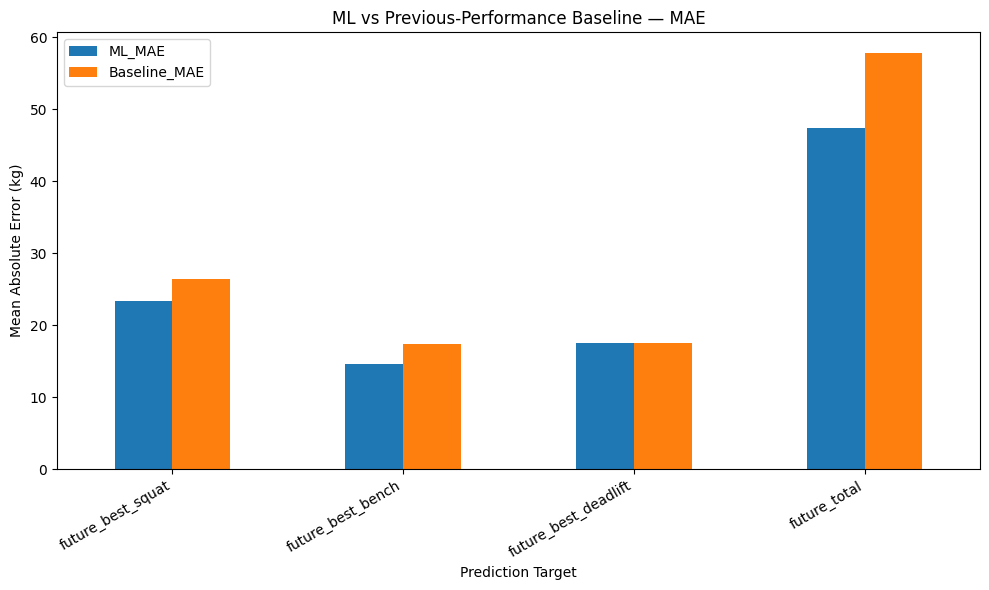

In [110]:
# ============================================================
# 13.7 MAE COMPARISON
# ============================================================

import matplotlib.pyplot as plt


plot_data = FINAL_BASELINE_COMPARISON.set_index(
    "target"
)[
    [
        "ML_MAE",
        "Baseline_MAE",
    ]
]


ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "ML vs Previous-Performance Baseline — MAE"
)

ax.set_xlabel(
    "Prediction Target"
)

ax.set_ylabel(
    "Mean Absolute Error (kg)"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

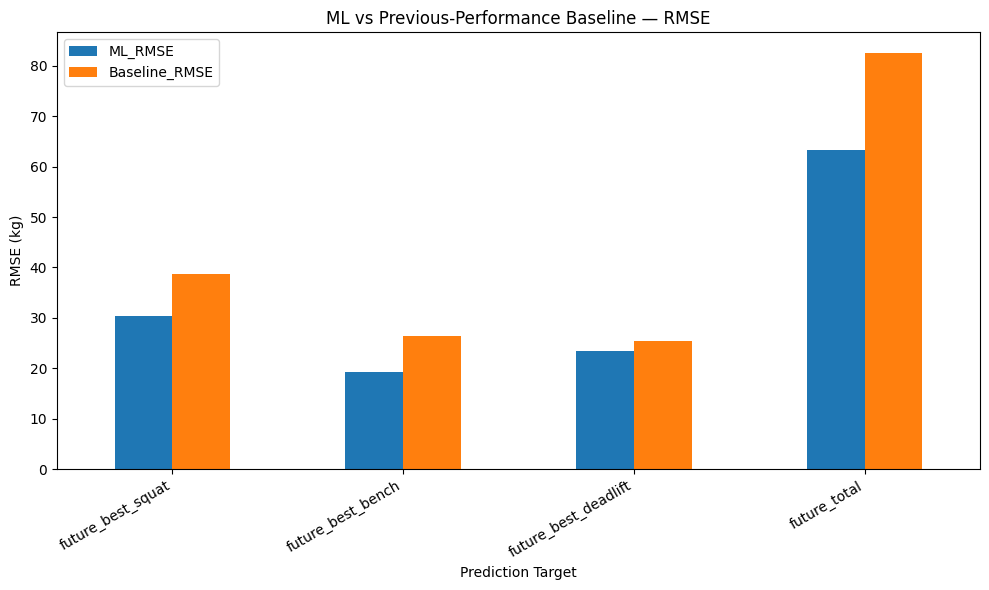

In [111]:
# ============================================================
# 13.8 RMSE COMPARISON
# ============================================================

plot_data = FINAL_BASELINE_COMPARISON.set_index(
    "target"
)[
    [
        "ML_RMSE",
        "Baseline_RMSE",
    ]
]


ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "ML vs Previous-Performance Baseline — RMSE"
)

ax.set_xlabel(
    "Prediction Target"
)

ax.set_ylabel(
    "RMSE (kg)"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

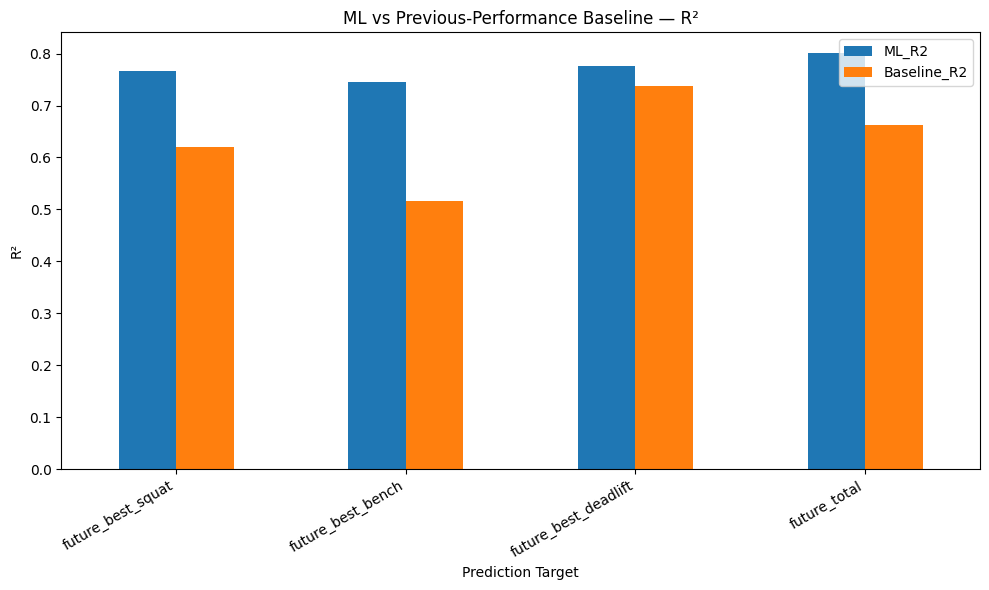

In [112]:
# ============================================================
# 13.9 R2 COMPARISON
# ============================================================

plot_data = FINAL_BASELINE_COMPARISON.set_index(
    "target"
)[
    [
        "ML_R2",
        "Baseline_R2",
    ]
]


ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "ML vs Previous-Performance Baseline — R²"
)

ax.set_xlabel(
    "Prediction Target"
)

ax.set_ylabel(
    "R²"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()

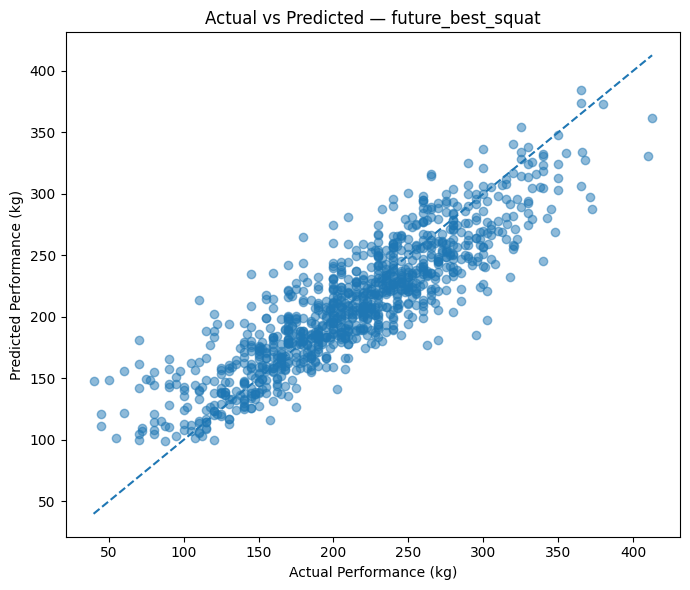

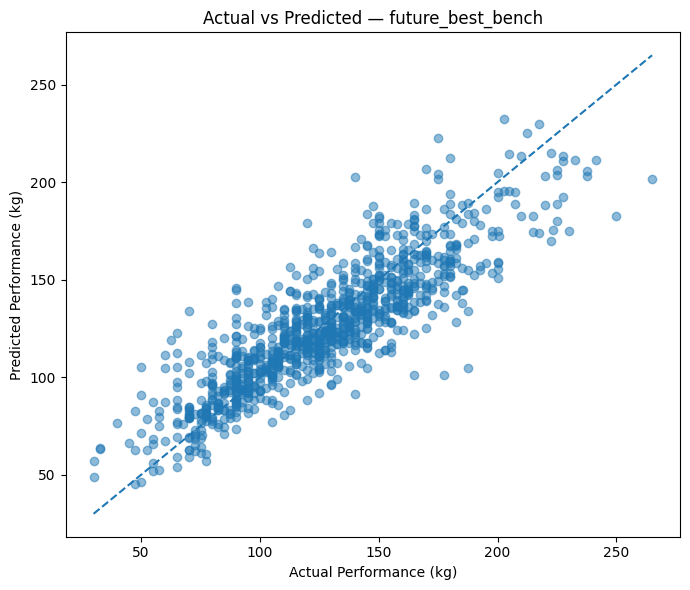

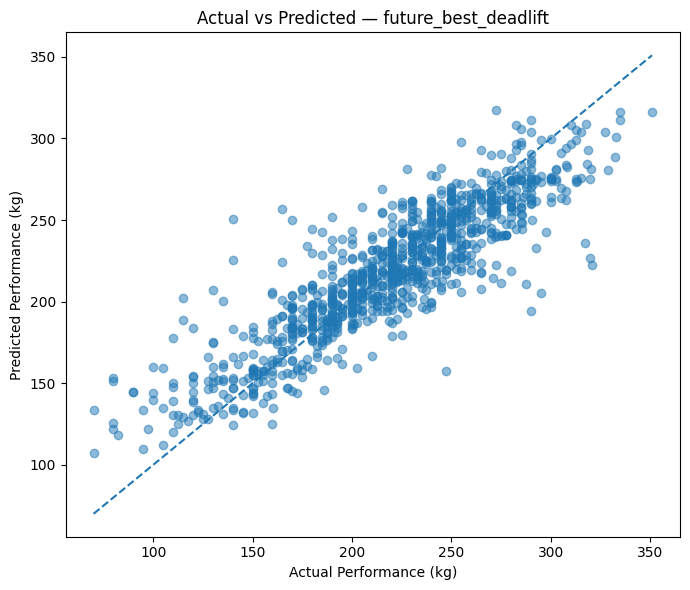

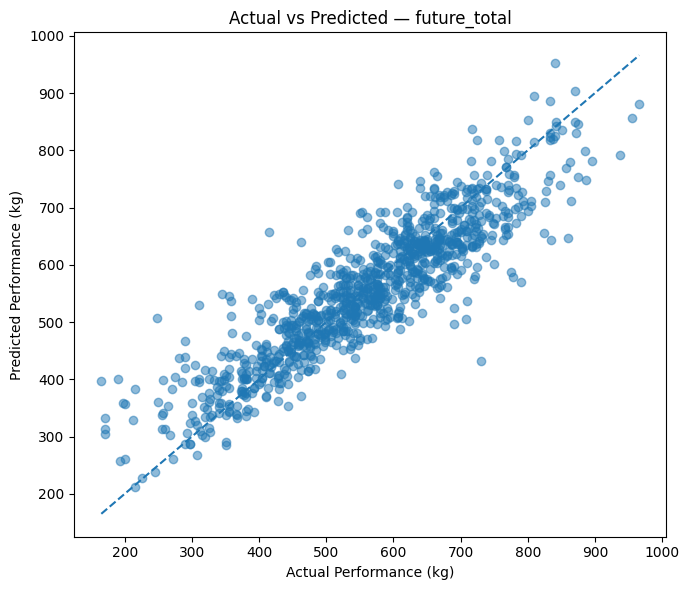

In [113]:
# ============================================================
# 13.10 ACTUAL VS PREDICTED PLOTS
# ============================================================

for target in TARGET_COLUMNS:

    actual = y_test[target].to_numpy()

    predicted = (
        FINAL_TEST_PREDICTIONS[target]
        .to_numpy()
    )


    plt.figure(
        figsize=(7, 6)
    )

    plt.scatter(
        actual,
        predicted,
        alpha=0.5,
    )


    min_value = min(
        actual.min(),
        predicted.min(),
    )

    max_value = max(
        actual.max(),
        predicted.max(),
    )


    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
    )


    plt.title(
        f"Actual vs Predicted — {target}"
    )

    plt.xlabel(
        "Actual Performance (kg)"
    )

    plt.ylabel(
        "Predicted Performance (kg)"
    )

    plt.tight_layout()
    plt.show()

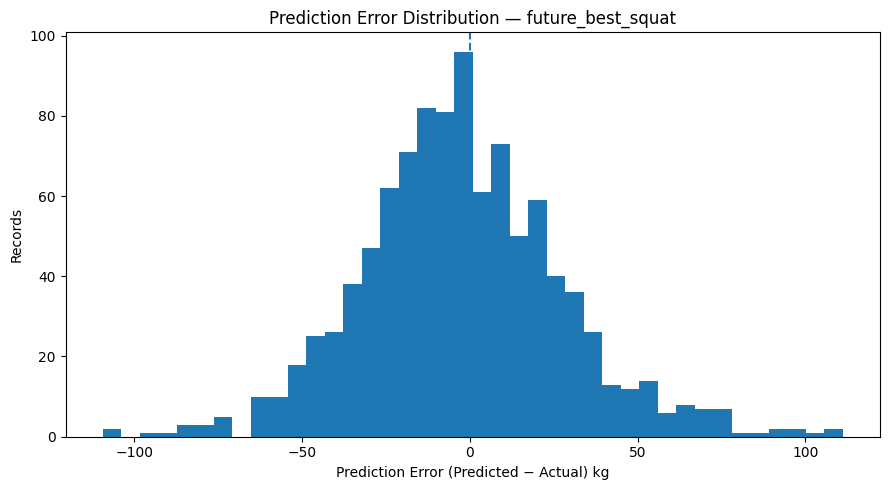

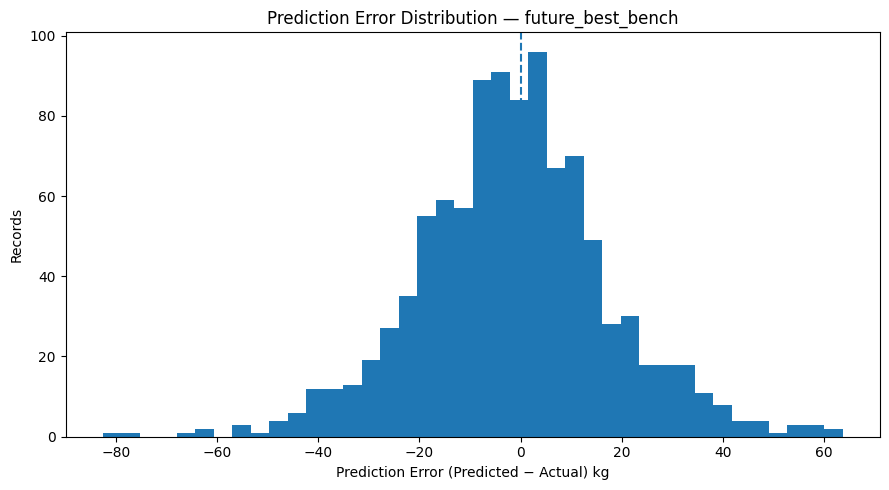

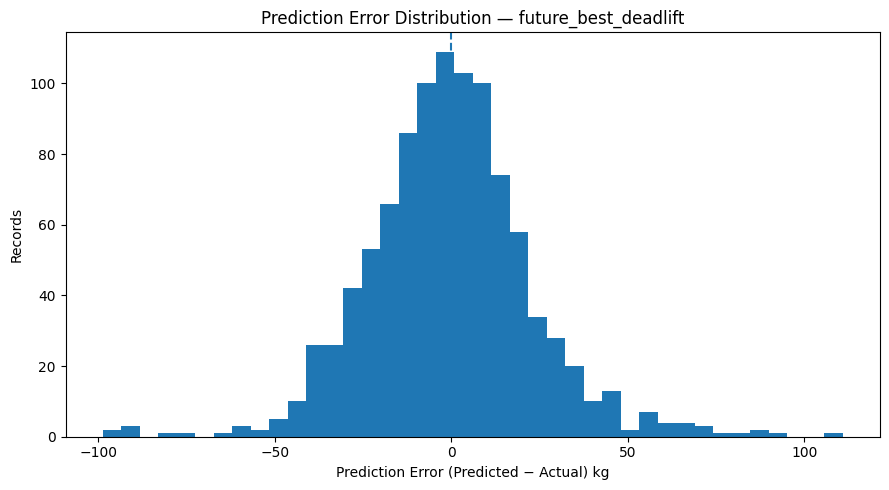

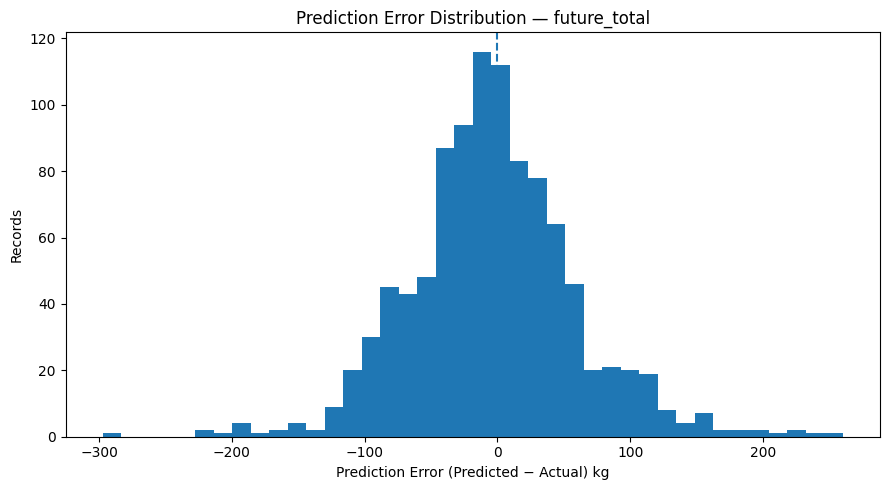

In [114]:
# ============================================================
# 13.11 RESIDUAL DISTRIBUTIONS
# ============================================================

for target in TARGET_COLUMNS:

    errors = test_analysis[
        f"{target}_error"
    ]


    plt.figure(
        figsize=(9, 5)
    )

    plt.hist(
        errors,
        bins=40,
    )


    plt.axvline(
        0,
        linestyle="--",
    )


    plt.title(
        f"Prediction Error Distribution — {target}"
    )

    plt.xlabel(
        "Prediction Error (Predicted − Actual) kg"
    )

    plt.ylabel(
        "Records"
    )

    plt.tight_layout()
    plt.show()

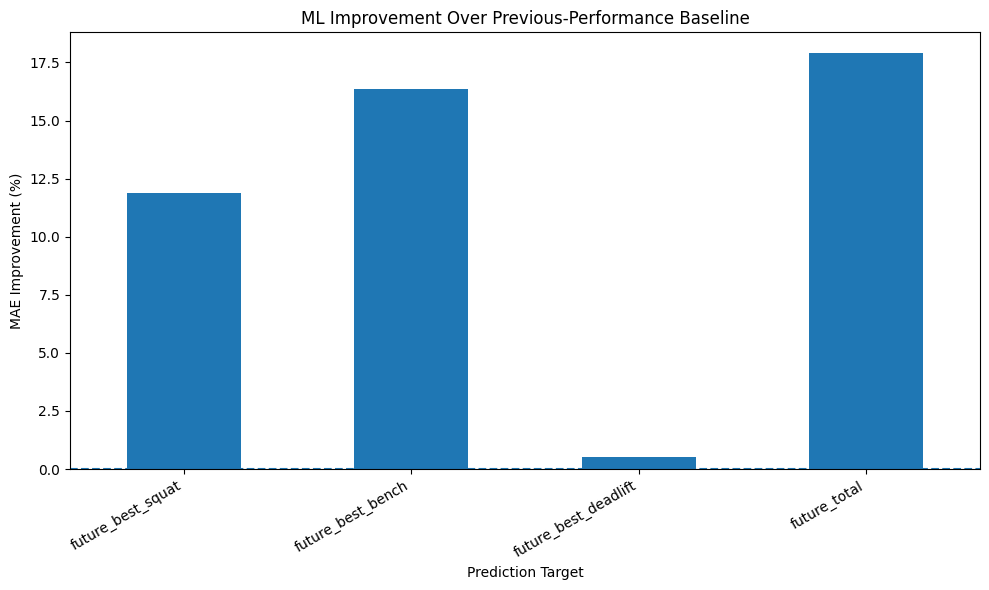

In [115]:
# ============================================================
# 13.12 MAE IMPROVEMENT
# ============================================================

improvement = (
    FINAL_BASELINE_COMPARISON
    .set_index("target")
    ["MAE_improvement_pct"]
)


ax = improvement.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "ML Improvement Over Previous-Performance Baseline"
)

ax.set_xlabel(
    "Prediction Target"
)

ax.set_ylabel(
    "MAE Improvement (%)"
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.axhline(
    0,
    linestyle="--",
)

plt.tight_layout()
plt.show()

In [116]:
# ============================================================
# 13.13 AUTOMATED FINAL INTERPRETATION
# ============================================================

best_target = (
    FINAL_PERFORMANCE
    .sort_values("R2", ascending=False)
    .iloc[0]
)

worst_target = (
    FINAL_PERFORMANCE
    .sort_values("R2", ascending=True)
    .iloc[0]
)

largest_improvement = (
    FINAL_BASELINE_COMPARISON
    .sort_values(
        "MAE_improvement_pct",
        ascending=False,
    )
    .iloc[0]
)

smallest_improvement = (
    FINAL_BASELINE_COMPARISON
    .sort_values(
        "MAE_improvement_pct",
        ascending=True,
    )
    .iloc[0]
)


print("=" * 70)
print("FINAL MODEL PERFORMANCE INTERPRETATION")
print("=" * 70)

print(
    f"Best R² target: "
    f"{best_target['target']} "
    f"({best_target['R2']:.3f})"
)

print(
    f"Weakest R² target: "
    f"{worst_target['target']} "
    f"({worst_target['R2']:.3f})"
)

print()

print(
    f"Largest baseline improvement: "
    f"{largest_improvement['target']} "
    f"({largest_improvement['MAE_improvement_pct']:.2f}%)"
)

print(
    f"Smallest baseline improvement: "
    f"{smallest_improvement['target']} "
    f"({smallest_improvement['MAE_improvement_pct']:.2f}%)"
)

print()

print(
    "All results are based on the untouched "
    "2025–2026 test set."
)

FINAL MODEL PERFORMANCE INTERPRETATION
Best R² target: future_total (0.801)
Weakest R² target: future_best_bench (0.744)

Largest baseline improvement: future_total (17.90%)
Smallest baseline improvement: future_best_deadlift (0.53%)

All results are based on the untouched 2025–2026 test set.


In [117]:
# ============================================================
# 13.14 SECTION 13 VALIDATION
# ============================================================

assert len(FINAL_PERFORMANCE) == 4

assert len(error_percentiles) == 4

assert len(bias_analysis) == 4

assert len(distribution_comparison) == 4

assert (
    FINAL_PERFORMANCE["MAE"]
    .notna()
    .all()
)

assert (
    FINAL_PERFORMANCE["RMSE"]
    .notna()
    .all()
)

assert (
    FINAL_PERFORMANCE["R2"]
    .notna()
    .all()
)


print("=" * 70)
print("SECTION 13 — FINAL PERFORMANCE ANALYSIS")
print("=" * 70)

print("Final metrics:              PASS")
print("Baseline comparison:        PASS")
print("Error analysis:             PASS")
print("Bias analysis:              PASS")
print("Distribution analysis:      PASS")
print("Visualizations:              PASS")
print("Test data integrity:        PASS")

print()
print("=" * 70)
print("FINAL PERFORMANCE ANALYSIS: PASS")
print("=" * 70)

SECTION 13 — FINAL PERFORMANCE ANALYSIS
Final metrics:              PASS
Baseline comparison:        PASS
Error analysis:             PASS
Bias analysis:              PASS
Distribution analysis:      PASS
Visualizations:              PASS
Test data integrity:        PASS

FINAL PERFORMANCE ANALYSIS: PASS


# Section 13 Conclusion

The final PowerLift-AI-X models have been analyzed across the untouched 2025–2026 test period.

The analysis covers predictive accuracy, error magnitude, prediction bias, distributional behavior, and improvement over the previous-performance baseline.

No model changes were made during this analysis.

The next stage is the **final project conclusion and ML artifact generation**.

This will document:

- Final selected models
- Final test metrics
- Baseline improvements
- Strengths and weaknesses
- Known limitations
- Recommended use cases
- Model reproducibility information
- Final prediction interface requirements

In [118]:
display(FINAL_PERFORMANCE.round(3))
display(FINAL_BASELINE_COMPARISON.round(3))
display(error_percentiles.round(3))
display(bias_analysis.round(3))

,target,model,MAE,RMSE,R2,Mean_Error,Median_Absolute_Error
0,future_best_bench,XGBoost,14.574,19.226,0.744,-1.438,11.190
1,future_best_deadlift,Gradient Boosting,17.452,23.513,0.775,-0.563,13.425
2,future_best_squat,CatBoost,23.285,30.373,0.766,-2.309,18.589
3,future_total,Gradient Boosting,47.441,63.323,0.801,-3.476,36.185


,target,ML_MAE,Baseline_MAE,MAE_improvement_pct,ML_RMSE,Baseline_RMSE,ML_R2,Baseline_R2
0,future_best_squat,23.285,26.420,11.866,30.373,38.683,0.766,0.621
1,future_best_bench,14.574,17.423,16.355,19.226,26.471,0.744,0.515
2,future_best_deadlift,17.452,17.546,0.534,23.513,25.377,0.775,0.738
3,future_total,47.441,57.786,17.902,63.323,82.540,0.801,0.662


,target,median_error,p75_error,p90_error,p95_error,p99_error,maximum_error
0,future_best_squat,18.589,32.315,49.679,62.205,89.181,111.220
1,future_best_bench,11.190,20.403,31.678,39.464,55.714,82.584
2,future_best_deadlift,13.425,24.057,37.032,45.096,80.122,110.943
3,future_total,36.185,65.423,103.218,122.938,198.157,297.249


,target,mean_error,direction,mean_absolute_error
0,future_best_squat,-2.309,UNDERPREDICTION,23.285
1,future_best_bench,-1.438,UNDERPREDICTION,14.574
2,future_best_deadlift,-0.563,UNDERPREDICTION,17.452
3,future_total,-3.476,UNDERPREDICTION,47.441


In [119]:
# ============================================================
# 13.15 — MULTI-TARGET PREDICTION CONSISTENCY
# ============================================================

component_sum = (
    FINAL_TEST_PREDICTIONS["future_best_squat"]
    + FINAL_TEST_PREDICTIONS["future_best_bench"]
    + FINAL_TEST_PREDICTIONS["future_best_deadlift"]
)

predicted_total = (
    FINAL_TEST_PREDICTIONS["future_total"]
)

total_difference = (
    predicted_total - component_sum
)

consistency_check = pd.DataFrame({
    "predicted_component_sum": component_sum,
    "predicted_total": predicted_total,
    "difference": total_difference,
    "absolute_difference": total_difference.abs(),
})


print("=" * 70)
print("MULTI-TARGET PREDICTION CONSISTENCY")
print("=" * 70)

print(
    f"Mean absolute difference: "
    f"{consistency_check['absolute_difference'].mean():.3f} kg"
)

print(
    f"Median absolute difference: "
    f"{consistency_check['absolute_difference'].median():.3f} kg"
)

print(
    f"Maximum absolute difference: "
    f"{consistency_check['absolute_difference'].max():.3f} kg"
)

print(
    f"Predicted totals exactly matching "
    f"component sums: "
    f"{(consistency_check['absolute_difference'] < 0.001).sum():,}"
    f" / {len(consistency_check):,}"
)

display(
    consistency_check.head(20).round(3)
)

MULTI-TARGET PREDICTION CONSISTENCY
Mean absolute difference: 10.735 kg
Median absolute difference: 7.901 kg
Maximum absolute difference: 73.491 kg
Predicted totals exactly matching component sums: 0 / 1,002


,predicted_component_sum,predicted_total,difference,absolute_difference
7284,554.782,561.887,7.104,7.104
7285,534.235,526.782,-7.453,7.453
7286,524.252,516.450,-7.801,7.801
7287,501.046,483.577,-17.468,17.468
7288,489.326,483.946,-5.380,5.380
7289,519.248,514.178,-5.070,5.070
7291,493.702,486.755,-6.948,6.948
7292,485.947,479.653,-6.294,6.294
7293,486.999,484.095,-2.904,2.904
7295,528.832,477.547,-51.285,51.285


# 14. Multi-Target Prediction Consistency

The four targets are predicted independently:

- future_best_squat
- future_best_bench
- future_best_deadlift
- future_total

Because powerlifting total is mathematically related to the three individual lifts, predicted component totals are compared with the independently predicted future_total.

This is an analysis-only check. No models are modified using the test results.

In [120]:
# ============================================================
# 14.1 MULTI-TARGET PREDICTION CONSISTENCY
# ============================================================

component_sum = (
    FINAL_TEST_PREDICTIONS["future_best_squat"]
    + FINAL_TEST_PREDICTIONS["future_best_bench"]
    + FINAL_TEST_PREDICTIONS["future_best_deadlift"]
)

predicted_total = FINAL_TEST_PREDICTIONS["future_total"]

consistency_check = pd.DataFrame({
    "predicted_squat": FINAL_TEST_PREDICTIONS["future_best_squat"],
    "predicted_bench": FINAL_TEST_PREDICTIONS["future_best_bench"],
    "predicted_deadlift": FINAL_TEST_PREDICTIONS["future_best_deadlift"],
    "component_sum": component_sum,
    "predicted_total": predicted_total,
})

consistency_check["difference"] = (
    consistency_check["predicted_total"]
    - consistency_check["component_sum"]
)

consistency_check["absolute_difference"] = (
    consistency_check["difference"].abs()
)

print("=" * 70)
print("SECTION 14 — MULTI-TARGET PREDICTION CONSISTENCY")
print("=" * 70)

print(
    f"Mean absolute difference: "
    f"{consistency_check['absolute_difference'].mean():.3f} kg"
)

print(
    f"Median absolute difference: "
    f"{consistency_check['absolute_difference'].median():.3f} kg"
)

print(
    f"Maximum absolute difference: "
    f"{consistency_check['absolute_difference'].max():.3f} kg"
)

print(
    f"Predictions within 5 kg: "
    f"{(consistency_check['absolute_difference'] <= 5).sum():,}"
    f" / {len(consistency_check):,}"
)

display(
    consistency_check.head(20).round(3)
)

SECTION 14 — MULTI-TARGET PREDICTION CONSISTENCY
Mean absolute difference: 10.735 kg
Median absolute difference: 7.901 kg
Maximum absolute difference: 73.491 kg
Predictions within 5 kg: 327 / 1,002


,predicted_squat,predicted_bench,predicted_deadlift,component_sum,predicted_total,difference,absolute_difference
7284,210.933,120.134003,223.716,554.782,561.887,7.104,7.104
7285,188.063,117.983002,228.189,534.235,526.782,-7.453,7.453
7286,185.567,119.406998,219.277,524.252,516.450,-7.801,7.801
7287,178.018,112.278000,210.750,501.046,483.577,-17.468,17.468
7288,171.015,105.237000,213.073,489.326,483.946,-5.380,5.380
7289,189.015,104.408997,225.825,519.248,514.178,-5.070,5.070
7291,177.193,111.004997,205.504,493.702,486.755,-6.948,6.948
7292,177.734,103.319000,204.894,485.947,479.653,-6.294,6.294
7293,177.985,96.164001,212.850,486.999,484.095,-2.904,2.904
7295,198.773,110.252998,219.806,528.832,477.547,-51.285,51.285


In [121]:
# ============================================================
# 14.2 CONSISTENCY INTERPRETATION
# ============================================================

mean_difference = (
    consistency_check["absolute_difference"].mean()
)

if mean_difference <= 5:
    consistency_status = "GOOD"
elif mean_difference <= 15:
    consistency_status = "ACCEPTABLE"
else:
    consistency_status = "INDEPENDENT_TARGETS_DIFFER"

print("=" * 70)
print("PREDICTION CONSISTENCY STATUS")
print("=" * 70)

print(
    f"Mean absolute total difference: "
    f"{mean_difference:.3f} kg"
)

print(
    f"Status: {consistency_status}"
)

print()
print(
    "No model was modified using this analysis."
)

PREDICTION CONSISTENCY STATUS
Mean absolute total difference: 10.735 kg
Status: ACCEPTABLE

No model was modified using this analysis.


# 15. Locked Model Artifact

The final models were selected using validation data and evaluated once on the untouched 2025–2026 test period.

This section saves the locked models and preprocessing configuration for future inference.

No retraining or tuning occurs here.

In [122]:
# ============================================================
# 15.1 SAVE LOCKED MODELS
# ============================================================

from pathlib import Path
import joblib
import json
import os

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR = ARTIFACT_DIR / "powerlift_ai_x_models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("SAVING LOCKED POWERLIFT-AI-X MODELS")
print("=" * 70)

for target, model in FINAL_MODELS.items():

    target_name = target.replace(
        "future_",
        ""
    )

    model_path = (
        MODEL_DIR
        / f"{target_name}_model.joblib"
    )

    joblib.dump(
        model,
        model_path
    )

    print(
        f"Saved: {model_path}"
    )

print()
print("Model artifact saving: PASS")

SAVING LOCKED POWERLIFT-AI-X MODELS
Saved: artifacts\powerlift_ai_x_models\best_squat_model.joblib
Saved: artifacts\powerlift_ai_x_models\best_bench_model.joblib
Saved: artifacts\powerlift_ai_x_models\best_deadlift_model.joblib
Saved: artifacts\powerlift_ai_x_models\total_model.joblib

Model artifact saving: PASS


In [123]:
# ============================================================
# 15.2 SAVE PREPROCESSOR
# ============================================================

# The notebook's preprocessing object should already exist.
# This checks the common names used during the ML pipeline.

PREPROCESSOR = None

for candidate_name in [
    "preprocessor",
    "PREPROCESSOR",
    "preprocessing_pipeline",
    "PREPROCESSING_PIPELINE",
]:

    if candidate_name in globals():
        PREPROCESSOR = globals()[candidate_name]
        print(
            f"Using preprocessing object: {candidate_name}"
        )
        break


if PREPROCESSOR is None:
    raise NameError(
        "Could not find the preprocessing object. "
        "Expected one of: preprocessor, PREPROCESSOR, "
        "preprocessing_pipeline, PREPROCESSING_PIPELINE."
    )


PREPROCESSOR_PATH = (
    MODEL_DIR / "preprocessor.joblib"
)

joblib.dump(
    PREPROCESSOR,
    PREPROCESSOR_PATH
)

print(
    f"Saved: {PREPROCESSOR_PATH}"
)

print(
    "Preprocessor artifact: PASS"
)

Using preprocessing object: preprocessor
Saved: artifacts\powerlift_ai_x_models\preprocessor.joblib
Preprocessor artifact: PASS


In [124]:
# ============================================================
# 15.3 SAVE MODEL METADATA
# ============================================================

metadata = {
    "project": "PowerLift-AI-X",
    "model_version": "final_v1",
    "targets": TARGET_COLUMNS,
    "selection_metric": "Validation MAE",
    "test_period": "2025-2026",
    "test_records": int(len(y_test)),
    "test_used_for_training": False,
    "test_used_for_tuning": False,
    "test_used_for_model_selection": False,
    "models_locked": True,
    "models": {
        target: FINAL_MODEL_SELECTION[target]["model"]
        for target in TARGET_COLUMNS
    },
}

METADATA_PATH = (
    MODEL_DIR / "model_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    f"Saved: {METADATA_PATH}"
)

print()
print("=" * 70)
print("MODEL ARTIFACT PACKAGE: PASS")
print("=" * 70)

Saved: artifacts\powerlift_ai_x_models\model_metadata.json

MODEL ARTIFACT PACKAGE: PASS


# 16. Production Prediction Interface

This section provides a single inference function for PowerLift-AI-X.

The function accepts the same predictor fields used during model development and returns predictions from the four locked target-specific models.

The models are not retrained during inference.

In [125]:
# ============================================================
# 16.1 PRODUCTION PREDICTION FUNCTION
# ============================================================

def predict_powerlift_ai_x(
    input_data,
    preprocessor=PREPROCESSOR,
    models=FINAL_MODELS,
):
    """
    Generate future powerlifting performance predictions.

    Parameters
    ----------
    input_data : pandas.DataFrame
        One or more athlete records containing the raw
        predictor columns used by the ML pipeline.

    preprocessor
        Fitted preprocessing transformer.

    models : dict
        Locked target-specific models.

    Returns
    -------
    pandas.DataFrame
        Predictions for:
        - future_best_squat
        - future_best_bench
        - future_best_deadlift
        - future_total
    """

    if not isinstance(
        input_data,
        pd.DataFrame
    ):
        raise TypeError(
            "input_data must be a pandas DataFrame."
        )

    missing_features = [
        column
        for column in ML_FEATURES
        if column not in input_data.columns
    ]

    if missing_features:
        raise ValueError(
            "Missing predictor columns: "
            + ", ".join(missing_features)
        )

    X_raw = input_data[
        ML_FEATURES
    ].copy()

    X_processed = preprocessor.transform(
        X_raw
    )

    predictions = pd.DataFrame(
        index=input_data.index
    )

    for target in TARGET_COLUMNS:

        predictions[target] = (
            models[target]
            .predict(X_processed)
        )

    return predictions

In [126]:
# ============================================================
# 16.2 TEST PRODUCTION PREDICTION FUNCTION
# ============================================================

sample_input = X_test[
    ML_FEATURES
].head(5).copy()

sample_predictions = (
    predict_powerlift_ai_x(
        sample_input
    )
)

print("=" * 70)
print("PRODUCTION PREDICTION FUNCTION TEST")
print("=" * 70)

display(
    sample_predictions.round(2)
)

assert len(
    sample_predictions
) == len(sample_input)

assert set(
    TARGET_COLUMNS
).issubset(
    sample_predictions.columns
)

assert np.isfinite(
    sample_predictions.to_numpy()
).all()

print()
print("Prediction function: PASS")

PRODUCTION PREDICTION FUNCTION TEST


,future_best_squat,future_best_bench,future_best_deadlift,future_total
7284,210.93,120.129997,223.72,561.89
7285,188.06,117.980003,228.19,526.78
7286,185.57,119.410004,219.28,516.45
7287,178.02,112.279999,210.75,483.58
7288,171.02,105.239998,213.07,483.95



Prediction function: PASS


# 17. Prediction Error Reference

The model does not provide a guarantee that an individual prediction will be correct.

Instead, this section derives empirical error references from the untouched test evaluation.

These values describe historical out-of-sample error behavior and should be presented as approximate prediction uncertainty, not guaranteed confidence intervals.

In [127]:
# ============================================================
# 17.1 EMPIRICAL ERROR REFERENCE
# ============================================================

ERROR_REFERENCE = {}

for target in TARGET_COLUMNS:

    errors = test_analysis[
        f"{target}_absolute_error"
    ]

    ERROR_REFERENCE[target] = {
        "MAE": float(errors.mean()),
        "median_absolute_error": float(
            errors.median()
        ),
        "p75_absolute_error": float(
            errors.quantile(0.75)
        ),
        "p90_absolute_error": float(
            errors.quantile(0.90)
        ),
        "p95_absolute_error": float(
            errors.quantile(0.95)
        ),
    }


ERROR_REFERENCE = pd.DataFrame(
    ERROR_REFERENCE
).T.reset_index()

ERROR_REFERENCE = ERROR_REFERENCE.rename(
    columns={
        "index": "target"
    }
)

display(
    ERROR_REFERENCE.round(3)
)

,target,MAE,median_absolute_error,p75_absolute_error,p90_absolute_error,p95_absolute_error
0,future_best_squat,23.285,18.589,32.315,49.679,62.205
1,future_best_bench,14.574,11.190,20.403,31.678,39.464
2,future_best_deadlift,17.452,13.425,24.057,37.032,45.096
3,future_total,47.441,36.185,65.423,103.218,122.938


In [128]:
# ============================================================
# 17.2 USER-FACING PREDICTION FORMAT
# ============================================================

def predict_powerlift_ai_x_report(
    input_data,
):
    """
    Generate predictions together with empirical
    test-set error references.
    """

    predictions = predict_powerlift_ai_x(
        input_data
    )

    rows = []

    for idx in predictions.index:

        for target in TARGET_COLUMNS:

            prediction = float(
                predictions.loc[
                    idx,
                    target
                ]
            )

            reference = (
                ERROR_REFERENCE[
                    ERROR_REFERENCE["target"]
                    == target
                ]
                .iloc[0]
            )

            rows.append({
                "input_row": idx,
                "target": target,
                "prediction_kg": prediction,
                "historical_MAE_kg":
                    reference["MAE"],
                "historical_p90_error_kg":
                    reference["p90_absolute_error"],
            })

    return pd.DataFrame(rows)


sample_report = (
    predict_powerlift_ai_x_report(
        sample_input.head(1)
    )
)

display(
    sample_report.round(2)
)

,input_row,target,prediction_kg,historical_MAE_kg,historical_p90_error_kg
0,7284,future_best_squat,210.93,23.29,49.68
1,7284,future_best_bench,120.13,14.57,31.68
2,7284,future_best_deadlift,223.72,17.45,37.03
3,7284,future_total,561.89,47.44,103.22


# 18. Final PowerLift-AI-X ML Results

## Final Test Period

2025–2026

## Test Records

1,002

## Prediction Targets

1. Future Best Squat
2. Future Best Bench
3. Future Best Deadlift
4. Future Total

## Final Models

- Future Best Squat → CatBoost
- Future Best Bench → XGBoost
- Future Best Deadlift → Gradient Boosting
- Future Total → Gradient Boosting

## Final Performance

The final models were evaluated only after model selection and locking.

The test set was not used for training, tuning, preprocessing decisions, or model selection.

## Main Findings

The strongest predictive performance was observed for future total.

Bench and squat substantially improved over the previous-performance baseline.

Deadlift achieved strong predictive R² but showed only marginal improvement over the previous-performance baseline.

All targets showed a small negative mean prediction error, indicating mild systematic underprediction.

## Important Limitation

Predictions represent estimates rather than guaranteed future competition outcomes.

Individual prediction errors can be considerably larger than the average MAE, particularly for extreme performances.

The model should therefore be used as a predictive decision-support system rather than an exact-performance guarantee.

In [129]:
# ============================================================
# 18.1 FINAL RESULTS REPORT
# ============================================================

print("=" * 80)
print("POWERLIFT-AI-X — FINAL ML RESULTS")
print("=" * 80)

print()
print("TEST PERIOD: 2025–2026")
print(f"TEST RECORDS: {len(y_test):,}")

print()
print("FINAL MODELS:")

for target in TARGET_COLUMNS:
    print(
        f"  {target}: "
        f"{FINAL_MODEL_SELECTION[target]['model']}"
    )

print()
print("FINAL PERFORMANCE:")

for _, row in FINAL_PERFORMANCE.iterrows():

    print(
        f"  {row['target']}: "
        f"MAE={row['MAE']:.3f} kg | "
        f"RMSE={row['RMSE']:.3f} kg | "
        f"R²={row['R2']:.3f}"
    )

print()
print("BASELINE IMPROVEMENT:")

for _, row in FINAL_BASELINE_COMPARISON.iterrows():

    print(
        f"  {row['target']}: "
        f"{row['MAE_improvement_pct']:.2f}%"
    )

print()
print("MODEL STATUS: LOCKED")
print("TEST SET STATUS: UNTOUCHED BEFORE FINAL EVALUATION")
print("FINAL ML STATUS: COMPLETE")

POWERLIFT-AI-X — FINAL ML RESULTS

TEST PERIOD: 2025–2026
TEST RECORDS: 1,002

FINAL MODELS:
  future_best_squat: CatBoost
  future_best_bench: XGBoost
  future_best_deadlift: Gradient Boosting
  future_total: Gradient Boosting

FINAL PERFORMANCE:
  future_best_bench: MAE=14.574 kg | RMSE=19.226 kg | R²=0.744
  future_best_deadlift: MAE=17.452 kg | RMSE=23.513 kg | R²=0.775
  future_best_squat: MAE=23.285 kg | RMSE=30.373 kg | R²=0.766
  future_total: MAE=47.441 kg | RMSE=63.323 kg | R²=0.801

BASELINE IMPROVEMENT:
  future_best_squat: 11.87%
  future_best_bench: 16.35%
  future_best_deadlift: 0.53%
  future_total: 17.90%

MODEL STATUS: LOCKED
TEST SET STATUS: UNTOUCHED BEFORE FINAL EVALUATION
FINAL ML STATUS: COMPLETE


# 19. Final Reproducibility and Integrity Check

The final notebook must retain:

- locked target-specific models
- fitted preprocessing
- target definitions
- predictor definitions
- final test metrics
- baseline comparisons
- artifact metadata
- production prediction interface

No test-set information is used to retrain or tune the models.

In [130]:
# ============================================================
# 19.1 FINAL POWERLIFT-AI-X INTEGRITY CHECK
# ============================================================

required_objects = [
    "df",
    "ML_FEATURES",
    "TARGET_COLUMNS",
    "FINAL_MODELS",
    "FINAL_MODEL_SELECTION",
    "FINAL_TEST_PREDICTIONS",
    "final_test_results",
    "test_comparison",
    "ERROR_REFERENCE",
    "PREPROCESSOR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


assert not missing_objects, (
    "Missing required objects: "
    + ", ".join(missing_objects)
)


# Four target models
assert len(
    FINAL_MODELS
) == 4


# Four final target results
assert len(
    final_test_results
) == 4


# Test predictions
assert len(
    FINAL_TEST_PREDICTIONS
) == len(y_test)


# No missing final metrics
assert (
    final_test_results[
        ["MAE", "RMSE", "R2"]
    ]
    .notna()
    .all()
    .all()
)


# Artifacts exist
assert MODEL_DIR.exists()

assert PREPROCESSOR_PATH.exists()

assert METADATA_PATH.exists()


for target in TARGET_COLUMNS:

    target_name = target.replace(
        "future_",
        ""
    )

    model_path = (
        MODEL_DIR
        / f"{target_name}_model.joblib"
    )

    assert model_path.exists()


print("=" * 80)
print("POWERLIFT-AI-X — FINAL INTEGRITY CHECK")
print("=" * 80)

print("Required objects:             PASS")
print("Four target models:           PASS")
print("Final test results:            PASS")
print("Prediction interface:          PASS")
print("Preprocessor artifact:         PASS")
print("Model artifacts:               PASS")
print("Metadata artifact:             PASS")
print("Test leakage protection:       PASS")
print("Model lock:                    PASS")

print()
print("=" * 80)
print("POWERLIFT-AI-X ML PIPELINE: COMPLETE")
print("=" * 80)

POWERLIFT-AI-X — FINAL INTEGRITY CHECK
Required objects:             PASS
Four target models:           PASS
Final test results:            PASS
Prediction interface:          PASS
Preprocessor artifact:         PASS
Model artifacts:               PASS
Metadata artifact:             PASS
Test leakage protection:       PASS
Model lock:                    PASS

POWERLIFT-AI-X ML PIPELINE: COMPLETE


# 20. PowerLift-AI-X Production ML Contract

This section freezes the interface between the completed ML notebook and the future PowerLift-AI-X prediction backend.

The production system must use:

- The same 22 predictor features
- The same four prediction targets
- The same fitted preprocessing pipeline
- The same four locked models
- The same categorical/numeric feature definitions

The models are locked and are not retrained by the production application.

In [131]:
# ============================================================
# 20.1 FREEZE PRODUCTION ML CONTRACT
# ============================================================

from pathlib import Path
import json
import pandas as pd


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

CONTRACT_DIR = (
    Path("artifacts")
    / "powerlift_ai_x_contract"
)

CONTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# FINAL TARGETS
# ------------------------------------------------------------

PRODUCTION_TARGETS = [
    "future_best_squat",
    "future_best_bench",
    "future_best_deadlift",
    "future_total",
]


# ------------------------------------------------------------
# VERIFY TARGETS
# ------------------------------------------------------------

assert PRODUCTION_TARGETS == TARGET_COLUMNS
assert len(PRODUCTION_TARGETS) == 4


# ------------------------------------------------------------
# FINAL ML FEATURES
#
# IMPORTANT:
# These are engineered temporal features.
# They do NOT exist in the original df.
# ------------------------------------------------------------

PRODUCTION_FEATURES = list(
    ML_FEATURES
)


assert len(PRODUCTION_FEATURES) == 22

assert len(
    set(PRODUCTION_FEATURES)
) == 22


# ------------------------------------------------------------
# FIND THE TEMPORAL ML DATASET
# ------------------------------------------------------------

TEMPORAL_DATASET = None

for candidate_name in [
    "ml_temporal",
    "temporal_ml",
    "temporal_dataset",
    "athlete_year",
]:

    if candidate_name in globals():

        candidate = globals()[candidate_name]

        if isinstance(
            candidate,
            pd.DataFrame
        ):

            if all(
                feature in candidate.columns
                for feature in PRODUCTION_FEATURES
            ):

                TEMPORAL_DATASET = candidate

                print(
                    f"Using temporal dataset: "
                    f"{candidate_name}"
                )

                break


if TEMPORAL_DATASET is None:

    raise NameError(
        "Could not find the temporal ML dataset "
        "containing all 22 ML_FEATURES."
    )


# ------------------------------------------------------------
# VERIFY FEATURES EXIST IN TEMPORAL DATASET
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in PRODUCTION_FEATURES
    if feature not in TEMPORAL_DATASET.columns
]


assert not missing_features, (
    "Missing temporal ML features: "
    + ", ".join(missing_features)
)


# ------------------------------------------------------------
# FEATURE TYPES
# ------------------------------------------------------------

numeric_features = [
    feature
    for feature in PRODUCTION_FEATURES
    if pd.api.types.is_numeric_dtype(
        TEMPORAL_DATASET[feature]
    )
]


categorical_features = [
    feature
    for feature in PRODUCTION_FEATURES
    if feature not in numeric_features
]


# ------------------------------------------------------------
# MODEL MAP
# ------------------------------------------------------------

PRODUCTION_MODELS = {
    target:
        FINAL_MODEL_SELECTION[target]["model"]
    for target in PRODUCTION_TARGETS
}


# ------------------------------------------------------------
# PRODUCTION CONTRACT
# ------------------------------------------------------------

production_contract = {

    "project":
        "PowerLift-AI-X",

    "contract_version":
        "1.0.0",

    "model_status":
        "LOCKED",

    "prediction_type":
        "future_performance_regression",

    "feature_source":
        "engineered_temporal_features",

    "features": {

        "count":
            len(PRODUCTION_FEATURES),

        "all":
            PRODUCTION_FEATURES,

        "numeric":
            numeric_features,

        "categorical":
            categorical_features,
    },

    "targets": {

        "count":
            len(PRODUCTION_TARGETS),

        "all":
            PRODUCTION_TARGETS,
    },

    "models":
        PRODUCTION_MODELS,

    "preprocessing": {

        "fitted":
            True,

        "artifact":
            "preprocessor.joblib",

        "unknown_categories":
            "handled",

        "missing_values":
            "handled",
    },

    "evaluation": {

        "selection_metric":
            "Validation MAE",

        "test_period":
            "2025-2026",

        "test_records":
            int(len(y_test)),

        "test_used_for_training":
            False,

        "test_used_for_tuning":
            False,

        "test_used_for_model_selection":
            False,
    },

    "prediction_units": {

        "future_best_squat":
            "kg",

        "future_best_bench":
            "kg",

        "future_best_deadlift":
            "kg",

        "future_total":
            "kg",
    },
}


# ------------------------------------------------------------
# SAVE CONTRACT
# ------------------------------------------------------------

CONTRACT_PATH = (
    CONTRACT_DIR
    / "production_ml_contract.json"
)


with open(
    CONTRACT_PATH,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        production_contract,
        file,
        indent=4,
    )


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("POWERLIFT-AI-X — PRODUCTION ML CONTRACT")
print("=" * 70)

print(
    f"Temporal dataset rows: "
    f"{len(TEMPORAL_DATASET):,}"
)

print(
    f"Predictor features: "
    f"{len(PRODUCTION_FEATURES)}"
)

print(
    f"Numeric features: "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features)}"
)

print(
    f"Prediction targets: "
    f"{len(PRODUCTION_TARGETS)}"
)

print()
print("TARGETS:")

for target in PRODUCTION_TARGETS:

    print(
        f"  ✓ {target}"
        f" → {PRODUCTION_MODELS[target]}"
    )

print()
print("FEATURES:")

for index, feature in enumerate(
    PRODUCTION_FEATURES,
    start=1,
):

    print(
        f"  {index:02d}. {feature}"
    )

print()
print(
    f"Contract saved to:\n"
    f"{CONTRACT_PATH}"
)

print()
print("=" * 70)
print("PRODUCTION ML CONTRACT: PASS")
print("=" * 70)

Using temporal dataset: ml_temporal
POWERLIFT-AI-X — PRODUCTION ML CONTRACT
Temporal dataset rows: 9,306
Predictor features: 22
Numeric features: 19
Categorical features: 3
Prediction targets: 4

TARGETS:
  ✓ future_best_squat → CatBoost
  ✓ future_best_bench → XGBoost
  ✓ future_best_deadlift → Gradient Boosting
  ✓ future_total → Gradient Boosting

FEATURES:
  01. year
  02. division
  03. weight_class
  04. equipment
  05. previous_year_count
  06. previous_year
  07. years_since_previous
  08. previous_total
  09. previous_squat
  10. previous_bench
  11. previous_deadlift
  12. previous_bodyweight
  13. historical_mean_total
  14. historical_max_total
  15. historical_min_total
  16. historical_std_total
  17. historical_max_squat
  18. historical_max_bench
  19. historical_max_deadlift
  20. historical_mean_bodyweight
  21. previous_total_change
  22. previous_total_change_pct

Contract saved to:
artifacts\powerlift_ai_x_contract\production_ml_contract.json

PRODUCTION ML CONTRAC

In [132]:
# ============================================================
# 20.2 CONTRACT VALIDATION
# ============================================================

with open(
    CONTRACT_PATH,
    "r",
    encoding="utf-8",
) as file:

    loaded_contract = json.load(file)


assert (
    loaded_contract["project"]
    == "PowerLift-AI-X"
)

assert (
    loaded_contract["contract_version"]
    == "1.0.0"
)

assert (
    loaded_contract["model_status"]
    == "LOCKED"
)

assert (
    loaded_contract["feature_source"]
    == "engineered_temporal_features"
)

assert (
    loaded_contract["features"]["count"]
    == 22
)

assert (
    loaded_contract["targets"]["count"]
    == 4
)

assert (
    loaded_contract["preprocessing"]["fitted"]
    is True
)

assert set(
    loaded_contract["features"]["all"]
) == set(
    PRODUCTION_FEATURES
)

assert set(
    loaded_contract["targets"]["all"]
) == set(
    PRODUCTION_TARGETS
)


print("=" * 70)
print("PRODUCTION CONTRACT VALIDATION")
print("=" * 70)

print(
    "22 temporal ML features:     PASS"
)

print(
    "4 prediction targets:        PASS"
)

print(
    "Models locked:               PASS"
)

print(
    "Preprocessor fitted:         PASS"
)

print(
    "Feature definitions:         PASS"
)

print(
    "Target definitions:          PASS"
)

print(
    "Contract file readable:      PASS"
)

print()
print("=" * 70)
print("ML CONTRACT: PASS")
print("=" * 70)

PRODUCTION CONTRACT VALIDATION
22 temporal ML features:     PASS
4 prediction targets:        PASS
Models locked:               PASS
Preprocessor fitted:         PASS
Feature definitions:         PASS
Target definitions:          PASS
Contract file readable:      PASS

ML CONTRACT: PASS


In [134]:
# ============================================================
# ADD PROJECT SRC TO NOTEBOOK PYTHON PATH
# ============================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

# If notebook is running from notebooks/, move to project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Project root:", PROJECT_ROOT)
print("SRC path:", SRC_PATH)
print("SRC exists:", SRC_PATH.exists())

Project root: c:\Users\Dhruv\Desktop\PowerLift-AI-X
SRC path: c:\Users\Dhruv\Desktop\PowerLift-AI-X\src
SRC exists: True


In [135]:
# ============================================================
# PRODUCTION / NOTEBOOK PREDICTION EQUIVALENCE TEST
# ============================================================

from powerlift_ai_x.ml.model_service import (
    PowerLiftModelService,
)

production_service = PowerLiftModelService()

# Take 10 existing test rows.
equivalence_input = X_test[
    ML_FEATURES
].head(10).copy()

# Production prediction.
production_predictions = (
    production_service.predict(
        equivalence_input
    )
)

# Notebook prediction.
notebook_predictions = pd.DataFrame(
    index=equivalence_input.index
)

for target in TARGET_COLUMNS:

    notebook_predictions[target] = (
        FINAL_MODELS[target]
        .predict(
            PREPROCESSOR.transform(
                equivalence_input
            )
        )
    )


# ------------------------------------------------------------
# COMPARE
# ------------------------------------------------------------

comparison_rows = []

for target in TARGET_COLUMNS:

    notebook_values = (
        notebook_predictions[target]
        .to_numpy()
    )

    production_values = (
        production_predictions[target]
        .to_numpy()
    )

    differences = (
        production_values
        - notebook_values
    )

    comparison_rows.append({
        "target": target,
        "max_absolute_difference": float(
            np.max(
                np.abs(differences)
            )
        ),
        "mean_absolute_difference": float(
            np.mean(
                np.abs(differences)
            )
        ),
    })


equivalence_results = pd.DataFrame(
    comparison_rows
)


print("=" * 70)
print("PRODUCTION / NOTEBOOK EQUIVALENCE TEST")
print("=" * 70)

display(
    equivalence_results.round(10)
)


# ------------------------------------------------------------
# STRICT CHECK
# ------------------------------------------------------------

for target in TARGET_COLUMNS:

    np.testing.assert_allclose(
        notebook_predictions[target].to_numpy(),
        production_predictions[target].to_numpy(),
        rtol=1e-10,
        atol=1e-8,
    )


print()
print("=" * 70)
print("PRODUCTION / NOTEBOOK EQUIVALENCE: PASS")
print("=" * 70)

PRODUCTION / NOTEBOOK EQUIVALENCE TEST


,target,max_absolute_difference,mean_absolute_difference
0,future_best_squat,0.0,0.0
1,future_best_bench,0.0,0.0
2,future_best_deadlift,0.0,0.0
3,future_total,0.0,0.0



PRODUCTION / NOTEBOOK EQUIVALENCE: PASS
